# disease_timevary: onset and post-onset risk (disease + multimorbidity)

This notebook builds time-varying indicators from wave-level status and fits Gompertz models for disease-specific onset and post-onset effects, plus multimorbidity onset effects.

Disease-specific models:

1) Model 1: unadjusted onset-interval HR (per disease).
2) Model 2: adjusted onset-interval HR (controls + other diseases + country FE).
3) Model 3: unadjusted post-onset bins (0-2, 2-5, 5+ years).
4) Model 4: adjusted post-onset bins (controls + other diseases + country FE).

Multimorbidity models (mm1 = first disease, mm2p = 2+ diseases):

5) Model 5: unadjusted onset-interval HR (mm1, mm2p).
6) Model 6: adjusted onset-interval HR (controls + country FE).
7) Model 7: unadjusted post-onset bins (mm1, mm2p).
8) Model 8: adjusted post-onset bins (controls + country FE).

YOML:
- YOML1 uses Model 4 and computes loss after the onset age per individual (controls + country FE).
- YOML2 uses Model 8 for mm1/mm2p.

Outputs (key):
- model1_2_current_forest.pdf
- model3_4_long_forest.pdf
- model4_long_adj/yoml_model4.csv
- model4_long_adj/yoml_barplot.pdf
- model5_6_mm_current_forest.pdf
- model7_8_mm_long_forest.pdf
- model8_mm_long_adj/yoml_mm_model8.csv
- model8_mm_long_adj/yoml_mm_barplot.pdf

Notes:
- Baseline requires no mobility difficulty and no target disease at entry.
- Update column names in the config cell if your data uses different names.

In [1]:
# Config
import os
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import gaussian_kde
import autograd.numpy as anp
from autograd import grad, hessian

DATA_PATH = "../data/global40.dta"
BASE_DIR = "../results/f4_disease_timevary"
PRECOMPUTED_DIR = os.path.join(BASE_DIR, "precomputed")

START_AGE = 50
AGE_MAX = 100
AGE_STEP = 1
MIN_N = 200
MIN_EVENTS = 10
USE_COUNTRY_FE = True
FORCE_REBUILD = True

DPI_OUT = 600
FONT_SIZE = 9
W_INCH = 4.2
H_INCH = 3.2

AGE_GRID = np.arange(START_AGE, AGE_MAX + 1e-9, AGE_STEP)
T_GRID = AGE_GRID - START_AGE

disease_cols = ["ralzhe", "rarthr", "rcancr", "rheart", "rlung", "rstrok"]
disease_label = {
    "ralzhe": "Alzheimer's disease",
    "rarthr": "Arthritis",
    "rcancr": "Cancer",
    "rheart": "Heart disease",
    "rlung": "Lung disease",
    "rstrok": "Stroke",
}

controls = ["ragender", "rurbrur"]

# Event-time bins for HR curve (years since onset)
EVENT_BINS = [(i, i + 1) for i in range(0, 10)] + [(10, np.inf)]
# Coarse bins for forest plot
FOREST_BINS = [(0, 2), (2, 5), (5, np.inf)]

CACHE_DIR = os.path.join(BASE_DIR, "cache")
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(PRECOMPUTED_DIR, exist_ok=True)
print("DATA_PATH:", DATA_PATH)
print("BASE_DIR:", BASE_DIR)

DATA_PATH: ../data/global40.dta
BASE_DIR: ../results/f4_disease_timevary


In [2]:
# Load and clean data
raw = pd.read_stata(DATA_PATH, convert_categoricals=False)
raw = raw.assign(
    id=raw["id"].astype(str),
    country=raw["isocountry_c"].astype(str),
    age=pd.to_numeric(raw["ragey_b"], errors="coerce"),
    rwalk1a=pd.to_numeric(raw["rwalk1a"], errors="coerce"),
)
keep_cols = ["id", "country", "age", "rwalk1a"] + controls + disease_cols
raw = raw.loc[:, keep_cols].dropna(subset=["id", "country", "age"])
raw = raw.loc[raw["country"].str.strip() != "", :]
raw["rwalk1a"] = raw["rwalk1a"].where(raw["rwalk1a"].isin([0, 1]))
raw["ragender"] = pd.to_numeric(raw["ragender"], errors="coerce").where(lambda x: x.isin([1, 2]))
raw["rurbrur"] = pd.to_numeric(raw["rurbrur"], errors="coerce").where(lambda x: x.isin([0, 1]))
for c in disease_cols:
    raw[c] = pd.to_numeric(raw[c], errors="coerce").where(lambda x: x.isin([0, 1]))

print("raw shape:", raw.shape)
print("countries:", raw["country"].nunique())
raw.head()

raw shape: (1206788, 12)
countries: 40


,id,country,age,rwalk1a,ragender,rurbrur,ralzhe,rarthr,rcancr,rheart,rlung,rstrok
0,1.0,Australia,73.0,0.0,1.0,1.0,NaN,0.0,0.0,1.0,NaN,0.0
1,1.0,Australia,75.0,1.0,1.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,Australia,75.0,1.0,1.0,1.0,NaN,0.0,1.0,0.0,0.0,0.0
3,1.0,Australia,77.0,1.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0
4,2.0,Australia,73.0,0.0,2.0,1.0,NaN,0.0,0.0,0.0,NaN,0.0


In [3]:
# Gompertz utilities
def trapz(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 2 or len(y) < 2:
        return np.nan
    dx = np.diff(x)
    avg_y = (y[:-1] + y[1:]) / 2.0
    return float(np.sum(avg_y * dx))


def gompertz_cumhaz_cov(t, gamma, log_lambda_tilde):
    lam = anp.exp(log_lambda_tilde)
    small = anp.abs(gamma) < 1e-8
    regular = (lam / gamma) * anp.expm1(gamma * t)
    linear = lam * t
    return anp.where(small, linear, regular)


def unpack_theta(theta: np.ndarray, p: int):
    log_lambda = theta[0]
    gamma = theta[1]
    beta = theta[2 : 2 + p]
    return log_lambda, gamma, beta


def neg_loglik_cov(theta, entry_t, exit_t, event, X, p):
    log_lambda, gamma, beta = unpack_theta(theta, p)
    log_lambda_tilde = log_lambda + anp.dot(X, beta)
    H_exit = gompertz_cumhaz_cov(exit_t, gamma, log_lambda_tilde)
    H_entry = gompertz_cumhaz_cov(entry_t, gamma, log_lambda_tilde)
    log_h_exit = log_lambda_tilde + gamma * exit_t
    ll = event * log_h_exit - H_exit + H_entry
    return -anp.sum(ll)


def fit_gompertz_cov(entry_t, exit_t, event, X, init=None, maxiter=4000):
    p = X.shape[1]
    if init is None:
        init = np.zeros(2 + p)
        init[0] = np.log(0.01)
        init[1] = 0.01

    bounds = [(np.log(1e-12), np.log(1.0)), (-0.25, 0.25)] + [(-3.0, 3.0)] * p
    obj = lambda th: float(neg_loglik_cov(th, entry_t, exit_t, event, X, p))
    grad_obj = grad(lambda th: neg_loglik_cov(th, entry_t, exit_t, event, X, p))
    hess_obj = hessian(lambda th: neg_loglik_cov(th, entry_t, exit_t, event, X, p))

    res = minimize(
        fun=obj,
        x0=init,
        jac=lambda th: np.asarray(grad_obj(th)),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter},
    )

    cov = None
    try:
        hess = np.asarray(hess_obj(res.x))
        cov = np.linalg.inv(hess)
    except Exception:
        cov = None
    return res.x, cov, res

In [4]:
# Build time-varying intervals
def make_bin_columns(bins: List[Tuple[float, float]]) -> List[str]:
    cols = []
    for start, end in bins:
        if np.isinf(end):
            cols.append(f"post_{int(start)}p")
        else:
            cols.append(f"post_{int(start)}_{int(end)}")
    return cols


def _first_onset_age(series: pd.Series, ages: np.ndarray) -> float:
    prev_val = None
    for age_i, val in zip(ages, series.to_numpy()):
        if prev_val == 0 and val == 1:
            return float(age_i)
        prev_val = val
    return np.nan


def build_intervals_timevary(
    df_raw: pd.DataFrame,
    disease_col: str,
    bins: List[Tuple[float, float]],
    other_disease_cols: Optional[List[str]] = None,
 ) -> pd.DataFrame:
    rows = []
    df_raw = df_raw.dropna(subset=["id", "age"])
    bin_cols = make_bin_columns(bins)
    other_disease_cols = other_disease_cols or []


    for (country, pid), g in df_raw.sort_values(["country", "id", "age"]).groupby(["country", "id"]):
        valid_walk = g.loc[g["rwalk1a"].notna(), :].copy()
        if valid_walk.empty:
            continue
        valid = valid_walk.loc[valid_walk["age"].between(START_AGE, AGE_MAX)].copy()
        if valid.empty:
            continue
        entry_age = valid["age"].min()
        entry_row = valid.loc[valid["age"] == entry_age].iloc[0]
        baseline_state = entry_row.get("rwalk1a", np.nan)
        if pd.isna(baseline_state) or baseline_state != 0:
            continue
        target_entry_val = entry_row.get(disease_col, np.nan)
        if pd.isna(target_entry_val) or target_entry_val == 1:
            continue
        censor_age = valid["age"].max()
        event_age = valid.loc[valid["rwalk1a"] == 1, "age"].min() if (valid["rwalk1a"] == 1).any() else np.nan
        entry_age = min(max(entry_age, START_AGE), AGE_MAX)
        exit_age = min(event_age, AGE_MAX) if not pd.isna(event_age) else min(censor_age, AGE_MAX)
        if pd.isna(entry_age) or pd.isna(exit_age) or exit_age <= entry_age:
            continue


        ages = valid["age"].to_numpy()
        target_series = valid[disease_col].fillna(0)
        onset_age = _first_onset_age(target_series, ages)
        onset_seen = False


        for i, age_i in enumerate(ages):
            if age_i >= exit_age:
                break
            next_age = exit_age
            if i + 1 < len(ages):
                next_age = min(ages[i + 1], exit_age)
            if next_age <= age_i:
                continue
            val_i = float(target_series.iloc[i])
            val_next = float(target_series.iloc[i + 1]) if i + 1 < len(ages) else val_i
            onset_current = 0.0
            if not onset_seen and val_i == 0 and val_next == 1 and np.isclose(next_age, ages[i + 1]):
                onset_current = 1.0
                onset_seen = True


            row = {
                "id": str(pid),
                "country": str(country),
                "entry_t": float(max(age_i, entry_age) - START_AGE),
                "exit_t": float(next_age - START_AGE),
                "event_w": int(not pd.isna(event_age) and np.isclose(next_age, exit_age) and next_age == event_age),
                "onset_current": onset_current,
            }
            for c in controls:
                row[c] = entry_row.get(c, np.nan)
            for dc in other_disease_cols:
                row[dc] = valid.loc[valid["age"] == age_i, dc].iloc[0] if dc in valid.columns else np.nan
            for bc in bin_cols:
                row[bc] = 0.0
            if not pd.isna(onset_age) and age_i >= onset_age:
                time_since = age_i - onset_age
                for (start, end), bc in zip(bins, bin_cols):
                    if time_since >= start and (time_since < end or np.isinf(end)):
                        row[bc] = 1.0
                        break
            rows.append(row)


            if not pd.isna(event_age) and np.isclose(next_age, exit_age) and next_age == event_age:
                break


    return pd.DataFrame(rows)


def _cache_path(disease_col: str, bins: List[Tuple[float, float]]) -> str:
    tag = "_".join([f"{int(b[0])}_{'p' if np.isinf(b[1]) else int(b[1])}" for b in bins])
    return os.path.join(CACHE_DIR, f"intervals_{disease_col}_{tag}.csv")


def load_or_build_intervals(
    disease_col: str,
    bins: List[Tuple[float, float]],
    other_disease_cols: Optional[List[str]] = None,
 ) -> pd.DataFrame:
    cache_path = _cache_path(disease_col, bins)
    if os.path.exists(cache_path) and not FORCE_REBUILD:
        df = pd.read_csv(cache_path)
        if "id" in df.columns:
            return df
    df = build_intervals_timevary(raw, disease_col, bins, other_disease_cols=other_disease_cols)
    df.to_csv(cache_path, index=False)
    return df

In [5]:
# Precompute baseline/onset stats for Model 1/2 samples
def precompute_disease_samples_m12():
    counts_path = os.path.join(PRECOMPUTED_DIR, "disease_counts_m12.csv")
    onset_path = os.path.join(PRECOMPUTED_DIR, "disease_onset_ages_m12.csv")
    if os.path.exists(counts_path) and os.path.exists(onset_path) and not FORCE_REBUILD:
        print("Loaded:", counts_path)
        print("Loaded:", onset_path)
        return
    rows_counts = []
    rows_onset = []
    for k in disease_cols:
        other_diseases = [dc for dc in disease_cols if dc != k]
        intervals = load_or_build_intervals(k, FOREST_BINS, other_disease_cols=other_diseases)
        if intervals.empty:
            continue
        n_base = int(intervals["id"].nunique()) if "id" in intervals.columns else 0
        if "onset_current" in intervals.columns:
            onset_rows = intervals.loc[intervals["onset_current"] == 1]
            n_onset = int(onset_rows["id"].nunique()) if not onset_rows.empty else 0
            onset_ages = START_AGE + onset_rows["exit_t"].astype(float).to_numpy()
            for v in onset_ages:
                rows_onset.append({"disease": disease_label.get(k, k), "onset_age": float(v)})
        else:
            n_onset = 0
        rows_counts.append({
            "disease": disease_label.get(k, k),
            "n_base": n_base,
            "n_onset": n_onset,
        })
    counts_df = pd.DataFrame(rows_counts)
    onset_df = pd.DataFrame(rows_onset)
    counts_df.to_csv(counts_path, index=False)
    onset_df.to_csv(onset_path, index=False)
    print("Saved:", counts_path)
    print("Saved:", onset_path)


precompute_disease_samples_m12()

Saved: ../results/f4_disease_timevary/precomputed/disease_counts_m12.csv
Saved: ../results/f4_disease_timevary/precomputed/disease_onset_ages_m12.csv


In [6]:
# Save onset ages for ridge plots
def _baseline_entry_row(valid: pd.DataFrame) -> Optional[pd.Series]:
    if valid.empty:
        return None
    entry_age = valid["age"].min()
    return valid.loc[valid["age"] == entry_age].iloc[0]


def _first_transition_age(
    counts: np.ndarray,
    ages: np.ndarray,
    cond_prev,
    cond_next,
 ) -> float:
    prev_val = None
    for age_i, val in zip(ages, counts):
        if prev_val is not None and cond_prev(prev_val) and cond_next(val):
            return float(age_i)
        prev_val = val
    return np.nan


def build_onset_ages(df_raw: pd.DataFrame) -> pd.DataFrame:
    rows = []
    work = df_raw.dropna(subset=["id", "age"]).copy()
    work = work.loc[work["age"].between(START_AGE, AGE_MAX), :]
    for (country, pid), g in work.sort_values(["country", "id", "age"]).groupby(["country", "id"]):
        valid_walk = g.loc[g["rwalk1a"].notna(), :].copy()
        if valid_walk.empty:
            continue
        entry_row = _baseline_entry_row(valid_walk)
        if entry_row is None:
            continue
        baseline_ok = (not pd.isna(entry_row.get("rwalk1a")) and entry_row.get("rwalk1a") == 0)
        row = {
            "id": str(pid),
            "country": str(country),
            "entry_age": float(entry_row["age"]),
            "baseline_ok": bool(baseline_ok),
        }
        for dc in disease_cols:
            row[f"{dc}_baseline_ok"] = bool(baseline_ok and entry_row.get(dc, np.nan) == 0)
            row[f"{dc}_onset_age"] = np.nan
        row["mm_baseline_ok"] = bool(baseline_ok and valid_walk.loc[valid_walk["age"] == entry_row["age"], disease_cols].fillna(0).sum(axis=1).iloc[0] == 0)
        row["mm1_onset_age"] = np.nan
        row["mm2p_onset_age"] = np.nan
        rows.append((valid_walk, row))


    out_rows = []
    for valid_walk, row in rows:
        ages = valid_walk["age"].to_numpy()
        for dc in disease_cols:
            if row[f"{dc}_baseline_ok"]:
                onset_age = _first_onset_age(valid_walk[dc].fillna(0), ages)
                row[f"{dc}_onset_age"] = onset_age
        if row["mm_baseline_ok"]:
            counts = valid_walk[disease_cols].fillna(0).sum(axis=1).to_numpy()
            row["mm1_onset_age"] = _first_transition_age(counts, ages, lambda v: v == 0, lambda v: v == 1)
            row["mm2p_onset_age"] = _first_transition_age(counts, ages, lambda v: v < 2, lambda v: v >= 2)
        out_rows.append(row)
    return pd.DataFrame(out_rows)


out_path = os.path.join(BASE_DIR, "onset_ages.csv")
if os.path.exists(out_path) and not FORCE_REBUILD:
    onset_age_df = pd.read_csv(out_path)
    print("Loaded:", out_path)
else:
    onset_age_df = build_onset_ages(raw)
    onset_age_df.to_csv(out_path, index=False)
    print("Saved:", out_path)
onset_age_df.head()

Saved: ../results/f4_disease_timevary/onset_ages.csv


,id,country,entry_age,baseline_ok,ralzhe_baseline_ok,ralzhe_onset_age,rarthr_baseline_ok,rarthr_onset_age,rcancr_baseline_ok,rcancr_onset_age,rheart_baseline_ok,rheart_onset_age,rlung_baseline_ok,rlung_onset_age,rstrok_baseline_ok,rstrok_onset_age,mm_baseline_ok,mm1_onset_age,mm2p_onset_age
0,1.0,Australia,73.0,True,False,NaN,True,NaN,True,75.0,False,NaN,False,NaN,True,NaN,False,NaN,NaN
1,10.0,Australia,80.0,True,False,NaN,False,NaN,True,NaN,True,NaN,False,NaN,True,NaN,False,NaN,NaN
2,100.0,Australia,66.0,True,False,NaN,False,NaN,True,NaN,True,NaN,False,NaN,True,NaN,False,NaN,NaN
3,1000.0,Australia,80.0,True,False,NaN,False,NaN,True,NaN,True,NaN,False,NaN,True,NaN,False,NaN,NaN
4,1001.0,Australia,81.0,True,False,NaN,True,NaN,True,NaN,True,NaN,False,NaN,True,NaN,True,NaN,NaN


In [7]:
# Fit model and extract HRs
def _build_design_matrix(
    interval_df: pd.DataFrame,
    x_cols: List[str],
    use_country_fe: bool = True,
    country_col: str = "country",
 ) -> Tuple[np.ndarray, List[str]]:
    X_base = interval_df[x_cols].to_numpy(dtype=float)
    if not use_country_fe or country_col not in interval_df.columns:
        return X_base, x_cols
    country = interval_df[country_col].astype(str).fillna("Unknown")
    dummies = pd.get_dummies(country, prefix="cty", drop_first=True)
    if dummies.shape[1] == 0:
        return X_base, x_cols
    X = np.column_stack([X_base, dummies.to_numpy(dtype=float)])
    return X, x_cols + dummies.columns.tolist()


def fit_timevary_model(interval_df: pd.DataFrame, x_cols: List[str], use_country_fe: bool = USE_COUNTRY_FE):
    if interval_df.empty:
        return None
    need_cols = ["entry_t", "exit_t", "event_w"] + x_cols
    work = interval_df.dropna(subset=need_cols).copy()
    if work.empty:
        return None
    n = len(work)
    e = int(work["event_w"].sum())
    if n < MIN_N or e < MIN_EVENTS:
        return None

    entry_t = work["entry_t"].to_numpy(dtype=float)
    exit_t = work["exit_t"].to_numpy(dtype=float)
    event = work["event_w"].to_numpy(dtype=float)
    X, x_cols_ext = _build_design_matrix(work, x_cols, use_country_fe=use_country_fe)

    theta_hat, cov, res = fit_gompertz_cov(entry_t, exit_t, event, X)
    p = len(x_cols_ext)
    se = np.full(len(theta_hat), np.nan)
    if cov is not None and np.all(np.isfinite(cov)):
        se = np.sqrt(np.maximum(np.diag(cov), 0.0))

    param_names = ["log_lambda", "gamma"] + [f"beta_{c}" for c in x_cols_ext]
    params_df = pd.DataFrame(
        {
            "param": param_names,
            "estimate": theta_hat,
            "se": se,
            "ci_l": theta_hat - 1.96 * se,
            "ci_u": theta_hat + 1.96 * se,
            "n": n,
            "events": e,
            "converged": bool(res.success),
            "message": str(res.message),
        }
    )
    return {"params": params_df, "theta": theta_hat, "cov": cov}


def hr_from_params(params_df: pd.DataFrame, bin_cols: List[str]) -> pd.DataFrame:
    rows = []
    for bc in bin_cols:
        name = f"beta_{bc}"
        row = params_df.loc[params_df["param"] == name]
        if row.empty:
            continue
        est = float(row["estimate"].iloc[0])
        se = float(row["se"].iloc[0])
        hr = np.exp(est)
        hr_l = np.exp(est - 1.96 * se)
        hr_u = np.exp(est + 1.96 * se)
        rows.append({"bin": bc, "HR": hr, "HR_l": hr_l, "HR_u": hr_u})
    return pd.DataFrame(rows)


def hr_from_params_cols(params_df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        name = f"beta_{col}"
        row = params_df.loc[params_df["param"] == name]
        if row.empty:
            continue
        est = float(row["estimate"].iloc[0])
        se = float(row["se"].iloc[0])
        hr = np.exp(est)
        hr_l = np.exp(est - 1.96 * se)
        hr_u = np.exp(est + 1.96 * se)
        rows.append({"col": col, "HR": hr, "HR_l": hr_l, "HR_u": hr_u})
    return pd.DataFrame(rows)

In [8]:
# Run current onset models (Model 1 and Model 2)
def run_current_models():
    out_dir1 = os.path.join(BASE_DIR, "model1_current_unadj")
    out_dir2 = os.path.join(BASE_DIR, "model2_current_adj")
    os.makedirs(out_dir1, exist_ok=True)
    os.makedirs(out_dir2, exist_ok=True)

    params1_path = os.path.join(out_dir1, "params_model1_current.csv")
    hr1_path = os.path.join(out_dir1, "hr_model1_current.csv")
    params2_path = os.path.join(out_dir2, "params_model2_current.csv")
    hr2_path = os.path.join(out_dir2, "hr_model2_current.csv")
    if (
        os.path.exists(params1_path)
        and os.path.exists(hr1_path)
        and os.path.exists(params2_path)
        and os.path.exists(hr2_path)
        and not FORCE_REBUILD
    ):
        print("Loaded cached Model 1/2 outputs")
        return

    params_1 = []
    hr_1 = []
    params_2 = []
    hr_2 = []

    for k in disease_cols:
        other_diseases = [dc for dc in disease_cols if dc != k]
        intervals = load_or_build_intervals(k, FOREST_BINS, other_disease_cols=other_diseases)
        if intervals.empty:
            print(k, "skipped (insufficient data)")
            continue

        # Model 1: unadjusted current onset HR
        x_cols1 = ["onset_current"]
        fit1 = fit_timevary_model(intervals, x_cols1, use_country_fe=False)
        if fit1 is not None:
            params_df = fit1["params"].copy()
            params_df["target_disease"] = k
            params_1.append(params_df)
            hr_df = hr_from_params_cols(params_df, ["onset_current"])
            if not hr_df.empty:
                hr_df["target_disease"] = k
                hr_1.append(hr_df)

        # Model 2: adjusted current onset HR
        x_cols2 = ["onset_current"] + controls + other_diseases
        fit2 = fit_timevary_model(intervals, x_cols2, use_country_fe=True)
        if fit2 is not None:
            params_df = fit2["params"].copy()
            params_df["target_disease"] = k
            params_2.append(params_df)
            hr_df = hr_from_params_cols(params_df, ["onset_current"])
            if not hr_df.empty:
                hr_df["target_disease"] = k
                hr_2.append(hr_df)

    if params_1:
        pd.concat(params_1, ignore_index=True).to_csv(params1_path, index=False)
    if hr_1:
        pd.concat(hr_1, ignore_index=True).to_csv(hr1_path, index=False)
    if params_2:
        pd.concat(params_2, ignore_index=True).to_csv(params2_path, index=False)
    if hr_2:
        pd.concat(hr_2, ignore_index=True).to_csv(hr2_path, index=False)
    print("Saved current onset model outputs")


run_current_models()

Saved current onset model outputs


In [9]:
# Run long-term post-onset models (Model 3 and Model 4)
def run_longterm_models():
    out_dir3 = os.path.join(BASE_DIR, "model3_long_unadj")
    out_dir4 = os.path.join(BASE_DIR, "model4_long_adj")
    os.makedirs(out_dir3, exist_ok=True)
    os.makedirs(out_dir4, exist_ok=True)

    params3_path = os.path.join(out_dir3, "params_model3_long.csv")
    hr3_path = os.path.join(out_dir3, "hr_model3_long.csv")
    params4_path = os.path.join(out_dir4, "params_model4_long.csv")
    hr4_path = os.path.join(out_dir4, "hr_model4_long.csv")
    if (
        os.path.exists(params3_path)
        and os.path.exists(hr3_path)
        and os.path.exists(params4_path)
        and os.path.exists(hr4_path)
        and not FORCE_REBUILD
    ):
        print("Loaded cached Model 3/4 outputs")
        return

    bin_cols = make_bin_columns(FOREST_BINS)
    params_3 = []
    hr_3 = []
    params_4 = []
    hr_4 = []

    for k in disease_cols:
        other_diseases = [dc for dc in disease_cols if dc != k]
        intervals = load_or_build_intervals(k, FOREST_BINS, other_disease_cols=other_diseases)
        if intervals.empty:
            print(k, "skipped (insufficient data)")
            continue

        # Model 3: unadjusted long-term bins
        x_cols3 = bin_cols
        fit3 = fit_timevary_model(intervals, x_cols3, use_country_fe=False)
        if fit3 is not None:
            params_df = fit3["params"].copy()
            params_df["target_disease"] = k
            params_3.append(params_df)
            hr_df = hr_from_params(params_df, bin_cols)
            if not hr_df.empty:
                hr_df["target_disease"] = k
                hr_3.append(hr_df)

        # Model 4: adjusted long-term bins
        x_cols4 = bin_cols + controls + other_diseases
        fit4 = fit_timevary_model(intervals, x_cols4, use_country_fe=True)
        if fit4 is not None:
            params_df = fit4["params"].copy()
            params_df["target_disease"] = k
            params_4.append(params_df)
            hr_df = hr_from_params(params_df, bin_cols)
            if not hr_df.empty:
                hr_df["target_disease"] = k
                hr_4.append(hr_df)

    if params_3:
        pd.concat(params_3, ignore_index=True).to_csv(params3_path, index=False)
    if hr_3:
        pd.concat(hr_3, ignore_index=True).to_csv(hr3_path, index=False)
    if params_4:
        pd.concat(params_4, ignore_index=True).to_csv(params4_path, index=False)
    if hr_4:
        pd.concat(hr_4, ignore_index=True).to_csv(hr4_path, index=False)
    print("Saved long-term model outputs")


run_longterm_models()

Saved long-term model outputs


In [ ]:
# Plot forest plots for Model 1/2 and Model 3/4
from matplotlib.lines import Line2D


def assign_disease_colors() -> Dict[str, str]:
    return {
        "Lung disease": "#FCA86C",
        "Arthritis": "#A981BD",
        "Stroke": "#6FAA8C",
        "Heart disease": "#F06054",
        "Alzheimer's disease": "#427CC4",
        "Cancer": "#7D7D7D",
    }


def _hex_to_rgb(color_hex: str) -> Tuple[int, int, int]:
    color_hex = color_hex.lstrip("#")
    return tuple(int(color_hex[i : i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: Tuple[int, int, int]) -> str:
    return "#%02x%02x%02x" % rgb


def _blend_rgb(rgb_a: Tuple[int, int, int], rgb_b: Tuple[int, int, int], t: float) -> Tuple[int, int, int]:
    t = min(max(float(t), 0.0), 1.0)
    return tuple(int(a + (b - a) * t) for a, b in zip(rgb_a, rgb_b))


def lighten_color(color_hex: str, factor: float = 0.35) -> str:
    r, g, b = _hex_to_rgb(color_hex)
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return _rgb_to_hex((r, g, b))


def _band_rgba(color_hex: str, alpha: float = 0.08) -> Tuple[float, float, float, float]:
    r, g, b = _hex_to_rgb(color_hex)
    return (r / 255.0, g / 255.0, b / 255.0, alpha)


def _bin_label(bc: str) -> str:
    if bc.endswith("p"):
        start = bc.split("_")[1].replace("p", "")
        return f"{start}+"
    parts = bc.split("_")
    return f"{parts[1]}-{parts[2]}"


def _display_disease_label(label: str) -> str:
    if label == "Lung disease":
        return "Lung\ndisease"
    if label == "Heart disease":
        return "Heart\ndisease"
    if label == "Alzheimer's disease":
        return "Alzheimer's\ndisease"
    return label


def plot_current_pair(hr1: pd.DataFrame, hr2: pd.DataFrame, out_path: str):
    if hr1.empty or hr2.empty:
        return
    work1 = hr1.copy()
    work2 = hr2.copy()
    work1["model"] = "Model 1"
    work2["model"] = "Model 2"
    work = pd.concat([work1, work2], ignore_index=True)
    work["disease"] = work["target_disease"].map(disease_label)
    disease_order = sorted([disease_label[d] for d in disease_cols])
    work["disease"] = pd.Categorical(work["disease"], categories=disease_order, ordered=True)
    work = work.sort_values(["disease", "model"])
    y_map = []
    idx = 0.0
    group_gap = 0.25
    for d in disease_order:
        y_map.append({"disease": d, "y": idx})
        idx += 1.0 + group_gap
    y_df = pd.DataFrame(y_map)
    y_base = {row["disease"]: row["y"] for _, row in y_df.iterrows()}
    offsets = {"Model 1": -0.18, "Model 2": 0.18}
    disease_colors = assign_disease_colors()
    fig, ax = plt.subplots(figsize=(W_INCH, H_INCH), dpi=DPI_OUT)
    for d, y0 in y_base.items():
        base_color = disease_colors.get(d, "#888888")
        ax.axhspan(y0 - 0.5, y0 + 0.5, color=_band_rgba(base_color, alpha=0.08), zorder=0)
    for _, r in work.iterrows():
        dlab = str(r["disease"])
        base_color = disease_colors.get(dlab, "#444444")
        point_color = lighten_color(base_color, factor=0.3) if r["model"] == "Model 1" else lighten_color(base_color, factor=0.1)
        y = y_base[dlab] + offsets.get(r["model"], 0.0)
        ax.errorbar(
            float(r["HR"]),
            y,
            xerr=[[float(r["HR"]) - float(r["HR_l"])], [float(r["HR_u"]) - float(r["HR"]) ]],
            fmt="o",
            markersize=4,
            color=point_color,
            ecolor=point_color,
            elinewidth=0.6,
            capsize=2,
            zorder=3,
        )
        ua = "U" if r["model"] == "Model 1" else "A"
        ua_shift = -0.08 if r["model"] == "Model 1" else 0.08
        ax.text(1.01, y + ua_shift, ua, transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=FONT_SIZE - 2, color=base_color)
    ax.axvline(1.0, color="#606060", linewidth=0.8, linestyle="--")
    ax.set_yticks(y_df["y"].to_numpy())
    ax.set_yticklabels([_display_disease_label(d) for d in disease_order], fontsize=FONT_SIZE-2)
    ax.set_xlabel("Hazard Ratio", fontsize=FONT_SIZE-1.5)
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4)
    from matplotlib.ticker import FormatStrFormatter
    ax.set_xlim(0.9, 3.1)
    ax.set_xticks(np.arange(1.0, 3.0 + 1e-9, 0.5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
    ax.set_ylim(y_df["y"].min() - 0.5, y_df["y"].max() + 0.5)
    ax.invert_yaxis()
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.16, right=0.93)
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


def plot_long_pair(hr3: pd.DataFrame, hr4: pd.DataFrame, out_path: str):
    if hr3.empty or hr4.empty:
        return
    work3 = hr3.copy()
    work4 = hr4.copy()
    work3["model"] = "Model 3"
    work4["model"] = "Model 4"
    work = pd.concat([work3, work4], ignore_index=True)
    work["disease"] = work["target_disease"].map(disease_label)
    work["bin_label"] = work["bin"].apply(_bin_label)
    disease_order = list(reversed(sorted([disease_label[d] for d in disease_cols])))
    bin_order = ["0-2", "2-5", "5+"]
    work["disease"] = pd.Categorical(work["disease"], categories=disease_order, ordered=True)
    work["bin_label"] = pd.Categorical(work["bin_label"], categories=bin_order, ordered=True)
    work = work.sort_values(["disease", "bin_label", "model"])
    disease_colors = assign_disease_colors()
    y_map = []
    group_centers = []
    idx = 0
    for d in disease_order:
        sub = work.loc[work["disease"] == d]
        if sub.empty:
            continue
        start_idx = idx
        for bl in bin_order:
            key = f"{d}||{bl}"
            if sub.loc[sub["bin_label"] == bl].empty:
                continue
            y_map.append({"group_key": key, "y": idx, "bin_label": bl, "disease": d})
            idx += 1
        end_idx = idx - 1
        if end_idx >= start_idx:
            group_centers.append({"disease": d, "center": (start_idx + end_idx) / 2.0})
            y_map.append({"group_key": f"__band__{d}", "y": (start_idx, end_idx), "bin_label": "", "disease": d})
        idx += 0.35
    y_df = pd.DataFrame([row for row in y_map if not row["group_key"].startswith("__band__")])
    if not y_df.empty:
        y_df = y_df[["group_key", "y", "bin_label"]].drop_duplicates()
    work["group_key"] = work["disease"].astype(str) + "||" + work["bin_label"].astype(str)
    work = work.merge(y_df, on="group_key", how="left")
    fig, ax = plt.subplots(figsize=(W_INCH * 1.35, H_INCH * 1.7), dpi=DPI_OUT)
    for row in y_map:
        if row["group_key"].startswith("__band__"):
            d = row["disease"]
            base_color = disease_colors.get(d, "#888888")
            start_i, end_i = row["y"]
            ax.axhspan(start_i - 0.45, end_i + 0.45, color=_band_rgba(base_color, alpha=0.08), zorder=0)
    offsets = {"Model 3": -0.18, "Model 4": 0.18}
    for _, r in work.iterrows():
        if pd.isna(r.get("y")):
            continue
        dlab = str(r["disease"])
        base_color = disease_colors.get(dlab, "#444444")
        point_color = lighten_color(base_color, factor=0.3) if r["model"] == "Model 3" else lighten_color(base_color, factor=0.1)
        y = float(r["y"]) + offsets.get(r["model"], 0.0)
        ax.errorbar(
            float(r["HR"]),
            y,
            xerr=[[float(r["HR"]) - float(r["HR_l"])], [float(r["HR_u"]) - float(r["HR"]) ]],
            fmt="o",
            markersize=4,
            color=point_color,
            ecolor=point_color,
            elinewidth=0.6,
            capsize=2,
            zorder=3,
        )
        ua = "U" if r["model"] == "Model 3" else "A"
        ua_shift = -0.08 if r["model"] == "Model 3" else 0.08
        ax.text(1.01, y + ua_shift, ua, transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=FONT_SIZE - 2, color=point_color)
    ax.axvline(1.0, color="#606060", linewidth=0.8, linestyle="--")
    if not y_df.empty:
        y_df = y_df.sort_values("y")
        ax.set_yticks(y_df["y"].to_numpy())
        ax.set_yticklabels(y_df["bin_label"].tolist(), fontsize=FONT_SIZE - 1)
    ax.set_xlabel("Hazard Ratio (time since onset)", fontsize=FONT_SIZE)
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4)
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
    for gc in group_centers:
        ax.text(-0.1, gc["center"], _display_disease_label(gc["disease"]), transform=ax.get_yaxis_transform(), ha="right", va="center", fontsize=FONT_SIZE-1, color="#000000")
    ax.invert_yaxis()
    if not y_df.empty:
        ax.set_ylim(y_df["y"].min() - 0.45, y_df["y"].max() + 0.45)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.16, right=0.93, left=0.2)
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


m1_dir = os.path.join(BASE_DIR, "model1_current_unadj")
m2_dir = os.path.join(BASE_DIR, "model2_current_adj")
m3_dir = os.path.join(BASE_DIR, "model3_long_unadj")
m4_dir = os.path.join(BASE_DIR, "model4_long_adj")


hr1 = pd.read_csv(os.path.join(m1_dir, "hr_model1_current.csv")) if os.path.exists(os.path.join(m1_dir, "hr_model1_current.csv")) else pd.DataFrame()
hr2 = pd.read_csv(os.path.join(m2_dir, "hr_model2_current.csv")) if os.path.exists(os.path.join(m2_dir, "hr_model2_current.csv")) else pd.DataFrame()
hr3 = pd.read_csv(os.path.join(m3_dir, "hr_model3_long.csv")) if os.path.exists(os.path.join(m3_dir, "hr_model3_long.csv")) else pd.DataFrame()
hr4 = pd.read_csv(os.path.join(m4_dir, "hr_model4_long.csv")) if os.path.exists(os.path.join(m4_dir, "hr_model4_long.csv")) else pd.DataFrame()


plot_current_pair(hr1, hr2, os.path.join(BASE_DIR, "model1_2_current_forest.pdf"))
plot_long_pair(hr3, hr4, os.path.join(BASE_DIR, "model3_4_long_forest.pdf"))


In [11]:
# Print HR and CI for each model
def _load_hr(path: str, model: str) -> pd.DataFrame:
    if not os.path.exists(path):
        return pd.DataFrame()
    df = pd.read_csv(path)
    if df.empty:
        return df
    df["model"] = model
    return df


hr_m1 = _load_hr(os.path.join(BASE_DIR, "model1_current_unadj", "hr_model1_current.csv"), "Model 1 (U)")
hr_m2 = _load_hr(os.path.join(BASE_DIR, "model2_current_adj", "hr_model2_current.csv"), "Model 2 (A)")
hr_m3 = _load_hr(os.path.join(BASE_DIR, "model3_long_unadj", "hr_model3_long.csv"), "Model 3 (U)")
hr_m4 = _load_hr(os.path.join(BASE_DIR, "model4_long_adj", "hr_model4_long.csv"), "Model 4 (A)")

if not hr_m1.empty or not hr_m2.empty:
    cur = pd.concat([df for df in [hr_m1, hr_m2] if not df.empty], ignore_index=True)
    cur = cur.rename(columns={"col": "term"})
    cols = [c for c in ["model", "target_disease", "term", "HR", "HR_l", "HR_u"] if c in cur.columns]
    print("Current onset models (Model 1/2):")
    print(cur.loc[:, cols].to_string(index=False))
    print("")

if not hr_m3.empty or not hr_m4.empty:
    lng = pd.concat([df for df in [hr_m3, hr_m4] if not df.empty], ignore_index=True)
    cols = [c for c in ["model", "target_disease", "bin", "HR", "HR_l", "HR_u"] if c in lng.columns]
    print("Post-onset bin models (Model 3/4):")
    print(lng.loc[:, cols].to_string(index=False))

Current onset models (Model 1/2):
      model target_disease          term       HR     HR_l     HR_u
Model 1 (U)         ralzhe onset_current 2.261830 2.093961 2.443156
Model 1 (U)         rarthr onset_current 1.752489 1.690972 1.816245
Model 1 (U)         rcancr onset_current 1.593977 1.481484 1.715012
Model 1 (U)         rheart onset_current 1.852854 1.752350 1.959122
Model 1 (U)          rlung onset_current 2.198085 2.092583 2.308907
Model 1 (U)         rstrok onset_current 2.644337 2.492313 2.805634
Model 2 (A)         ralzhe onset_current 2.385017 2.101034 2.707383
Model 2 (A)         rarthr onset_current 1.729159 1.615774 1.850500
Model 2 (A)         rcancr onset_current 1.783797 1.548557 2.054771
Model 2 (A)         rheart onset_current 1.728133 1.541724 1.937081
Model 2 (A)          rlung onset_current 2.203149 2.012903 2.411376
Model 2 (A)         rstrok onset_current 2.365252 2.079449 2.690335

Post-onset bin models (Model 3/4):
      model target_disease      bin       HR  

In [12]:
# YOML1 from Model 1/2 (constant onset HR), conditional on onset age
def gompertz_hazard(t_grid: np.ndarray, log_lambda: float, gamma: float) -> np.ndarray:
    return np.exp(log_lambda) * np.exp(gamma * t_grid)


def _get_param(params_df: pd.DataFrame, name: str) -> float:
    row = params_df.loc[params_df["param"] == name]
    if row.empty:
        return np.nan
    return float(row["estimate"].iloc[0])


def _get_beta(params_df: pd.DataFrame, col: str) -> float:
    return _get_param(params_df, f"beta_{col}")


def _xbeta_from_row(row: pd.Series, params_df: pd.DataFrame, cov_cols: List[str]) -> float:
    xbeta = 0.0
    for c in cov_cols:
        beta_c = _get_beta(params_df, c)
        val = row.get(c, 0.0)
        if pd.isna(val) or np.isnan(beta_c):
            continue
        xbeta += beta_c * float(val)
    country = str(row.get("country", ""))
    if country:
        beta_cty = _get_beta(params_df, f"cty_{country}")
        if not np.isnan(beta_cty):
            xbeta += beta_cty
    return xbeta


def _bootstrap_mean_ci(
    values: np.ndarray,
    n_boot: int = 1000,
    ci_alpha: float = 0.05,
    seed: int = 123,
) -> Tuple[float, float]:
    vals = values[np.isfinite(values)]
    if vals.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, vals.size, size=(n_boot, vals.size))
    boot_means = vals[idx].mean(axis=1)
    lower_q = 100 * (ci_alpha / 2.0)
    upper_q = 100 * (1.0 - ci_alpha / 2.0)
    return (
        float(np.nanpercentile(boot_means, lower_q)),
        float(np.nanpercentile(boot_means, upper_q)),
    )


def _yoml_from_constant_hr(
    intervals: pd.DataFrame,
    params_df: pd.DataFrame,
    onset_flag: str,
    cov_cols: List[str],
    beta_col: str,
    ci_alpha: float = 0.05,
    n_boot: int = 1000,
    seed: int = 123,
) -> Tuple[float, float, float, float, float, int]:
    onset_rows = intervals.loc[intervals[onset_flag] == 1].copy()
    if onset_rows.empty:
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    log_lambda = _get_param(params_df, "log_lambda")
    gamma = _get_param(params_df, "gamma")
    beta_onset = _get_beta(params_df, beta_col)
    if np.isnan(log_lambda) or np.isnan(gamma):
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    if np.isnan(beta_onset):
        beta_onset = 0.0
    cwle_ref_list = []
    cwle_dis_list = []
    yoml_list = []
    for _, row in onset_rows.iterrows():
        onset_age = START_AGE + float(row["exit_t"])
        if onset_age >= AGE_MAX:
            continue
        ages = np.arange(onset_age, AGE_MAX + 1e-9, AGE_STEP)
        t_abs = ages - START_AGE
        xbeta_ref = _xbeta_from_row(row, params_df, cov_cols)
        h0 = gompertz_hazard(t_abs, log_lambda, gamma)
        h_ref = np.exp(xbeta_ref) * h0
        h_dis = np.exp(xbeta_ref + beta_onset) * h0
        H_ref = np.cumsum(h_ref * AGE_STEP)
        H_dis = np.cumsum(h_dis * AGE_STEP)
        S_ref = np.exp(-H_ref)
        S_dis = np.exp(-H_dis)
        cwle_ref = onset_age + trapz(ages, S_ref)
        cwle_dis = onset_age + trapz(ages, S_dis)
        yoml = cwle_ref - cwle_dis
        cwle_ref_list.append(cwle_ref)
        cwle_dis_list.append(cwle_dis)
        yoml_list.append(yoml)
    if not yoml_list:
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    yoml_arr = np.array(yoml_list, dtype=float)
    yoml_mean = float(np.nanmean(yoml_arr))
    yoml_l, yoml_u = _bootstrap_mean_ci(yoml_arr, n_boot=n_boot, ci_alpha=ci_alpha, seed=seed)
    return (
        float(np.nanmean(cwle_ref_list)),
        float(np.nanmean(cwle_dis_list)),
        yoml_mean,
        yoml_l,
        yoml_u,
        int(len(yoml_arr)),
    )


def compute_yoml_from_model12() -> pd.DataFrame:
    out_path = os.path.join(BASE_DIR, "yoml_model1_2.csv")
    if os.path.exists(out_path) and not FORCE_REBUILD:
        cached = pd.read_csv(out_path)
        if not cached.empty:
            print("Loaded:", out_path)
            return cached
    path_m1 = os.path.join(BASE_DIR, "model1_current_unadj", "params_model1_current.csv")
    path_m2 = os.path.join(BASE_DIR, "model2_current_adj", "params_model2_current.csv")
    if not os.path.exists(path_m1) or not os.path.exists(path_m2):
        print("Missing Model 1/2 params, run current models first.")
        return pd.DataFrame()
    params_m1 = pd.read_csv(path_m1)
    params_m2 = pd.read_csv(path_m2)
    if params_m1.empty or params_m2.empty:
        return pd.DataFrame()
    out_rows = []
    for k in disease_cols:
        other_diseases = [dc for dc in disease_cols if dc != k]
        intervals = load_or_build_intervals(k, FOREST_BINS, other_disease_cols=other_diseases)
        if intervals.empty:
            continue
        n_base = int(intervals["id"].nunique()) if "id" in intervals.columns else np.nan
        # Model 1 (U)
        p1 = params_m1.loc[params_m1["target_disease"] == k]
        if not p1.empty:
            cwle_ref, cwle_dis, yoml, yoml_l, yoml_u, n_onset = _yoml_from_constant_hr(
                intervals,
                p1,
                onset_flag="onset_current",
                cov_cols=[],
                beta_col="onset_current",
            )
            out_rows.append({
                "group": disease_label.get(k, k),
                "model": "U",
                "cwle_ref": cwle_ref,
                "cwle_disease": cwle_dis,
                "yoml": yoml,
                "yoml_l": yoml_l,
                "yoml_u": yoml_u,
                "n_onset": n_onset,
                "n_base": n_base,
            })
        # Model 2 (A)
        p2 = params_m2.loc[params_m2["target_disease"] == k]
        if not p2.empty:
            cwle_ref, cwle_dis, yoml, yoml_l, yoml_u, n_onset = _yoml_from_constant_hr(
                intervals,
                p2,
                onset_flag="onset_current",
                cov_cols=controls + other_diseases,
                beta_col="onset_current",
            )
            out_rows.append({
                "group": disease_label.get(k, k),
                "model": "A",
                "cwle_ref": cwle_ref,
                "cwle_disease": cwle_dis,
                "yoml": yoml,
                "yoml_l": yoml_l,
                "yoml_u": yoml_u,
                "n_onset": n_onset,
                "n_base": n_base,
            })
    return pd.DataFrame(out_rows)


yoml_all = compute_yoml_from_model12()
if not yoml_all.empty:
    out_path = os.path.join(BASE_DIR, "yoml_model1_2.csv")
    if not (os.path.exists(out_path) and not FORCE_REBUILD):
        yoml_all.to_csv(out_path, index=False)
        print("Saved:", out_path)
    else:
        print("Loaded:", out_path)
yoml_all

Saved: ../results/f4_disease_timevary/yoml_model1_2.csv


,group,model,cwle_ref,cwle_disease,yoml,yoml_l,yoml_u,n_onset,n_base
0,Alzheimer's disease,U,88.168560,83.693527,4.475033,4.407898,4.544826,2218,87666
1,Alzheimer's disease,A,89.420192,84.680355,4.739836,4.669944,4.817273,2218,87666
2,Arthritis,U,85.657258,81.489035,4.168224,4.159026,4.178077,36296,135290
3,Arthritis,A,86.029651,81.947987,4.081663,4.071865,4.092287,36296,135290
4,Cancer,U,84.562263,81.130108,3.432155,3.409806,3.454809,5983,77406
5,Cancer,A,85.562220,81.069987,4.492233,4.458272,4.525953,5983,77406
6,Heart disease,U,84.946872,80.437788,4.509084,4.485763,4.532998,9632,74884
7,Heart disease,A,84.482740,80.313031,4.169709,4.145183,4.194705,9632,74884
8,Lung disease,U,84.978938,79.366105,5.612833,5.584928,5.638150,10786,164353
9,Lung disease,A,86.598615,80.715731,5.882884,5.852444,5.911834,10786,164353


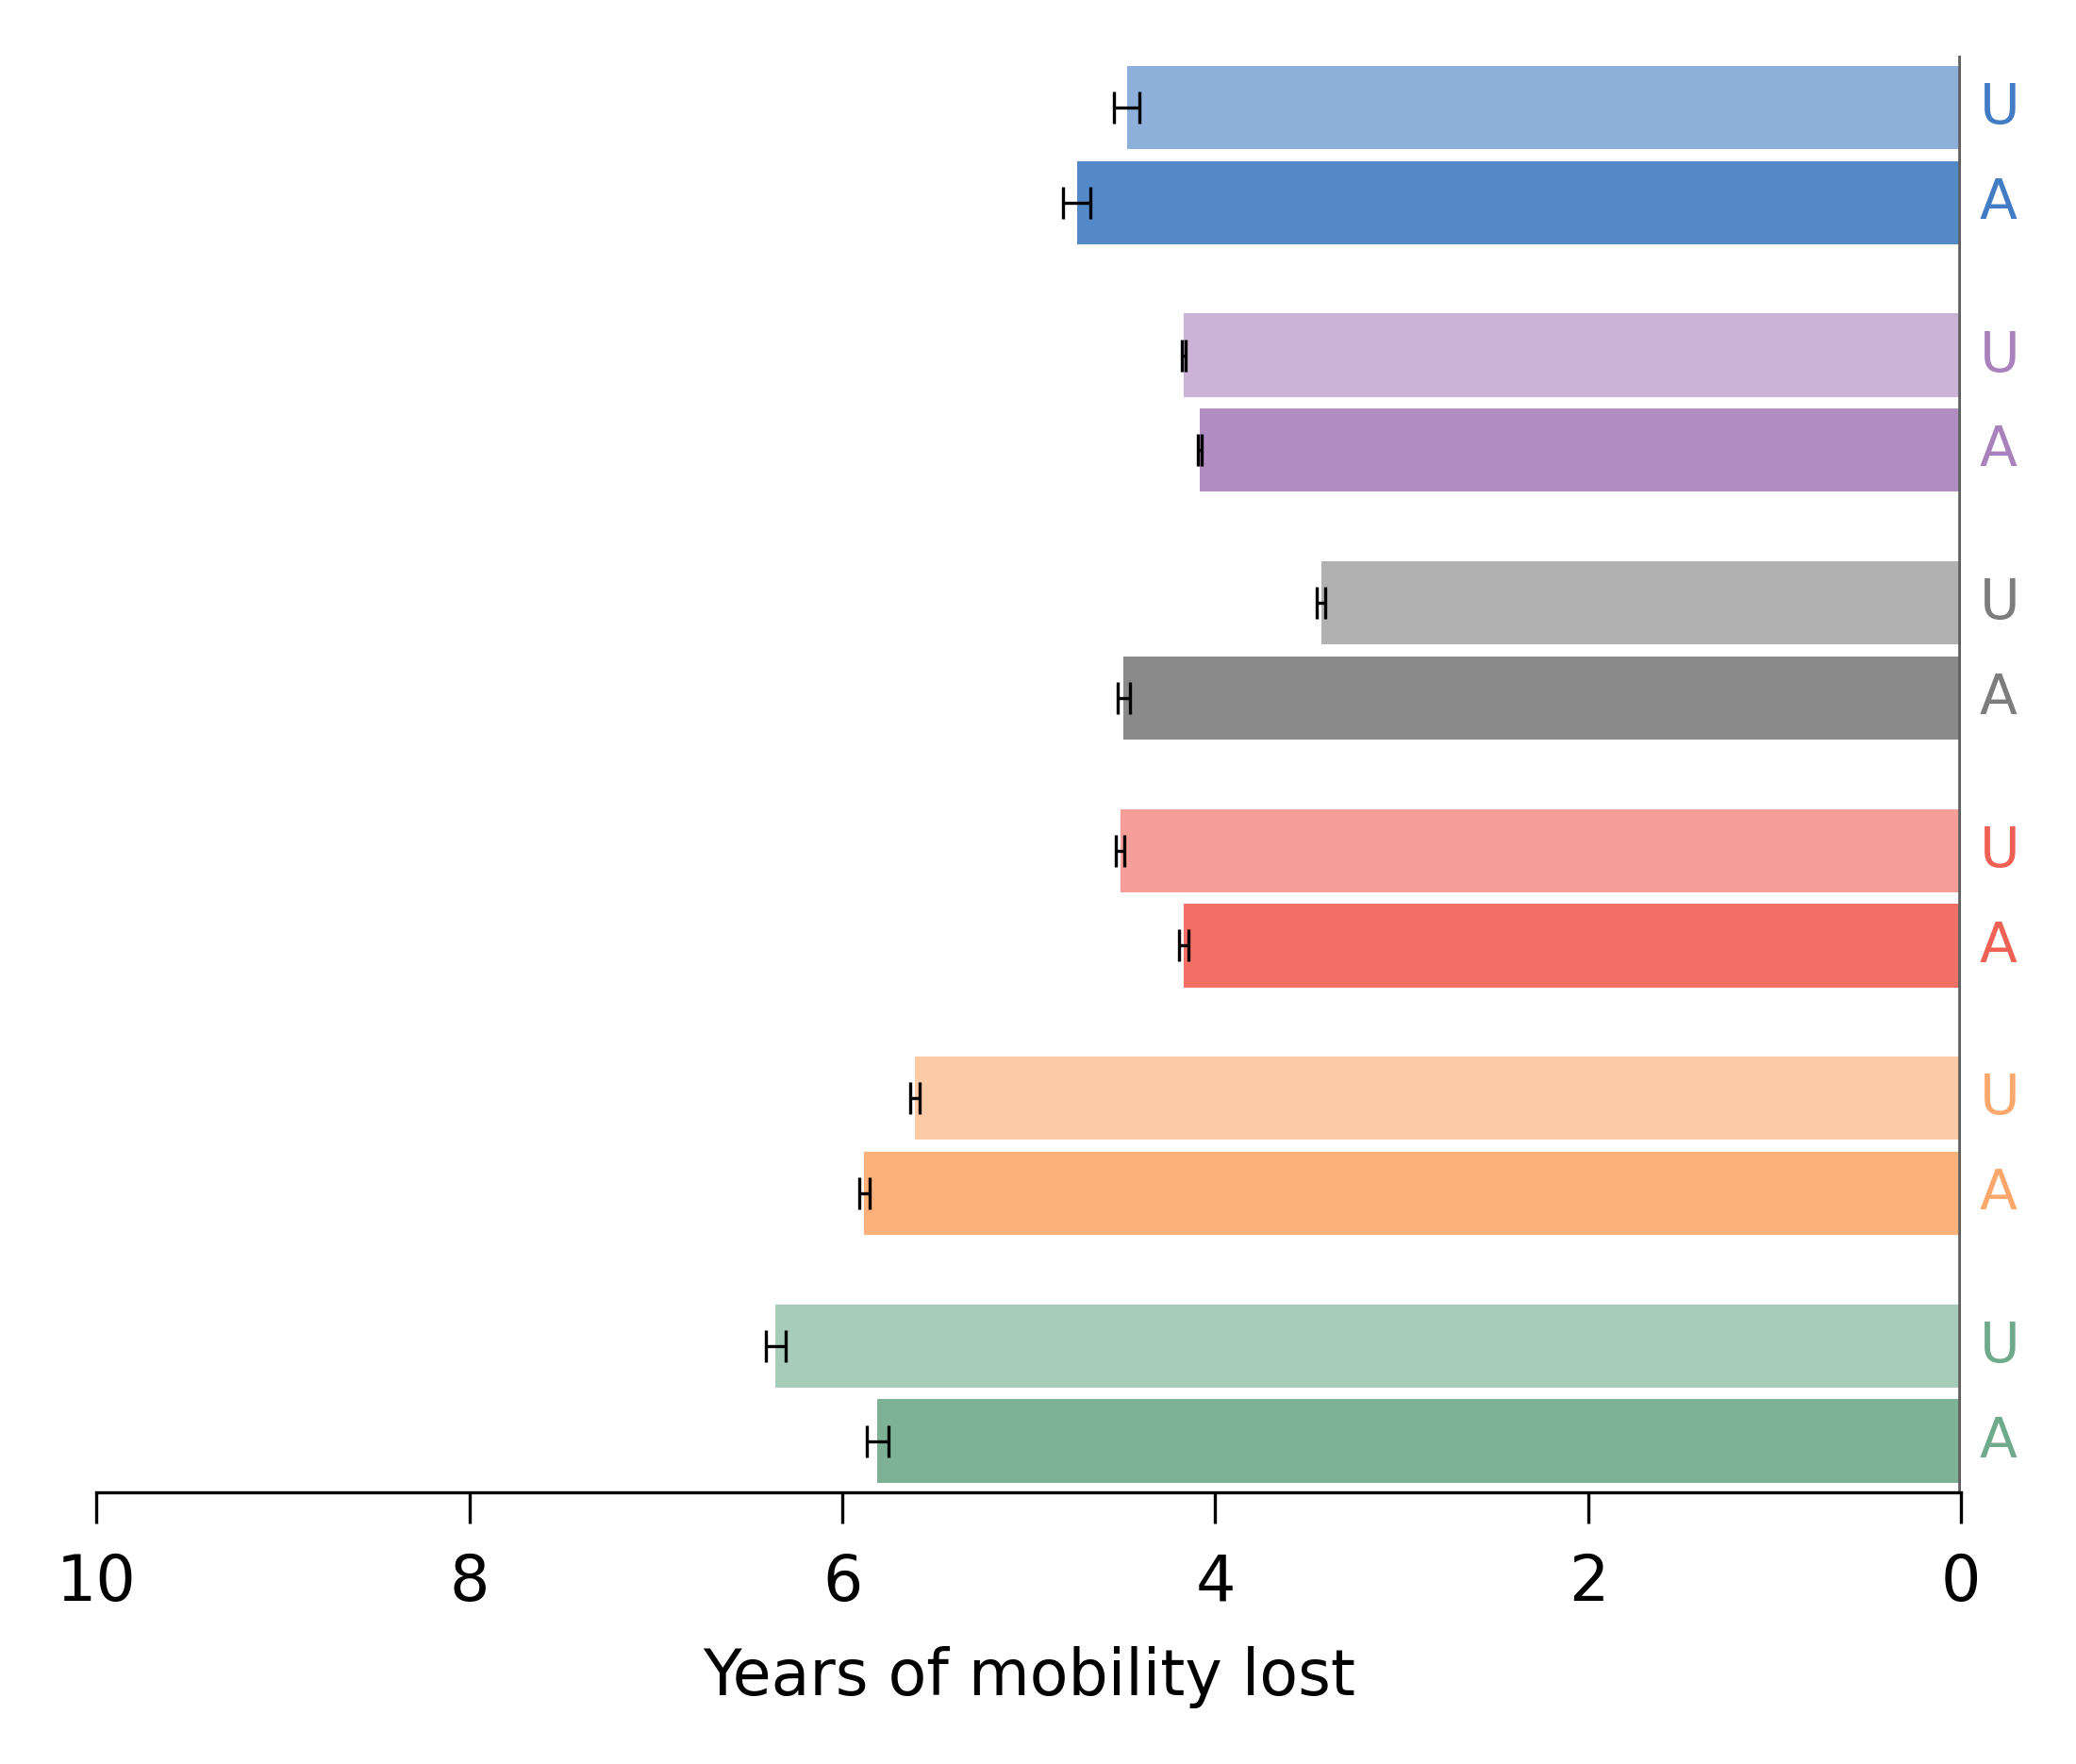

Saved: ../results/f4_disease_timevary/yoml_model1_2_barplot.pdf


In [85]:
# Plot YOML1 bar chart (Model 1/2)
def plot_yoml_bar(yoml_all: pd.DataFrame, out_path: str):
    if yoml_all.empty:
        return
    colors = assign_disease_colors()
    work = yoml_all.copy()
    disease_order = list(reversed(sorted([disease_label[d] for d in disease_cols])))
    work["group"] = pd.Categorical(work["group"], categories=disease_order, ordered=True)
    work = work.sort_values(["group", "model"])
    y_map = []
    idx = 0.0
    group_gap = 0.25
    for d in disease_order:
        y_map.append({"group": d, "y": idx})
        idx += 1.0 + group_gap
    y_df = pd.DataFrame(y_map)
    y_base = {row["group"]: row["y"] for _, row in y_df.iterrows()}
    offsets = {"A": -0.24, "U": 0.24}
    fig, ax = plt.subplots(figsize=(W_INCH * 0.9, H_INCH), dpi=DPI_OUT)
    for _, r in work.iterrows():
        group = str(r["group"])
        base_color = colors.get(group, "#4C72B0")
        bar_color = lighten_color(base_color, factor=0.4) if r["model"] == "U" else lighten_color(base_color, factor=0.1)
        y = y_base[group] + offsets.get(r["model"], 0.0)
        v = float(r["yoml"])
        v_l = float(r["yoml_l"]) if np.isfinite(r["yoml_l"]) else v
        v_u = float(r["yoml_u"]) if np.isfinite(r["yoml_u"]) else v
        ax.barh(y, v, height=0.42, color=bar_color, edgecolor="none", linewidth=0.4)
        if np.isfinite(v_l) and np.isfinite(v_u):
            ax.errorbar(
                v,
                y,
                xerr=[[v - v_l], [v_u - v]],
                fmt="none",
                ecolor="#000000",
                elinewidth=0.4,
                capsize=2,
                capthick=0.4,
                zorder=3,
            )
        ax.text(1.01, y, r["model"], transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=FONT_SIZE - 2, color=base_color)
    ax.axvline(0, color="#606060", linewidth=0.8)
    ax.set_xlim(10, 0)
    ax.set_xticks(np.arange(10, -0.1, -2))
    ax.set_yticks(y_df["y"].to_numpy())
    ax.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
    ax.set_xlabel("Years of mobility lost", fontsize=FONT_SIZE-1)
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4, length=4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.invert_yaxis()
    ax.set_ylim(y_df["y"].min() - 0.5, y_df["y"].max() + 0.5)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.16, right=0.93)
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True)
    plt.show()
    print("Saved:", out_path)


if "yoml_all" in globals() and isinstance(yoml_all, pd.DataFrame) and not yoml_all.empty:
    out_path = os.path.join(BASE_DIR, "yoml_model1_2_barplot.pdf")
    plot_yoml_bar(yoml_all, out_path)
else:
    print("yoml_all is empty; run the YOML calculation cell first.")

In [14]:
# Print YOML and CI (Model 1/2)
if "yoml_all" in globals() and isinstance(yoml_all, pd.DataFrame) and not yoml_all.empty:
    cols = ["group", "model", "yoml", "yoml_l", "yoml_u", "n_onset", "n_base"]
    print("YOML1 (Model 1/2):")
    print(yoml_all.loc[:, cols].to_string(index=False))
else:
    print("yoml_all is empty; run the YOML calculation cell first.")

YOML1 (Model 1/2):
              group model     yoml   yoml_l   yoml_u  n_onset  n_base
Alzheimer's disease     U 4.475033 4.407898 4.544826     2218   87666
Alzheimer's disease     A 4.739836 4.669944 4.817273     2218   87666
          Arthritis     U 4.168224 4.159026 4.178077    36296  135290
          Arthritis     A 4.081663 4.071865 4.092287    36296  135290
             Cancer     U 3.432155 3.409806 3.454809     5983   77406
             Cancer     A 4.492233 4.458272 4.525953     5983   77406
      Heart disease     U 4.509084 4.485763 4.532998     9632   74884
      Heart disease     A 4.169709 4.145183 4.194705     9632   74884
       Lung disease     U 5.612833 5.584928 5.638150    10786  164353
       Lung disease     A 5.882884 5.852444 5.911834    10786  164353
             Stroke     U 6.358781 6.304300 6.412779     4696   80755
             Stroke     A 5.812592 5.751294 5.868653     4696   80755


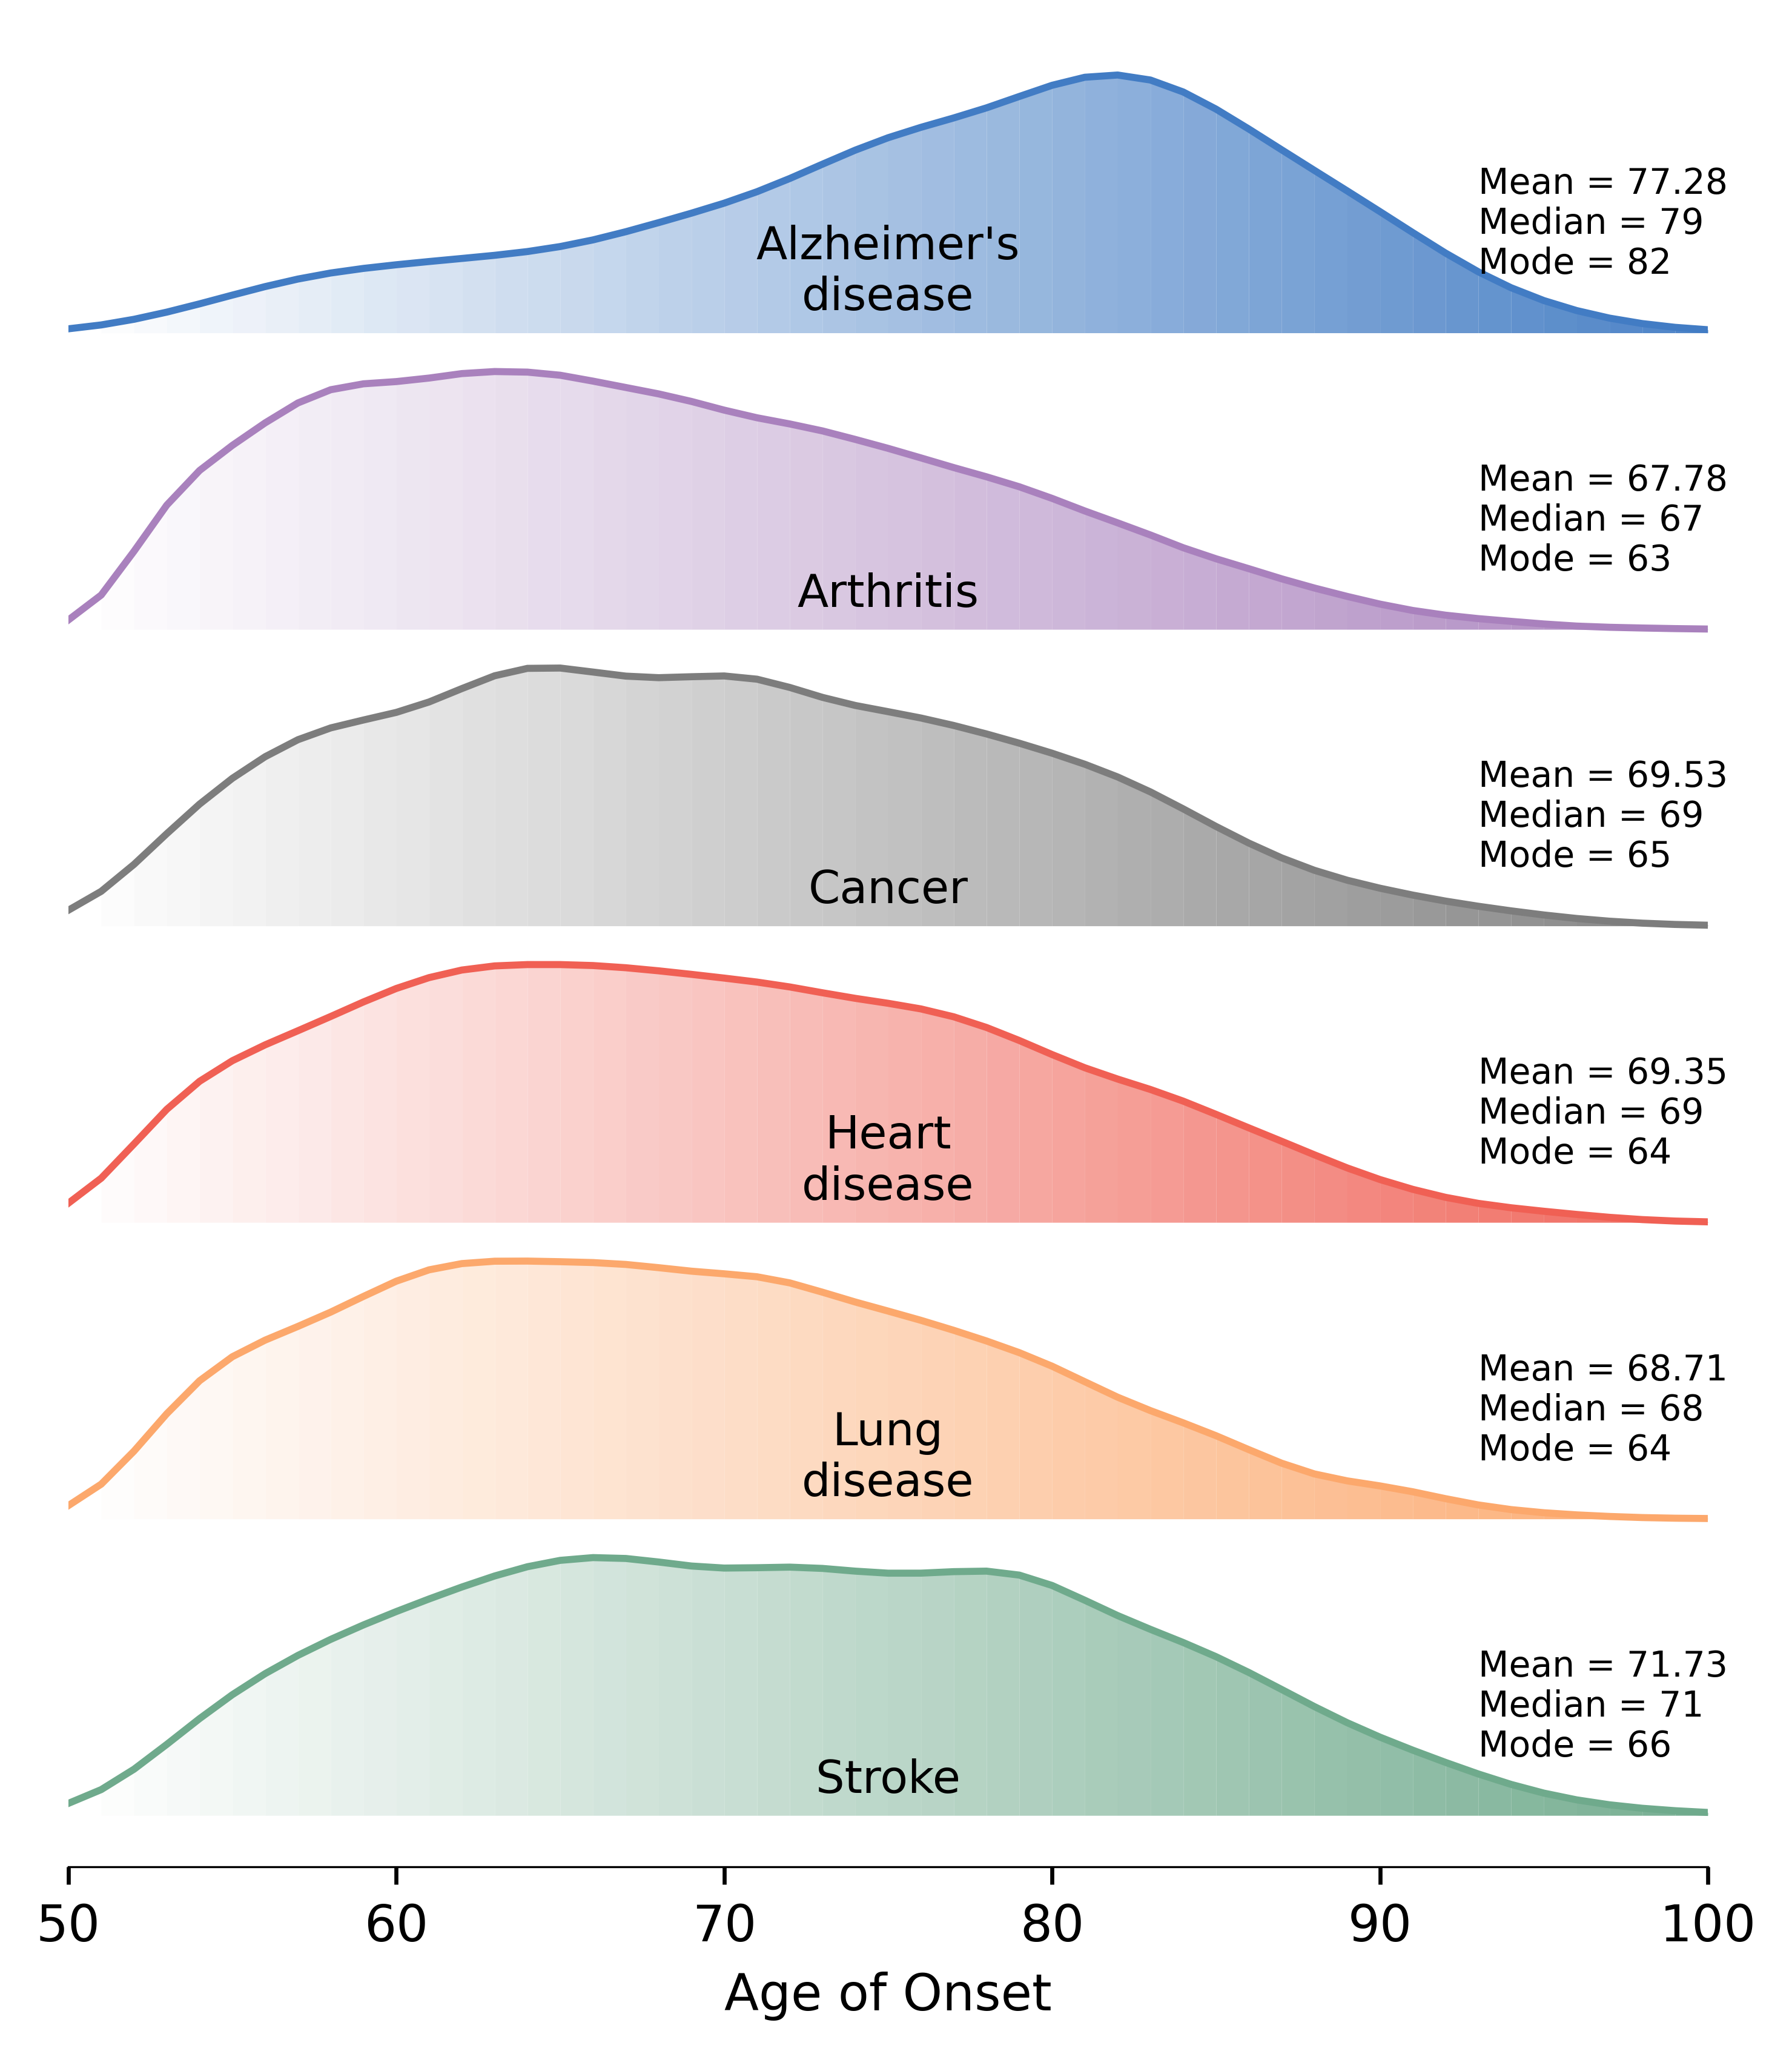

Saved: ../results/f4_disease_timevary/onset_age_ridge_m12.pdf


In [86]:
# Ridge plot using Model 1/2 baseline sample
def _collect_onset_ages_m12() -> pd.DataFrame:
    rows = []
    for k in disease_cols:
        other_diseases = [dc for dc in disease_cols if dc != k]
        intervals = load_or_build_intervals(k, FOREST_BINS, other_disease_cols=other_diseases)
        if intervals.empty or "onset_current" not in intervals.columns:
            continue
        onset_rows = intervals.loc[intervals["onset_current"] == 1]
        if onset_rows.empty:
            continue
        onset_ages = START_AGE + onset_rows["exit_t"].astype(float).to_numpy()
        for v in onset_ages:
            rows.append({"disease": disease_label.get(k, k), "onset_age": float(v)})
    return pd.DataFrame(rows)


def _load_onset_ages_m12() -> pd.DataFrame:
    onset_path = os.path.join(PRECOMPUTED_DIR, "disease_onset_ages_m12.csv")
    if os.path.exists(onset_path):
        df = pd.read_csv(onset_path)
        if not df.empty:
            return df
    return _collect_onset_ages_m12()


def _ridge_label(name: str) -> str:
    if name == "Lung disease":
        return "Lung\ndisease"
    if name == "Heart disease":
        return "Heart\ndisease"
    if name == "Alzheimer's disease":
        return "Alzheimer's\ndisease"
    return name


def _mode_from_kde(vals: np.ndarray, grid: np.ndarray) -> float:
    if vals.size < 2:
        return float(np.nan)
    kde = gaussian_kde(vals)
    dens = kde(grid)
    return float(grid[int(np.argmax(dens))])


def plot_onset_ridge_m12(out_path: str):
    long_df = _load_onset_ages_m12()
    if long_df.empty:
        print("No onset ages found for Model 1/2 ridge plot.")
        return
    disease_order = list(reversed(sorted(long_df["disease"].unique().tolist())))
    age_grid = np.arange(START_AGE, AGE_MAX + 1e-9, AGE_STEP)
    fig, ax = plt.subplots(figsize=(W_INCH * 1.2, H_INCH * 1.8), dpi=DPI_OUT)
    y_offset = 1.15
    disease_colors = assign_disease_colors()
    for i, d in enumerate(disease_order):
        vals = long_df.loc[long_df["disease"] == d, "onset_age"].to_numpy()
        if vals.size < 2:
            continue
        kde = gaussian_kde(vals)
        dens = kde(age_grid)
        if dens.max() > 0:
            dens = dens / dens.max()
        y0 = i * y_offset
        base_hex = disease_colors.get(d, "#7D7D7D")
        light_rgb = (255, 255, 255)
        base_rgb = _hex_to_rgb(base_hex)
        for j in range(len(age_grid) - 1):
            x0 = age_grid[j]
            x1 = age_grid[j + 1] + 1e-3
            t = (x0 - START_AGE) / max(AGE_MAX - START_AGE, 1e-9)
            seg_color = _rgb_to_hex(_blend_rgb(light_rgb, base_rgb, t))
            ax.fill_between([x0, x1], [y0, y0], [y0 + dens[j], y0 + dens[j + 1]], color=seg_color, alpha=0.95, linewidth=0)
        ax.plot(age_grid, y0 + dens, color=base_hex, linewidth=1.4)
        ax.text(75, y0 + 0.05, _ridge_label(d), ha="center", va="bottom", fontsize=FONT_SIZE , color="#000000")
        mean_val = float(np.nanmean(vals))
        median_val = float(np.nanmedian(vals))
        mode_val = _mode_from_kde(vals, age_grid)
        stat_text = (
            f"Mean = {mean_val:.2f}\n"
            f"Median = {int(round(median_val))}\n"
            f"Mode = {int(round(mode_val))}"
)
        ax.text(93, y0 + 0.2, stat_text, ha="left", va="bottom", fontsize=FONT_SIZE - 2, color="#000000")
    ax.set_yticks([])
    ax.set_xlim(START_AGE, AGE_MAX)
    ax.set_ylim(-0.2, y_offset * len(disease_order))
    ax.set_xticks(np.arange(50, 101, 10))
    ax.set_xlabel("Age of Onset")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.tick_params(axis="x", bottom=True, labelbottom=True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


ridge_m12_path = os.path.join(BASE_DIR, "onset_age_ridge_m12.pdf")
plot_onset_ridge_m12(ridge_m12_path)

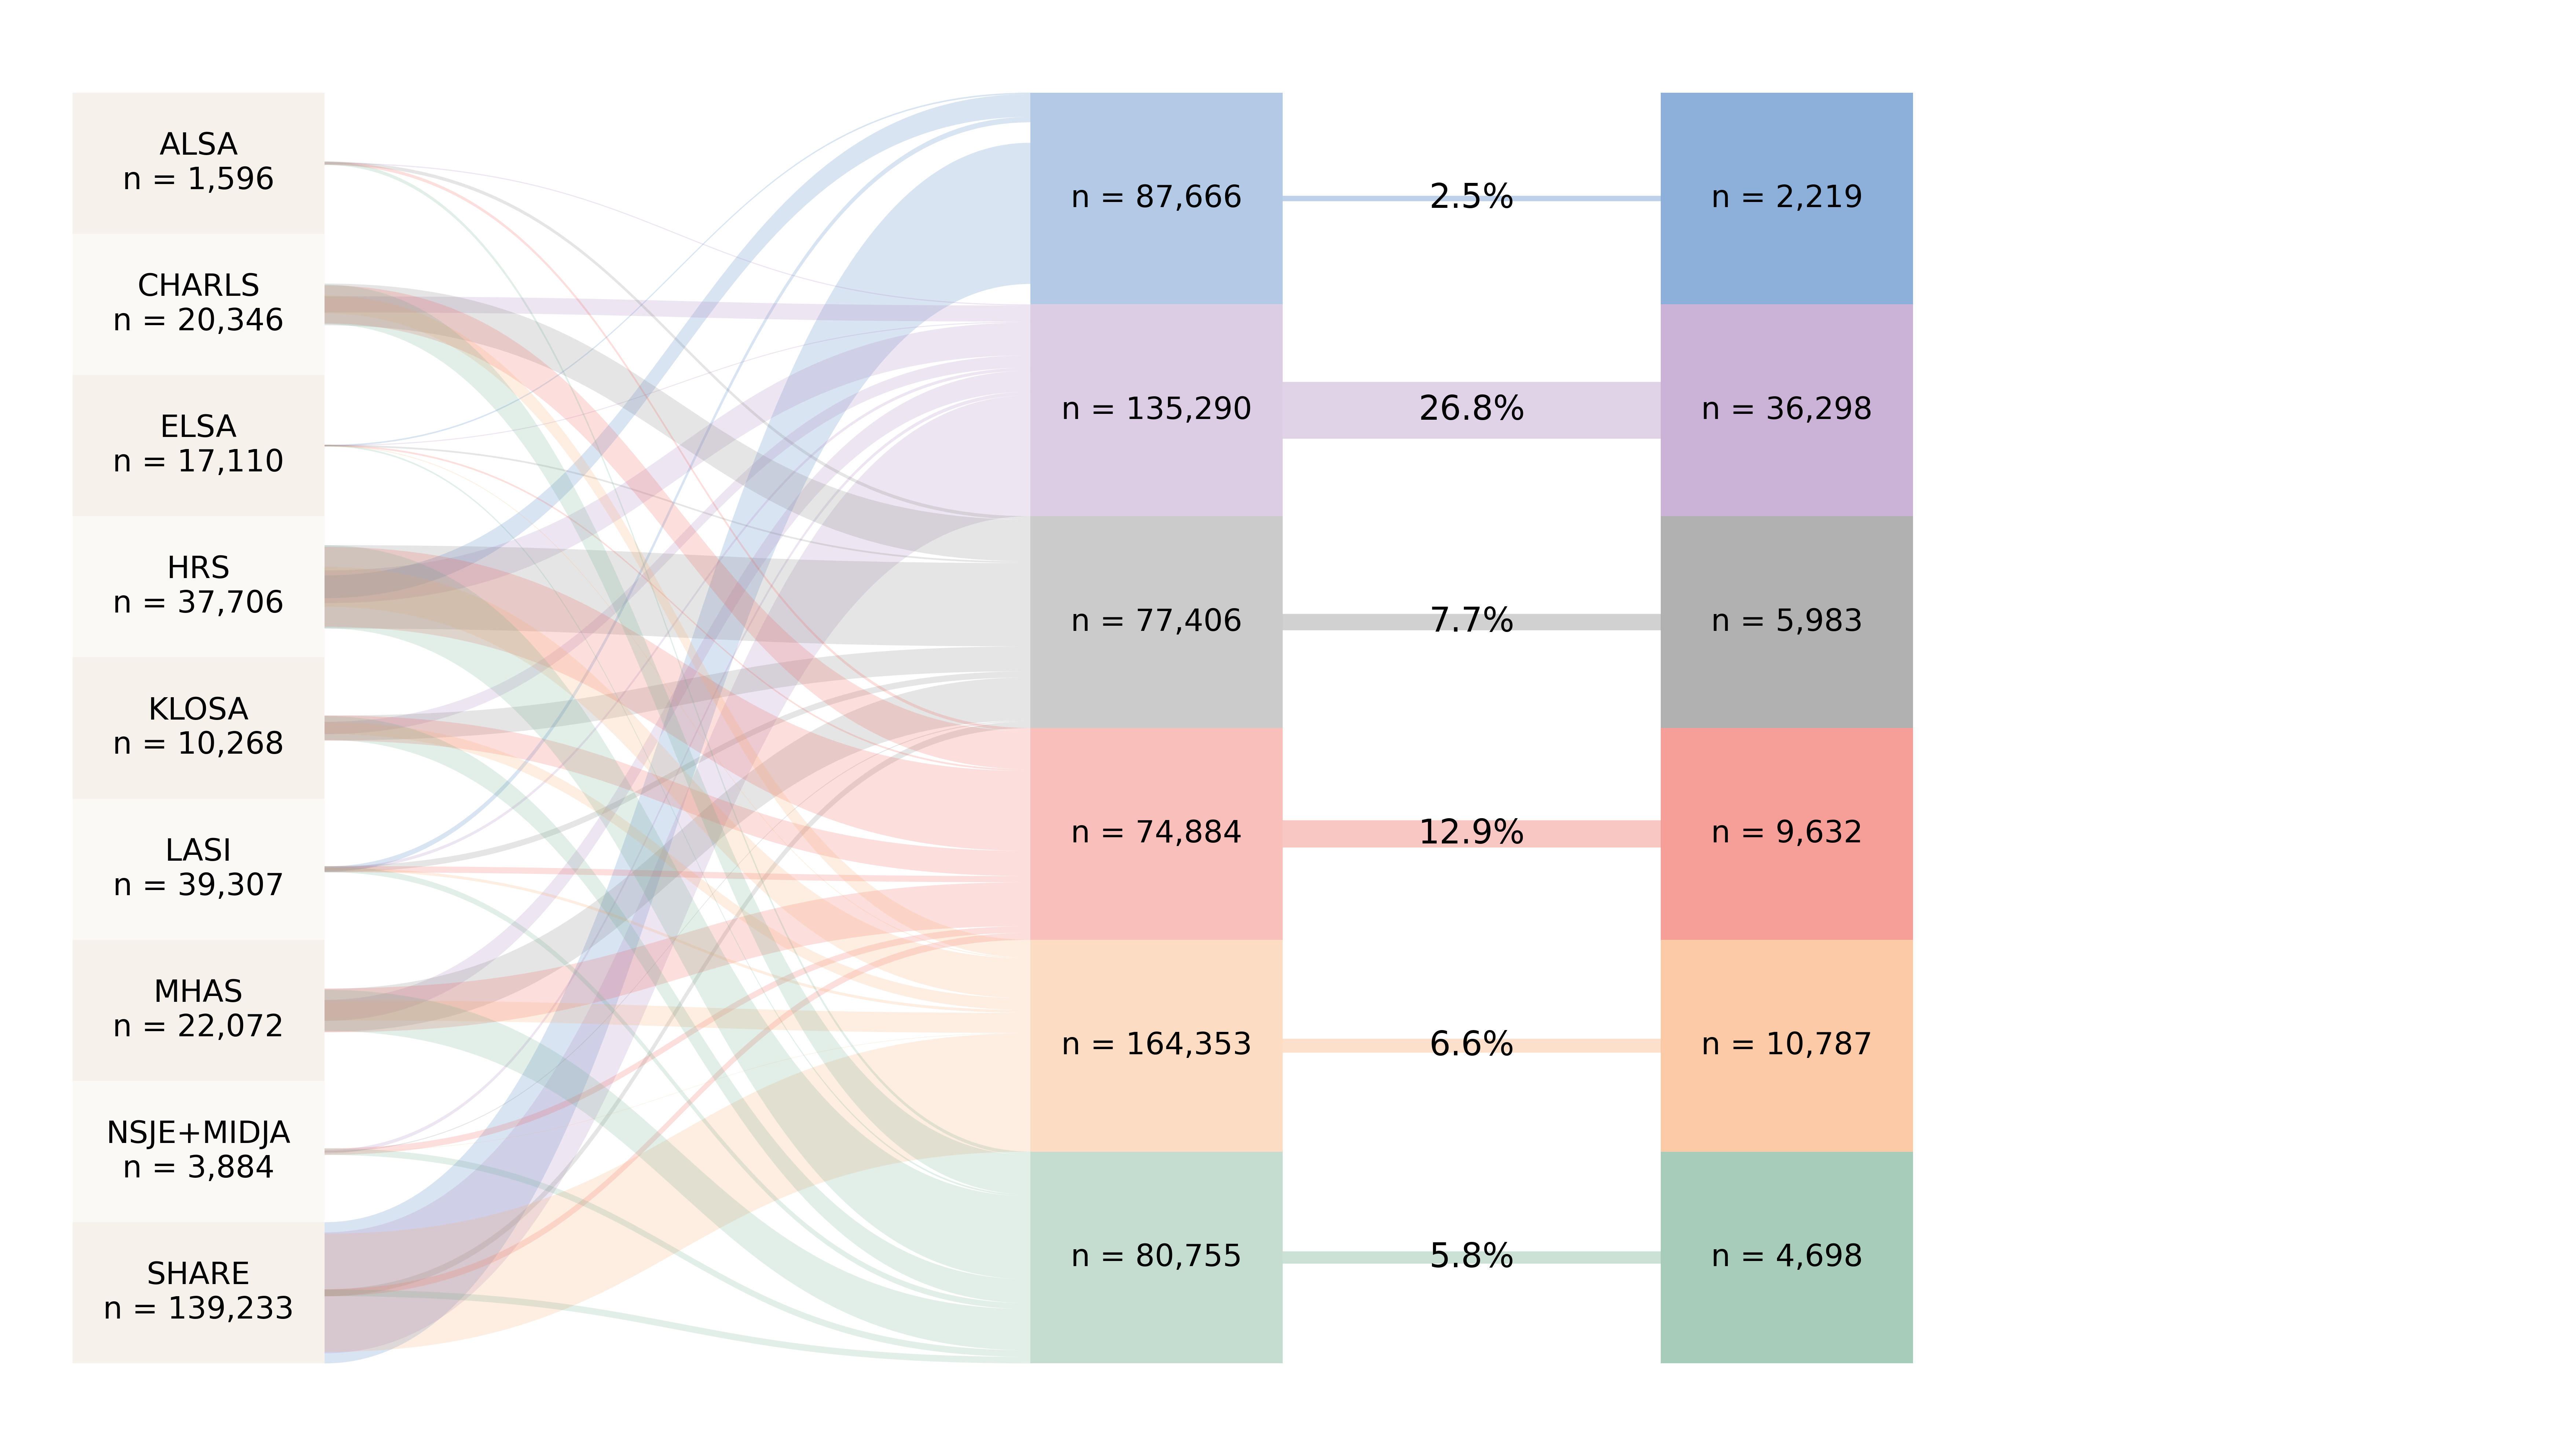

Saved: ../results/f4_disease_timevary/onset_sankey_m12.pdf


In [87]:
# Sankey-style summary (dataset baseline -> disease baseline -> onset)
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle


def _circle_hex_to_rgb(color_hex: str) -> Tuple[int, int, int]:
    color_hex = color_hex.lstrip("#")
    return tuple(int(color_hex[i : i + 2], 16) for i in (0, 2, 4))


def _circle_rgb_to_hex(rgb: Tuple[int, int, int]) -> str:
    return "#%02x%02x%02x" % rgb


# def _circle_lighten(color_hex: str, factor: float = 0.45) -> str:
#     r, g, b = _circle_hex_to_rgb(color_hex)
#     r = int(r + (255 - r) * factor)
#     g = int(g + (255 - g) * factor)
#     b = int(b + (255 - b) * factor)
#     return _circle_rgb_to_hex((r, g, b))


def _circle_color_map() -> Dict[str, str]:
    return {
        "Lung disease": "#EB5B25",
        "Arthritis": "#964091",
        "Stroke": "#21918D",
        "Heart disease": "#BF3238",
        "Alzheimer's disease": "#1951A0",
        "Cancer": "#7D7D7D",
    }


def _load_dataset_map() -> Dict[str, str]:
    path = "../data/iso40.csv"
    if not os.path.exists(path):
        print("Missing iso40.csv:", path)
        return {}
    iso = pd.read_csv(path)
    if "isocountry_c" not in iso.columns or "dataset" not in iso.columns:
        print("iso40.csv missing columns isocountry_c/dataset")
        return {}
    iso["isocountry_c"] = iso["isocountry_c"].astype(str).str.strip()
    iso["dataset"] = iso["dataset"].astype(str).str.strip()
    return dict(zip(iso["isocountry_c"], iso["dataset"]))


def _read_cached_intervals(disease_col: str) -> pd.DataFrame:
    cache_path = _cache_path(disease_col, FOREST_BINS)
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path)
        if "id" in df.columns:
            return df
    print("Missing cached intervals:", cache_path)
    return pd.DataFrame()


def _baseline_no_mobility_counts(dataset_map: Dict[str, str]) -> Dict[str, int]:
    work = raw.dropna(subset=["id", "age"]).copy()
    work = work.loc[work["age"].between(START_AGE, AGE_MAX), :]
    rows = []
    for (country, pid), g in work.sort_values(["country", "id", "age"]).groupby(["country", "id"]):
        valid_walk = g.loc[g["rwalk1a"].notna(), :]
        if valid_walk.empty:
            continue
        entry_age = valid_walk["age"].min()
        entry_row = valid_walk.loc[valid_walk["age"] == entry_age].iloc[0]
        baseline_ok = (not pd.isna(entry_row.get("rwalk1a")) and entry_row.get("rwalk1a") == 0)
        if not baseline_ok:
            continue
        dataset = dataset_map.get(str(country), "Unknown")
        rows.append({"dataset": dataset, "id": str(pid)})
    if not rows:
        return {}
    base_df = pd.DataFrame(rows).drop_duplicates()
    return base_df.groupby("dataset")["id"].nunique().astype(int).to_dict()


def _wrap_disease_name(name: str) -> str:
    if " disease" in name:
        return name.replace(" disease", "\ndisease")
    return name


def _fmt_count(value: int) -> str:
    return f"{int(value):,}"


def _collect_sankey_m12() -> Dict[str, object]:
    dataset_map = _load_dataset_map()
    if not dataset_map:
        return {}

    disease_order = [disease_label[d] for d in disease_cols]
    left_totals = _baseline_no_mobility_counts(dataset_map)
    if not left_totals:
        return {}

    exclude_left = {"ELSI", "HAALSI"}
    left_totals = {k: v for k, v in left_totals.items() if k not in exclude_left}
    if not left_totals:
        return {}

    mid_counts: Dict[str, int] = {}
    right_counts: Dict[str, int] = {}
    links_left = []

    for k in disease_cols:
        disease_name = disease_label.get(k, k)
        intervals = _read_cached_intervals(k)
        if intervals.empty:
            continue

        base_df = intervals[["id", "country"]].drop_duplicates()
        base_df["dataset"] = base_df["country"].map(dataset_map).fillna("Unknown")
        base_counts = base_df.groupby("dataset")["id"].nunique()

        onset_df = intervals.loc[intervals["onset_current"] == 1, ["id", "country"]].drop_duplicates()
        onset_df["dataset"] = onset_df["country"].map(dataset_map).fillna("Unknown")

        n_base = int(base_df["id"].nunique())
        n_onset = int(onset_df["id"].nunique())

        mid_counts[disease_name] = n_base
        right_counts[disease_name] = n_onset

        for dataset, val in base_counts.items():
            v = int(val)
            if v <= 0:
                continue
            links_left.append((dataset, disease_name, v))

    if not mid_counts:
        return {}

    left_nodes = sorted(left_totals.keys(), key=lambda s: str(s).lower())
    mid_nodes = [d for d in disease_order if d in mid_counts and mid_counts[d] > 0]
    right_nodes = [d for d in mid_nodes]

    return {
        "left_nodes": left_nodes,
        "mid_nodes": mid_nodes,
        "right_nodes": right_nodes,
        "left_totals": left_totals,
        "mid_counts": mid_counts,
        "right_counts": right_counts,
        "links_left": links_left,
    }


def _layout_nodes(names: List[str], sizes: Dict[str, int], y_top: float, y_bottom: float, pad: float = 0.0):
    total = sum(max(sizes.get(n, 0), 0) for n in names)
    if total <= 0:
        return {}, 1.0
    height = y_top - y_bottom
    pad_total = pad * max(len(names) - 1, 0)
    scale = (height - pad_total) / float(total) if height > pad_total else height / float(total)

    y = y_top
    layout = {}
    for n in names:
        h = max(sizes.get(n, 0), 0) * scale
        y0 = y - h
        layout[n] = {"top": y, "bottom": y0, "height": h}
        y = y0 - pad
    return layout, scale


def _layout_nodes_equal(names: List[str], y_top: float, y_bottom: float, pad: float = 0.0):
    if not names:
        return {}, 1.0
    height = y_top - y_bottom
    pad_total = pad * max(len(names) - 1, 0)
    node_h = (height - pad_total) / float(len(names)) if height > pad_total else height / float(len(names))
    y = y_top
    layout = {}
    for n in names:
        y0 = y - node_h
        layout[n] = {"top": y, "bottom": y0, "height": node_h}
        y = y0 - pad
    return layout, node_h


def _draw_flow(ax, x0: float, x1: float, y0: float, y1: float, width: float, color: str, alpha: float = 0.35):
    ctrl_dx = (x1 - x0) * 0.5
    verts = [
        (x0, y0 + width / 2.0),
        (x0 + ctrl_dx, y0 + width / 2.0),
        (x1 - ctrl_dx, y1 + width / 2.0),
        (x1, y1 + width / 2.0),
        (x1, y1 - width / 2.0),
        (x1 - ctrl_dx, y1 - width / 2.0),
        (x0 + ctrl_dx, y0 - width / 2.0),
        (x0, y0 - width / 2.0),
        (x0, y0 + width / 2.0),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.LINETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    patch = PathPatch(Path(verts, codes), facecolor=color, edgecolor="none", alpha=alpha)
    ax.add_patch(patch)


def plot_sankey_m12(out_path: str):
    data = _collect_sankey_m12()
    if not data:
        print("No counts found for Model 1/2 Sankey plot.")
        return

    left_nodes = data["left_nodes"]
    mid_nodes = data["mid_nodes"]
    right_nodes = data["right_nodes"]
    left_totals = data["left_totals"]
    mid_counts = data["mid_counts"]
    right_counts = data["right_counts"]
    links_left = data["links_left"]

    right_sizes = {}
    right_labels = {}
    flow_ratios = {}
    for d in mid_nodes:
        n_base = max(mid_counts.get(d, 0), 0)
        n_onset = max(right_counts.get(d, 0), 0)
        pct_onset = (n_onset / n_base) if n_base > 0 else 0.0
        right_sizes[d] = n_onset
        right_labels[d] = f"n = {_fmt_count(n_onset)}"
        flow_ratios[d] = pct_onset

    left_layout, _ = _layout_nodes_equal(left_nodes, 0.95, 0.05)
    mid_layout, _ = _layout_nodes_equal(mid_nodes, 0.95, 0.05)
    right_layout, _ = _layout_nodes_equal(right_nodes, 0.95, 0.05)

    fig, ax = plt.subplots(figsize=(W_INCH * 2.8, H_INCH * 2.1), dpi=DPI_OUT)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    left_x = 0.02
    mid_x = 0.40
    right_x = 0.65
    node_w = 0.10
    disease_colors = assign_disease_colors()
    left_band_colors = ["#F6F2EB", "#FAF9F5"]

    # Draw nodes
    for idx, name in enumerate(left_nodes):
        box = left_layout.get(name)
        if not box:
            continue
        rect = Rectangle((left_x, box["bottom"]), node_w, box["height"], facecolor=left_band_colors[idx % 2], edgecolor="none")
        ax.add_patch(rect)
        ax.text(left_x + node_w / 2.0, (box["top"] + box["bottom"]) / 2.0, f"{name}\nn = {_fmt_count(left_totals.get(name, 0))}",
                ha="center", va="center", fontsize=FONT_SIZE + 1, color="#000000")

    for name in mid_nodes:
        box = mid_layout.get(name)
        if not box:
            continue
        base_color = disease_colors.get(name, "#7D7D7D")
        rect = Rectangle((mid_x, box["bottom"]), node_w, box["height"], facecolor=base_color, edgecolor="none", alpha=0.4)
        ax.add_patch(rect)
        ax.text(mid_x + node_w / 2.0, (box["top"] + box["bottom"]) / 2.0, f"n = {_fmt_count(mid_counts.get(name, 0))}",
                ha="center", va="center", fontsize=FONT_SIZE + 1, color="#000000")

    for name in right_nodes:
        box = right_layout.get(name)
        if not box:
            continue
        base_color = disease_colors.get(name, "#7D7D7D")
        rect = Rectangle((right_x, box["bottom"]), node_w, box["height"], facecolor=base_color, edgecolor="none", alpha=0.6)
        ax.add_patch(rect)
        ax.text(right_x + node_w / 2.0, (box["top"] + box["bottom"]) / 2.0, right_labels.get(name, name),
                ha="center", va="center", fontsize=FONT_SIZE + 1, color="#000000")

    # Draw links: dataset -> disease (overlap allowed, keep within dataset height)
    mid_offsets = {n: 0.0 for n in mid_nodes}
    for dataset, disease, val in links_left:
        if dataset not in left_layout or disease not in mid_layout:
            continue
        box_l = left_layout[dataset]
        box_m = mid_layout[disease]
        n_base = max(mid_counts.get(disease, 0), 0)
        scale_mid = box_m["height"] / n_base if n_base > 0 else 0.0
        y_l_center = (box_l["top"] + box_l["bottom"]) / 2.0
        y_m_top = box_m["top"] - mid_offsets[disease]
        y_m_bot = y_m_top - val * scale_mid
        mid_offsets[disease] += val * scale_mid
        y0 = y_l_center
        y1 = (y_m_top + y_m_bot) / 2.0
        color = disease_colors.get(disease, "#7D7D7D")
        flow_w = min(val * scale_mid, box_l["height"])
        _draw_flow(ax, left_x + node_w, mid_x, y0, y1, flow_w, color, alpha=0.2)

    # Draw links: disease -> onset and ratio label on the link
    for disease in mid_nodes:
        n_onset = right_counts.get(disease, 0)
        n_base = max(mid_counts.get(disease, 0), 0)
        if n_onset <= 0 or n_base <= 0:
            continue
        box_m = mid_layout[disease]
        box_r = right_layout[disease]
        ratio = n_onset / n_base
        y0 = (box_m["top"] + box_m["bottom"]) / 2.0
        y1 = (box_r["top"] + box_r["bottom"]) / 2.0
        color = disease_colors.get(disease, "#7D7D7D")
        flow_w = box_m["height"] * ratio
        _draw_flow(ax, mid_x + node_w, right_x, y0, y1, flow_w, color, alpha=0.35)
        ax.text((mid_x + node_w + right_x) / 2.0, (y0 + y1) / 2.0, f"{ratio:.1%}",
                ha="center", va="center", fontsize=FONT_SIZE + 2, color="#000000")

    plt.tight_layout()
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


sankey_m12_path = os.path.join(BASE_DIR, "onset_sankey_m12.pdf")
plot_sankey_m12(sankey_m12_path)

In [17]:
# Multimorbidity intervals and models (Model 5-8)
def make_mm_bin_columns(prefix: str, bins: List[Tuple[float, float]]) -> List[str]:
    base = make_bin_columns(bins)
    return [f"{prefix}_{b}" for b in base]


def _first_transition_age(counts: np.ndarray, ages: np.ndarray, cond_prev, cond_next) -> float:
    prev_val = None
    for age_i, val in zip(ages, counts):
        if prev_val is not None and cond_prev(prev_val) and cond_next(val):
            return float(age_i)
        prev_val = val
    return np.nan


def build_intervals_multimorbidity(df_raw: pd.DataFrame, bins: List[Tuple[float, float]]) -> pd.DataFrame:
    rows = []
    mm1_bin_cols = make_mm_bin_columns("mm1", bins)
    mm2p_bin_cols = make_mm_bin_columns("mm2p", bins)
    for (country, pid), g in df_raw.sort_values(["country", "id", "age"]).groupby(["country", "id"]):
        valid_walk = g.loc[g["rwalk1a"].notna(), :].copy()
        if valid_walk.empty:
            continue
        valid = valid_walk.loc[valid_walk["age"].between(START_AGE, AGE_MAX)].copy()
        if valid.empty:
            continue
        entry_age = valid["age"].min()
        entry_row = valid.loc[valid["age"] == entry_age].iloc[0]
        baseline_state = entry_row.get("rwalk1a", np.nan)
        if pd.isna(baseline_state) or baseline_state != 0:
            continue
        baseline_count = valid.loc[valid["age"] == entry_age, disease_cols].fillna(0).sum(axis=1).iloc[0]
        if pd.isna(baseline_count) or baseline_count != 0:
            continue
        censor_age = valid["age"].max()
        event_age = valid.loc[valid["rwalk1a"] == 1, "age"].min() if (valid["rwalk1a"] == 1).any() else np.nan
        entry_age = min(max(entry_age, START_AGE), AGE_MAX)
        exit_age = min(event_age, AGE_MAX) if not pd.isna(event_age) else min(censor_age, AGE_MAX)
        if pd.isna(entry_age) or pd.isna(exit_age) or exit_age <= entry_age:
            continue
        ages = valid["age"].to_numpy()
        counts = valid[disease_cols].fillna(0).sum(axis=1).to_numpy()
        mm1_onset_age = _first_transition_age(counts, ages, lambda v: v == 0, lambda v: v == 1)
        mm2p_onset_age = _first_transition_age(counts, ages, lambda v: v < 2, lambda v: v >= 2)
        mm1_seen = False
        mm2p_seen = False
        for i, age_i in enumerate(ages):
            if age_i >= exit_age:
                break
            next_age = exit_age
            if i + 1 < len(ages):
                next_age = min(ages[i + 1], exit_age)
            if next_age <= age_i:
                continue
            cnt_i = float(counts[i])
            cnt_next = float(counts[i + 1]) if i + 1 < len(ages) else cnt_i
            mm1_onset = 0.0
            mm2p_onset = 0.0
            if not mm1_seen and cnt_i == 0 and cnt_next == 1 and np.isclose(next_age, ages[i + 1]):
                mm1_onset = 1.0
                mm1_seen = True
            if not mm2p_seen and cnt_i < 2 and cnt_next >= 2 and np.isclose(next_age, ages[i + 1]):
                mm2p_onset = 1.0
                mm2p_seen = True
            row = {
                "id": str(pid),
                "country": str(country),
                "entry_t": float(max(age_i, entry_age) - START_AGE),
                "exit_t": float(next_age - START_AGE),
                "event_w": int(not pd.isna(event_age) and np.isclose(next_age, exit_age) and next_age == event_age),
                "mm1_onset": mm1_onset,
                "mm2p_onset": mm2p_onset,
            }
            for c in controls:
                row[c] = entry_row.get(c, np.nan)
            for bc in mm1_bin_cols + mm2p_bin_cols:
                row[bc] = 0.0
            if not pd.isna(mm1_onset_age) and cnt_i == 1:
                time_since = age_i - mm1_onset_age
                for (start, end), bc in zip(bins, mm1_bin_cols):
                    if time_since >= start and (time_since < end or np.isinf(end)):
                        row[bc] = 1.0
                        break
            if not pd.isna(mm2p_onset_age) and cnt_i >= 2:
                time_since = age_i - mm2p_onset_age
                for (start, end), bc in zip(bins, mm2p_bin_cols):
                    if time_since >= start and (time_since < end or np.isinf(end)):
                        row[bc] = 1.0
                        break
            rows.append(row)
            if not pd.isna(event_age) and np.isclose(next_age, exit_age) and next_age == event_age:
                break
    return pd.DataFrame(rows)


def _mm_cache_path(bins: List[Tuple[float, float]]) -> str:
    tag = "_".join([f"{int(b[0])}_{'p' if np.isinf(b[1]) else int(b[1])}" for b in bins])
    return os.path.join(CACHE_DIR, f"intervals_mm_{tag}.csv")


def load_or_build_mm_intervals(bins: List[Tuple[float, float]]) -> pd.DataFrame:
    cache_path = _mm_cache_path(bins)
    if os.path.exists(cache_path) and not FORCE_REBUILD:
        df = pd.read_csv(cache_path)
        if "id" in df.columns:
            return df
    df = build_intervals_multimorbidity(raw, bins)
    df.to_csv(cache_path, index=False)
    return df


def run_mm_models():
    out_dir5 = os.path.join(BASE_DIR, "model5_mm_current_unadj")
    out_dir6 = os.path.join(BASE_DIR, "model6_mm_current_adj")
    out_dir7 = os.path.join(BASE_DIR, "model7_mm_long_unadj")
    out_dir8 = os.path.join(BASE_DIR, "model8_mm_long_adj")
    os.makedirs(out_dir5, exist_ok=True)
    os.makedirs(out_dir6, exist_ok=True)
    os.makedirs(out_dir7, exist_ok=True)
    os.makedirs(out_dir8, exist_ok=True)

    params5_path = os.path.join(out_dir5, "params_model5_mm_current.csv")
    hr5_path = os.path.join(out_dir5, "hr_model5_mm_current.csv")
    params6_path = os.path.join(out_dir6, "params_model6_mm_current.csv")
    hr6_path = os.path.join(out_dir6, "hr_model6_mm_current.csv")
    params7_path = os.path.join(out_dir7, "params_model7_mm_long.csv")
    hr7_path = os.path.join(out_dir7, "hr_model7_mm_long.csv")
    params8_path = os.path.join(out_dir8, "params_model8_mm_long.csv")
    hr8_path = os.path.join(out_dir8, "hr_model8_mm_long.csv")
    if (
        os.path.exists(params5_path)
        and os.path.exists(hr5_path)
        and os.path.exists(params6_path)
        and os.path.exists(hr6_path)
        and os.path.exists(params7_path)
        and os.path.exists(hr7_path)
        and os.path.exists(params8_path)
        and os.path.exists(hr8_path)
        and not FORCE_REBUILD
    ):
        print("Loaded cached Model 5-8 outputs")
        return

    intervals = load_or_build_mm_intervals(FOREST_BINS)
    if intervals.empty:
        print("multimorbidity skipped (insufficient data)")
        return
    mm1_bin_cols = make_mm_bin_columns("mm1", FOREST_BINS)
    mm2p_bin_cols = make_mm_bin_columns("mm2p", FOREST_BINS)
    bin_cols = mm1_bin_cols + mm2p_bin_cols
    # Model 5: unadjusted current onset HR (mm1 + mm2p)
    x_cols5 = ["mm1_onset", "mm2p_onset"]
    fit5 = fit_timevary_model(intervals, x_cols5, use_country_fe=False)
    if fit5 is not None:
        params5 = fit5["params"].copy()
        params5.to_csv(params5_path, index=False)
        hr5 = hr_from_params_cols(params5, x_cols5)
        if not hr5.empty:
            hr5.to_csv(hr5_path, index=False)
    # Model 6: adjusted current onset HR (mm1 + mm2p)
    x_cols6 = ["mm1_onset", "mm2p_onset"] + controls
    fit6 = fit_timevary_model(intervals, x_cols6, use_country_fe=True)
    if fit6 is not None:
        params6 = fit6["params"].copy()
        params6.to_csv(params6_path, index=False)
        hr6 = hr_from_params_cols(params6, ["mm1_onset", "mm2p_onset"])
        if not hr6.empty:
            hr6.to_csv(hr6_path, index=False)
    # Model 7: unadjusted post-onset bins
    x_cols7 = bin_cols
    fit7 = fit_timevary_model(intervals, x_cols7, use_country_fe=False)
    if fit7 is not None:
        params7 = fit7["params"].copy()
        params7.to_csv(params7_path, index=False)
        hr7 = hr_from_params(params7, bin_cols)
        if not hr7.empty:
            hr7.to_csv(hr7_path, index=False)
    # Model 8: adjusted post-onset bins
    x_cols8 = bin_cols + controls
    fit8 = fit_timevary_model(intervals, x_cols8, use_country_fe=True)
    if fit8 is not None:
        params8 = fit8["params"].copy()
        params8.to_csv(params8_path, index=False)
        hr8 = hr_from_params(params8, bin_cols)
        if not hr8.empty:
            hr8.to_csv(hr8_path, index=False)
    print("Saved multimorbidity Model 5-8 outputs")


run_mm_models()

Saved multimorbidity Model 5-8 outputs


In [18]:
# Precompute baseline/onset stats for Model 5/6 samples
def precompute_mm_samples_m56():
    counts_path = os.path.join(PRECOMPUTED_DIR, "mm_counts_m56.csv")
    onset_path = os.path.join(PRECOMPUTED_DIR, "mm_onset_ages_m56.csv")
    if os.path.exists(counts_path) and os.path.exists(onset_path) and not FORCE_REBUILD:
        print("Loaded:", counts_path)
        print("Loaded:", onset_path)
        return
    intervals = load_or_build_mm_intervals(FOREST_BINS)
    if intervals.empty:
        print("No intervals found for Model 5/6 precompute.")
        return
    rows_counts = []
    rows_onset = []
    n_base = int(intervals["id"].nunique()) if "id" in intervals.columns else 0
    for label, onset_col in [
        ("Single morbidity", "mm1_onset"),
        ("Multimorbidity", "mm2p_onset"),
    ]:
        if onset_col not in intervals.columns:
            continue
        onset_rows = intervals.loc[intervals[onset_col] == 1]
        n_onset = int(onset_rows["id"].nunique()) if not onset_rows.empty else 0
        rows_counts.append({
            "group": label,
            "n_base": n_base,
            "n_onset": n_onset,
        })
        if not onset_rows.empty:
            onset_ages = START_AGE + onset_rows["exit_t"].astype(float).to_numpy()
            for v in onset_ages:
                rows_onset.append({"group": label, "onset_age": float(v)})
    counts_df = pd.DataFrame(rows_counts)
    onset_df = pd.DataFrame(rows_onset)
    counts_df.to_csv(counts_path, index=False)
    onset_df.to_csv(onset_path, index=False)
    print("Saved:", counts_path)
    print("Saved:", onset_path)


precompute_mm_samples_m56()

Saved: ../results/f4_disease_timevary/precomputed/mm_counts_m56.csv
Saved: ../results/f4_disease_timevary/precomputed/mm_onset_ages_m56.csv


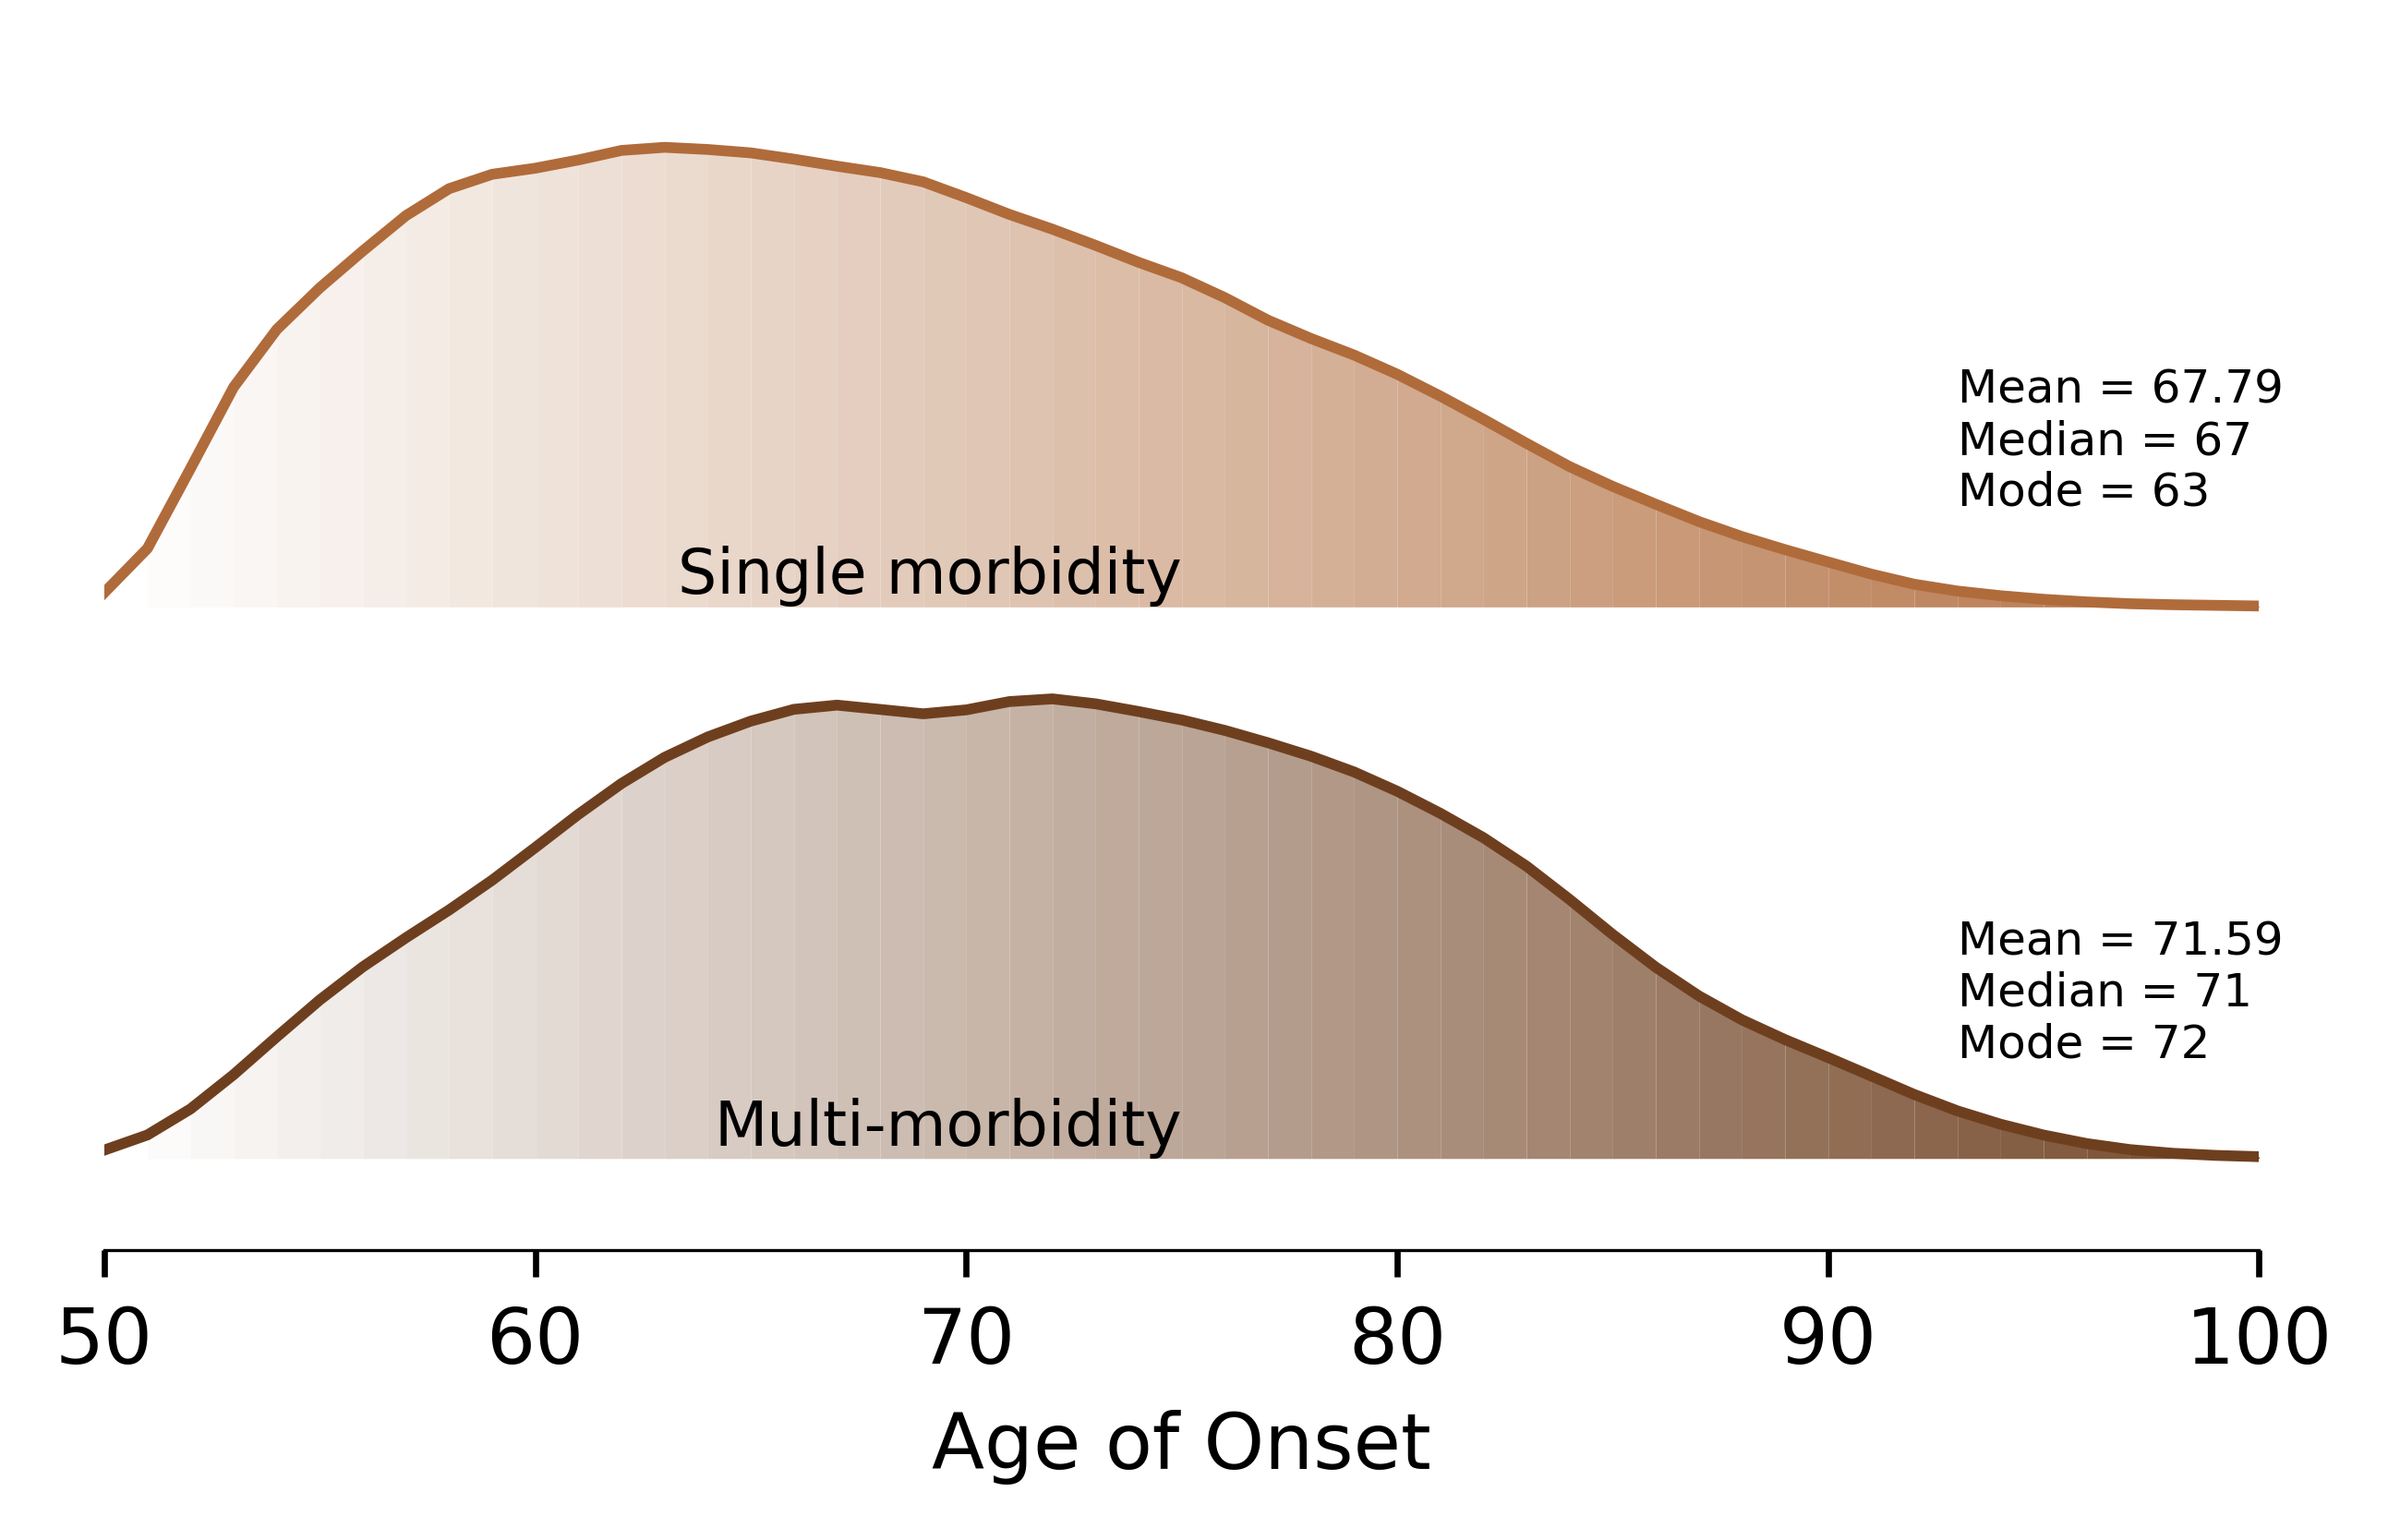

Saved: ../results/f4_disease_timevary/mm_onset_age_ridge_m56.pdf


In [8]:
# Ridge plot using Model 5/6 baseline sample
from scipy.stats import gaussian_kde


def _collect_onset_ages_m56() -> pd.DataFrame:
    intervals = load_or_build_mm_intervals(FOREST_BINS)
    if intervals.empty or "exit_t" not in intervals.columns:
        return pd.DataFrame()
    rows = []
    for label, onset_col in [
        ("Single morbidity", "mm1_onset"),
        ("Multimorbidity", "mm2p_onset"),
    ]:
        if onset_col not in intervals.columns:
            continue
        onset_rows = intervals.loc[intervals[onset_col] == 1]
        if onset_rows.empty:
            continue
        onset_ages = START_AGE + onset_rows["exit_t"].astype(float).to_numpy()
        for v in onset_ages:
            rows.append({"group": label, "onset_age": float(v)})
    return pd.DataFrame(rows)


def _load_onset_ages_m56() -> pd.DataFrame:
    onset_path = os.path.join(PRECOMPUTED_DIR, "mm_onset_ages_m56.csv")
    if os.path.exists(onset_path):
        df = pd.read_csv(onset_path)
        if not df.empty:
            return df
    return _collect_onset_ages_m56()


def _mm_ridge_label(name: str) -> str:
    if name == "Single morbidity":
        return "Single morbidity"
    if name == "Multimorbidity":
        return "Multi-morbidity"
    return name


def _mode_from_kde_mm(vals: np.ndarray, grid: np.ndarray) -> float:
    if vals.size < 2:
        return float(np.nan)
    kde = gaussian_kde(vals)
    dens = kde(grid)
    return float(grid[int(np.argmax(dens))])


def plot_onset_ridge_m56(out_path: str):
    long_df = _load_onset_ages_m56()
    if long_df.empty:
        print("No onset ages found for Model 5/6 ridge plot.")
        return
    group_order = ["Multimorbidity", "Single morbidity"]
    age_grid = np.arange(START_AGE, AGE_MAX + 1e-9, AGE_STEP)
    fig, ax = plt.subplots(figsize=(W_INCH * 1.05, H_INCH * 0.9), dpi=DPI_OUT)
    y_offset = 1.2
    mm_colors = {"Single morbidity": "#B06B3B", "Multimorbidity": "#6E3F1F"}
    for i, g in enumerate(group_order):
        vals = long_df.loc[long_df["group"] == g, "onset_age"].to_numpy()
        if vals.size < 2:
            continue
        kde = gaussian_kde(vals)
        dens = kde(age_grid)
        if dens.max() > 0:
            dens = dens / dens.max()
        y0 = i * y_offset
        base_hex = mm_colors.get(g, "#7D7D7D")
        light_rgb = (255, 255, 255)
        base_rgb = _hex_to_rgb(base_hex)
        for j in range(len(age_grid) - 1):
            x0 = age_grid[j]
            x1 = age_grid[j + 1]
            t = (x0 - START_AGE) / max(AGE_MAX - START_AGE, 1e-9)
            seg_color = _rgb_to_hex(_blend_rgb(light_rgb, base_rgb, t))
            ax.fill_between([x0, x1], [y0, y0], [y0 + dens[j], y0 + dens[j + 1]], color=seg_color, alpha=0.95, linewidth=0)
        ax.plot(age_grid, y0 + dens, color=base_hex, linewidth=1.4)
        ax.text(75, y0, _mm_ridge_label(g), ha="right", va="bottom", fontsize=FONT_SIZE - 1)
        mean_val = float(np.nanmean(vals))
        median_val = float(np.nanmedian(vals))
        mode_val = _mode_from_kde_mm(vals, age_grid)
        stat_text = (
            f"Mean = {mean_val:.2f}\n"
            f"Median = {int(round(median_val))}\n"
            f"Mode = {int(round(mode_val))}"
        )
        ax.text(93, y0 + 0.2, stat_text, ha="left", va="bottom", fontsize=FONT_SIZE - 3, color="#000000")
    ax.set_yticks([])
    ax.set_xlim(START_AGE, AGE_MAX)
    ax.set_ylim(-0.2, y_offset * len(group_order))
    ax.set_xticks(np.arange(50, 101, 10))
    ax.set_xlabel("Age of Onset")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.tick_params(axis="x", bottom=True, labelbottom=True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


ridge_m56_path = os.path.join(BASE_DIR, "mm_onset_age_ridge_m56.pdf")
plot_onset_ridge_m56(ridge_m56_path)

In [ ]:
# Sankey-style summary for Model 5/6 baseline sample
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle


def _mm_group_label(name: str) -> str:
    if name == "Single morbidity":
        return "Single\nmorbidity"
    if name == "Multimorbidity":
        return "Multi\nmorbidity"
    return name


def _fmt_count(value: int) -> str:
    return f"{int(value):,}"


def _layout_nodes_equal(names: List[str], y_top: float, y_bottom: float, pad: float = 0.0):
    if not names:
        return {}, 1.0
    height = y_top - y_bottom
    pad_total = pad * max(len(names) - 1, 0)
    node_h = (height - pad_total) / float(len(names)) if height > pad_total else height / float(len(names))
    y = y_top
    layout = {}
    for n in names:
        y0 = y - node_h
        layout[n] = {"top": y, "bottom": y0, "height": node_h}
        y = y0 - pad
    return layout, node_h


def _draw_flow(ax, x0: float, x1: float, y0: float, y1: float, width: float, color: str, alpha: float = 0.35):
    ctrl_dx = (x1 - x0) * 0.5
    verts = [
        (x0, y0 + width / 2.0),
        (x0 + ctrl_dx, y0 + width / 2.0),
        (x1 - ctrl_dx, y1 + width / 2.0),
        (x1, y1 + width / 2.0),
        (x1, y1 - width / 2.0),
        (x1 - ctrl_dx, y1 - width / 2.0),
        (x0 + ctrl_dx, y0 - width / 2.0),
        (x0, y0 - width / 2.0),
        (x0, y0 + width / 2.0),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.LINETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    patch = PathPatch(Path(verts, codes), facecolor=color, edgecolor="none", alpha=alpha)
    ax.add_patch(patch)


def _collect_mm_sankey_m56() -> Dict[str, object]:
    if "_load_dataset_map" not in globals() or "_baseline_no_mobility_counts" not in globals():
        print("Missing dataset helpers for Sankey plot.")
        return {}
    dataset_map = _load_dataset_map()
    if not dataset_map:
        return {}


    intervals = load_or_build_mm_intervals(FOREST_BINS)
    if intervals.empty:
        return {}


    left_totals = _baseline_no_mobility_counts(dataset_map)
    exclude_left = {"ELSI", "HAALSI"}
    left_totals = {k: v for k, v in left_totals.items() if k not in exclude_left}
    if not left_totals:
        return {}


    groups = ["Single morbidity", "Multimorbidity"]
    mid_counts: Dict[str, int] = {}
    right_counts: Dict[str, int] = {}
    links_left = []


    base_df = intervals[["id", "country"]].drop_duplicates()
    base_df["dataset"] = base_df["country"].map(dataset_map).fillna("Unknown")
    base_counts = base_df.groupby("dataset")["id"].nunique()


    for label, onset_col in [("Single morbidity", "mm1_onset"), ("Multimorbidity", "mm2p_onset")]:
        if onset_col not in intervals.columns:
            continue
        onset_df = intervals.loc[intervals[onset_col] == 1, ["id", "country"]].drop_duplicates()
        onset_df["dataset"] = onset_df["country"].map(dataset_map).fillna("Unknown")


        n_base = int(base_df["id"].nunique())
        n_onset = int(onset_df["id"].nunique())


        mid_counts[label] = n_base
        right_counts[label] = n_onset


        for dataset, val in base_counts.items():
            v = int(val)
            if v <= 0:
                continue
            links_left.append((dataset, label, v))


    left_nodes = sorted(left_totals.keys(), key=lambda s: str(s).lower())
    mid_nodes = [g for g in groups if g in mid_counts and mid_counts[g] > 0]
    right_nodes = [g for g in mid_nodes]


    return {
        "left_nodes": left_nodes,
        "mid_nodes": mid_nodes,
        "right_nodes": right_nodes,
        "left_totals": left_totals,
        "mid_counts": mid_counts,
        "right_counts": right_counts,
        "links_left": links_left,
    }


def plot_sankey_m56(out_path: str):
    data = _collect_mm_sankey_m56()
    if not data:
        print("No counts found for Model 5/6 Sankey plot.")
        return


    left_nodes = data["left_nodes"]
    mid_nodes = data["mid_nodes"]
    right_nodes = data["right_nodes"]
    left_totals = data["left_totals"]
    mid_counts = data["mid_counts"]
    right_counts = data["right_counts"]
    links_left = data["links_left"]


    left_layout, _ = _layout_nodes_equal(left_nodes, 0.95, 0.05)
    mid_layout, _ = _layout_nodes_equal(mid_nodes, 0.95, 0.05)
    right_layout, _ = _layout_nodes_equal(right_nodes, 0.95, 0.05)


    fig, ax = plt.subplots(figsize=(W_INCH * 2.2, H_INCH * 1.4), dpi=DPI_OUT)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")


    left_x = 0.02
    mid_x = 0.40
    right_x = 0.68
    node_w = 0.10
    mm_colors = {"Single morbidity": "#B06B3B", "Multimorbidity": "#6E3F1F"}
    left_band_colors = ["#F6F2EB", "#FAF9F5"]


    for idx, name in enumerate(left_nodes):
        box = left_layout.get(name)
        if not box:
            continue
        rect = Rectangle((left_x, box["bottom"]), node_w, box["height"], facecolor=left_band_colors[idx % 2], edgecolor="none")
        ax.add_patch(rect)
        ax.text(
            left_x + node_w / 2.0,
            (box["top"] + box["bottom"]) / 2.0,
            f"{name}\nn = {_fmt_count(left_totals.get(name, 0))}",
            ha="center",
            va="center",
            fontsize=FONT_SIZE + 1,
            color="#000000",
        )


    for name in mid_nodes:
        box = mid_layout.get(name)
        if not box:
            continue
        base_color = mm_colors.get(name, "#7D7D7D")
        rect = Rectangle((mid_x, box["bottom"]), node_w, box["height"], facecolor=base_color, edgecolor="none", alpha=0.3)
        ax.add_patch(rect)
        ax.text(
            mid_x + node_w / 2.0,
            (box["top"] + box["bottom"]) / 2.0,
            f"n = {_fmt_count(mid_counts.get(name, 0))}",
            ha="center",
            va="center",
            fontsize=FONT_SIZE + 1,
            color="#000000",
        )


    for name in right_nodes:
        box = right_layout.get(name)
        if not box:
            continue
        base_color = mm_colors.get(name, "#7D7D7D")
        rect = Rectangle((right_x, box["bottom"]), node_w, box["height"], facecolor=base_color, edgecolor="none", alpha=0.5)
        ax.add_patch(rect)
        ax.text(
            right_x + node_w / 2.0,
            (box["top"] + box["bottom"]) / 2.0,
            f"{_mm_group_label(name)}\n\nn = {_fmt_count(right_counts.get(name, 0))}",
            ha="center",
            va="center",
            fontsize=FONT_SIZE + 1,
            color="#FFFFFF",
        )


    mid_offsets = {n: 0.0 for n in mid_nodes}
    for dataset, group, val in links_left:
        if dataset not in left_layout or group not in mid_layout:
            continue
        box_l = left_layout[dataset]
        box_m = mid_layout[group]
        n_base = max(mid_counts.get(group, 0), 0)
        scale_mid = box_m["height"] / n_base if n_base > 0 else 0.0
        y_l_center = (box_l["top"] + box_l["bottom"]) / 2.0
        y_m_top = box_m["top"] - mid_offsets[group]
        y_m_bot = y_m_top - val * scale_mid
        mid_offsets[group] += val * scale_mid
        y0 = y_l_center
        y1 = (y_m_top + y_m_bot) / 2.0
        color = mm_colors.get(group, "#7D7D7D")
        flow_w = min(val * scale_mid, box_l["height"])
        _draw_flow(ax, left_x + node_w, mid_x, y0, y1, flow_w, color, alpha=0.35)


    for group in mid_nodes:
        n_onset = right_counts.get(group, 0)
        n_base = max(mid_counts.get(group, 0), 0)
        if n_onset <= 0 or n_base <= 0:
            continue
        box_m = mid_layout[group]
        box_r = right_layout[group]
        ratio = n_onset / n_base
        y0 = (box_m["top"] + box_m["bottom"]) / 2.0
        y1 = (box_r["top"] + box_r["bottom"]) / 2.0
        color = mm_colors.get(group, "#7D7D7D")
        flow_w = box_m["height"] * ratio
        _draw_flow(ax, mid_x + node_w, right_x, y0, y1, flow_w, color, alpha=0.35)
        ax.text(
            (mid_x + node_w + right_x) / 2.0,
            (y0 + y1) / 2.0,
            f"{ratio:.1%}",
            ha="center",
            va="center",
            fontsize=FONT_SIZE + 2,
            color="#000000",
        )


    plt.tight_layout()
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


sankey_m56_path = os.path.join(BASE_DIR, "mm_onset_sankey_m56.pdf")
plot_sankey_m56(sankey_m56_path)

Missing dataset helpers for Sankey plot.
No counts found for Model 5/6 Sankey plot.


In [ ]:
# Plot multimorbidity forest plots (Model 5/6 and Model 7/8)
def _mm_group_from_col(col: str) -> str:
    if col.startswith("mm1_") or col == "mm1_onset":
        return "mm1"
    return "mm2p"


def _mm_bin_label(col: str) -> str:
    parts = col.split("_", 1)
    return _bin_label(parts[1]) if len(parts) > 1 else col


def plot_mm_current_pair(hr5: pd.DataFrame, hr6: pd.DataFrame, out_path: str):
    if hr5.empty or hr6.empty:
        return
    work5 = hr5.copy()
    work6 = hr6.copy()
    work5["model"] = "Model 5"
    work6["model"] = "Model 6"
    work = pd.concat([work5, work6], ignore_index=True)
    work["group"] = work["col"].apply(_mm_group_from_col)
    group_order = ["mm1", "mm2p"]
    group_labels = {
        "mm1": "Single\nmorbidity",
        "mm2p": "Multimorbidity",
    }
    y_map = []
    idx = 0.0
    group_gap = 0.25
    for g in group_order:
        y_map.append({"group": g, "y": idx})
        idx += 1.0 + group_gap
    y_df = pd.DataFrame(y_map)
    y_base = {row["group"]: row["y"] for _, row in y_df.iterrows()}
    offsets = {"Model 5": -0.18, "Model 6": 0.18}
    mm_colors = {"mm1": "#B06B3B", "mm2p": "#6E3F1F"}
    fig, ax = plt.subplots(figsize=(W_INCH, H_INCH / 3.0), dpi=DPI_OUT)
    for g, y0 in y_base.items():
        base_color = mm_colors.get(g, "#888888")
        ax.axhspan(y0 - 0.5, y0 + 0.5, color=_band_rgba(base_color, alpha=0.08), zorder=0)
    for _, r in work.iterrows():
        g = str(r["group"])
        base_color = mm_colors.get(g, "#444444")
        point_color = lighten_color(base_color, factor=0.5) if r["model"] == "Model 5" else lighten_color(base_color, factor=0.2)
        y = y_base[g] + offsets.get(r["model"], 0.0)
        ax.errorbar(
            float(r["HR"]),
            y,
            xerr=[[float(r["HR"]) - float(r["HR_l"])], [float(r["HR_u"]) - float(r["HR"]) ]],
            fmt="o",
            color=point_color,
            ecolor=point_color,
            markersize=4,
            elinewidth=0.6,
            capsize=2,
            zorder=3,
        )
        ua = "U" if r["model"] == "Model 5" else "A"
        ua_shift = -0.06 if r["model"] == "Model 5" else 0.06
        ax.text(1.01, y + ua_shift, ua, transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=FONT_SIZE - 2, color=base_color)
    ax.axvline(1.0, color="#606060", linewidth=0.8, linestyle="--")
    ax.set_yticks(y_df["y"].to_numpy())
    ax.set_yticklabels([group_labels[g] for g in group_order], fontsize=FONT_SIZE - 2)
    ax.set_xlabel("Hazard Ratio", fontsize=FONT_SIZE-2)
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4)
    from matplotlib.ticker import FormatStrFormatter
    ax.set_xlim(0.9, 3.1)
    ax.set_xticks(np.arange(1.0, 3.0 + 1e-9, 0.5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
    ax.set_ylim(y_df["y"].min() - 0.5, y_df["y"].max() + 0.5)
    ax.margins(y=0)
    ax.invert_yaxis()
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.16, right=0.93)
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


def plot_mm_long_pair(hr7: pd.DataFrame, hr8: pd.DataFrame, out_path: str):
    if hr7.empty or hr8.empty:
        return
    work7 = hr7.copy()
    work8 = hr8.copy()
    work7["model"] = "Model 7"
    work8["model"] = "Model 8"
    work = pd.concat([work7, work8], ignore_index=True)
    work["group"] = work["bin"].apply(_mm_group_from_col)
    work["bin_label"] = work["bin"].apply(_mm_bin_label)
    group_order = ["mm1", "mm2p"]
    group_labels = {
        "mm1": "Single\nmorbidity",
        "mm2p": "Multimorbidity",
    }
    bin_order = [_bin_label(bc) for bc in make_bin_columns(FOREST_BINS)]
    mm_colors = {"mm1": "#B06B3B", "mm2p": "#6E3F1F"}
    y_map = []
    group_centers = []
    idx = 0
    for g in group_order:
        sub = work.loc[work["group"] == g]
        if sub.empty:
            continue
        start_idx = idx
        for bl in bin_order:
            key = f"{g}||{bl}"
            if sub.loc[sub["bin_label"] == bl].empty:
                continue
            y_map.append({"group_key": key, "y": idx, "bin_label": bl, "group": g})
            idx += 1
        end_idx = idx - 1
        if end_idx >= start_idx:
            group_centers.append({"group": g, "center": (start_idx + end_idx) / 2.0})
            y_map.append({"group_key": f"__band__{g}", "y": (start_idx, end_idx), "bin_label": "", "group": g})
        idx += 0.6
    y_df = pd.DataFrame([row for row in y_map if not row["group_key"].startswith("__band__")])
    work["group_key"] = work["group"].astype(str) + "||" + work["bin_label"].astype(str)
    work = work.merge(y_df[["group_key", "y", "bin_label"]], on="group_key", how="left")
    fig, ax = plt.subplots(figsize=(W_INCH * 1.35, H_INCH * 1.7), dpi=DPI_OUT)
    for row in y_map:
        if row["group_key"].startswith("__band__"):
            g = row["group"]
            base_color = mm_colors.get(g, "#888888")
            start_i, end_i = row["y"]
            ax.axhspan(start_i - 0.4, end_i + 0.4, color=_band_rgba(base_color, alpha=0.08), zorder=0)
    offsets = {"Model 7": -0.12, "Model 8": 0.12}
    for _, r in work.iterrows():
        if pd.isna(r.get("y")):
            continue
        g = str(r["group"])
        base_color = mm_colors.get(g, "#444444")
        point_color = lighten_color(base_color, factor=0.35) if r["model"] == "Model 7" else base_color
        y = float(r["y"]) + offsets.get(r["model"], 0.0)
        ax.errorbar(
            float(r["HR"]),
            y,
            xerr=[[float(r["HR"]) - float(r["HR_l"])], [float(r["HR_u"]) - float(r["HR"]) ]],
            fmt="o",
            color=point_color,
            ecolor=point_color,
            elinewidth=0.9,
            capsize=3,
            zorder=3,
        )
        ua = "U" if r["model"] == "Model 7" else "A"
        ua_shift = -0.06 if r["model"] == "Model 7" else 0.06
        ax.text(1.01, y + ua_shift, ua, transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=FONT_SIZE - 2, color=point_color)
    ax.axvline(1.0, color="#606060", linewidth=0.8, linestyle="--")
    y_df = y_df.sort_values("y")
    ax.set_yticks(y_df["y"].to_numpy())
    ax.set_yticklabels(y_df["bin_label"].tolist(), fontsize=FONT_SIZE - 1)
    ax.set_xlabel("Hazard Ratio (time since onset)", fontsize=FONT_SIZE)
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 2, width=0.4)
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
    for gc in group_centers:
        ax.text(-0.1, gc["center"], group_labels[gc["group"]], transform=ax.get_yaxis_transform(), ha="right", va="center", fontsize=FONT_SIZE, color="#000000")
    ax.invert_yaxis()
    if not y_df.empty:
        ax.set_ylim(y_df["y"].min() - 0.4, y_df["y"].max() + 0.4)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.16, left=0.2, right=0.93)
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


m5_dir = os.path.join(BASE_DIR, "model5_mm_current_unadj")
m6_dir = os.path.join(BASE_DIR, "model6_mm_current_adj")
m7_dir = os.path.join(BASE_DIR, "model7_mm_long_unadj")
m8_dir = os.path.join(BASE_DIR, "model8_mm_long_adj")


hr5 = pd.read_csv(os.path.join(m5_dir, "hr_model5_mm_current.csv")) if os.path.exists(os.path.join(m5_dir, "hr_model5_mm_current.csv")) else pd.DataFrame()
hr6 = pd.read_csv(os.path.join(m6_dir, "hr_model6_mm_current.csv")) if os.path.exists(os.path.join(m6_dir, "hr_model6_mm_current.csv")) else pd.DataFrame()
hr7 = pd.read_csv(os.path.join(m7_dir, "hr_model7_mm_long.csv")) if os.path.exists(os.path.join(m7_dir, "hr_model7_mm_long.csv")) else pd.DataFrame()
hr8 = pd.read_csv(os.path.join(m8_dir, "hr_model8_mm_long.csv")) if os.path.exists(os.path.join(m8_dir, "hr_model8_mm_long.csv")) else pd.DataFrame()


plot_mm_current_pair(hr5, hr6, os.path.join(BASE_DIR, "model5_6_mm_current_forest.pdf"))
plot_mm_long_pair(hr7, hr8, os.path.join(BASE_DIR, "model7_8_mm_long_forest.pdf"))


In [22]:
# YOML2 from multimorbidity current-onset HRs (Model 5/6)
def _get_param(params_df: pd.DataFrame, name: str) -> float:
    row = params_df.loc[params_df["param"] == name]
    if row.empty:
        return np.nan
    return float(row["estimate"].iloc[0])


def _get_beta(params_df: pd.DataFrame, col: str) -> float:
    return _get_param(params_df, f"beta_{col}")


def _xbeta_from_row(row: pd.Series, params_df: pd.DataFrame, cov_cols: List[str]) -> float:
    xbeta = 0.0
    for c in cov_cols:
        beta_c = _get_beta(params_df, c)
        val = row.get(c, 0.0)
        if pd.isna(val) or np.isnan(beta_c):
            continue
        xbeta += beta_c * float(val)
    country = str(row.get("country", ""))
    if country:
        beta_cty = _get_beta(params_df, f"cty_{country}")
        if not np.isnan(beta_cty):
            xbeta += beta_cty
    return xbeta


def _bootstrap_mean_ci(
    values: np.ndarray,
    n_boot: int = 1000,
    ci_alpha: float = 0.05,
    seed: int = 123,
) -> Tuple[float, float]:
    vals = values[np.isfinite(values)]
    if vals.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, vals.size, size=(n_boot, vals.size))
    boot_means = vals[idx].mean(axis=1)
    lower_q = 100 * (ci_alpha / 2.0)
    upper_q = 100 * (1.0 - ci_alpha / 2.0)
    return (
        float(np.nanpercentile(boot_means, lower_q)),
        float(np.nanpercentile(boot_means, upper_q)),
    )


def _yoml_from_constant_hr(
    intervals: pd.DataFrame,
    params_df: pd.DataFrame,
    onset_flag: str,
    cov_cols: List[str],
    beta_col: str,
    ci_alpha: float = 0.05,
    n_boot: int = 1000,
    seed: int = 123,
) -> Tuple[float, float, float, float, float, int]:
    onset_rows = intervals.loc[intervals[onset_flag] == 1].copy()
    if onset_rows.empty:
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    log_lambda = _get_param(params_df, "log_lambda")
    gamma = _get_param(params_df, "gamma")
    beta_onset = _get_beta(params_df, beta_col)
    if np.isnan(log_lambda) or np.isnan(gamma):
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    if np.isnan(beta_onset):
        beta_onset = 0.0
    cwle_ref_list = []
    cwle_dis_list = []
    yoml_list = []
    for _, row in onset_rows.iterrows():
        onset_age = START_AGE + float(row["exit_t"])
        if onset_age >= AGE_MAX:
            continue
        ages = np.arange(onset_age, AGE_MAX + 1e-9, AGE_STEP)
        t_abs = ages - START_AGE
        xbeta_ref = _xbeta_from_row(row, params_df, cov_cols)
        h0 = gompertz_hazard(t_abs, log_lambda, gamma)
        h_ref = np.exp(xbeta_ref) * h0
        h_dis = np.exp(xbeta_ref + beta_onset) * h0
        H_ref = np.cumsum(h_ref * AGE_STEP)
        H_dis = np.cumsum(h_dis * AGE_STEP)
        S_ref = np.exp(-H_ref)
        S_dis = np.exp(-H_dis)
        cwle_ref = onset_age + trapz(ages, S_ref)
        cwle_dis = onset_age + trapz(ages, S_dis)
        yoml = cwle_ref - cwle_dis
        cwle_ref_list.append(cwle_ref)
        cwle_dis_list.append(cwle_dis)
        yoml_list.append(yoml)
    if not yoml_list:
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    yoml_arr = np.array(yoml_list, dtype=float)
    yoml_mean = float(np.nanmean(yoml_arr))
    yoml_l, yoml_u = _bootstrap_mean_ci(yoml_arr, n_boot=n_boot, ci_alpha=ci_alpha, seed=seed)
    return (
        float(np.nanmean(cwle_ref_list)),
        float(np.nanmean(cwle_dis_list)),
        yoml_mean,
        yoml_l,
        yoml_u,
        int(len(yoml_arr)),
    )


def compute_mm_yoml_from_model56() -> pd.DataFrame:
    out_path = os.path.join(BASE_DIR, "yoml_mm_model5_6.csv")
    if os.path.exists(out_path) and not FORCE_REBUILD:
        cached = pd.read_csv(out_path)
        if not cached.empty:
            print("Loaded:", out_path)
            return cached
    path_m5 = os.path.join(BASE_DIR, "model5_mm_current_unadj", "params_model5_mm_current.csv")
    path_m6 = os.path.join(BASE_DIR, "model6_mm_current_adj", "params_model6_mm_current.csv")
    if not os.path.exists(path_m5) or not os.path.exists(path_m6):
        print("Missing Model 5/6 params, run multimorbidity models first.")
        return pd.DataFrame()
    params_m5 = pd.read_csv(path_m5)
    params_m6 = pd.read_csv(path_m6)
    if params_m5.empty or params_m6.empty:
        return pd.DataFrame()
    intervals = load_or_build_mm_intervals(FOREST_BINS)
    if intervals.empty:
        return pd.DataFrame()
    n_base = int(intervals["id"].nunique()) if "id" in intervals.columns else np.nan


    out_rows = []
    for params_df, model_label, cov_cols in [
        (params_m5, "U", []),
        (params_m6, "A", controls),
    ]:
        cwle_ref, cwle_dis, yoml, yoml_l, yoml_u, n_onset = _yoml_from_constant_hr(
            intervals,
            params_df,
            onset_flag="mm1_onset",
            cov_cols=cov_cols,
            beta_col="mm1_onset",
        )
        out_rows.append({
            "group": "Single morbidity",
            "model": model_label,
            "cwle_ref": cwle_ref,
            "cwle_disease": cwle_dis,
            "yoml": yoml,
            "yoml_l": yoml_l,
            "yoml_u": yoml_u,
            "n_onset": n_onset,
            "n_base": n_base,
        })


        cwle_ref, cwle_dis, yoml, yoml_l, yoml_u, n_onset = _yoml_from_constant_hr(
            intervals,
            params_df,
            onset_flag="mm2p_onset",
            cov_cols=cov_cols,
            beta_col="mm2p_onset",
        )
        out_rows.append({
            "group": "Multimorbidity",
            "model": model_label,
            "cwle_ref": cwle_ref,
            "cwle_disease": cwle_dis,
            "yoml": yoml,
            "yoml_l": yoml_l,
            "yoml_u": yoml_u,
            "n_onset": n_onset,
            "n_base": n_base,
        })


    return pd.DataFrame(out_rows)


mm_yoml_df = compute_mm_yoml_from_model56()
if not mm_yoml_df.empty:
    out_path = os.path.join(BASE_DIR, "yoml_mm_model5_6.csv")
    if not (os.path.exists(out_path) and not FORCE_REBUILD):
        mm_yoml_df.to_csv(out_path, index=False)
        print("Saved:", out_path)
    else:
        print("Loaded:", out_path)
else:
    print("mm_yoml_df is empty; run Model 5/6 first.")

Saved: ../results/f4_disease_timevary/yoml_mm_model5_6.csv


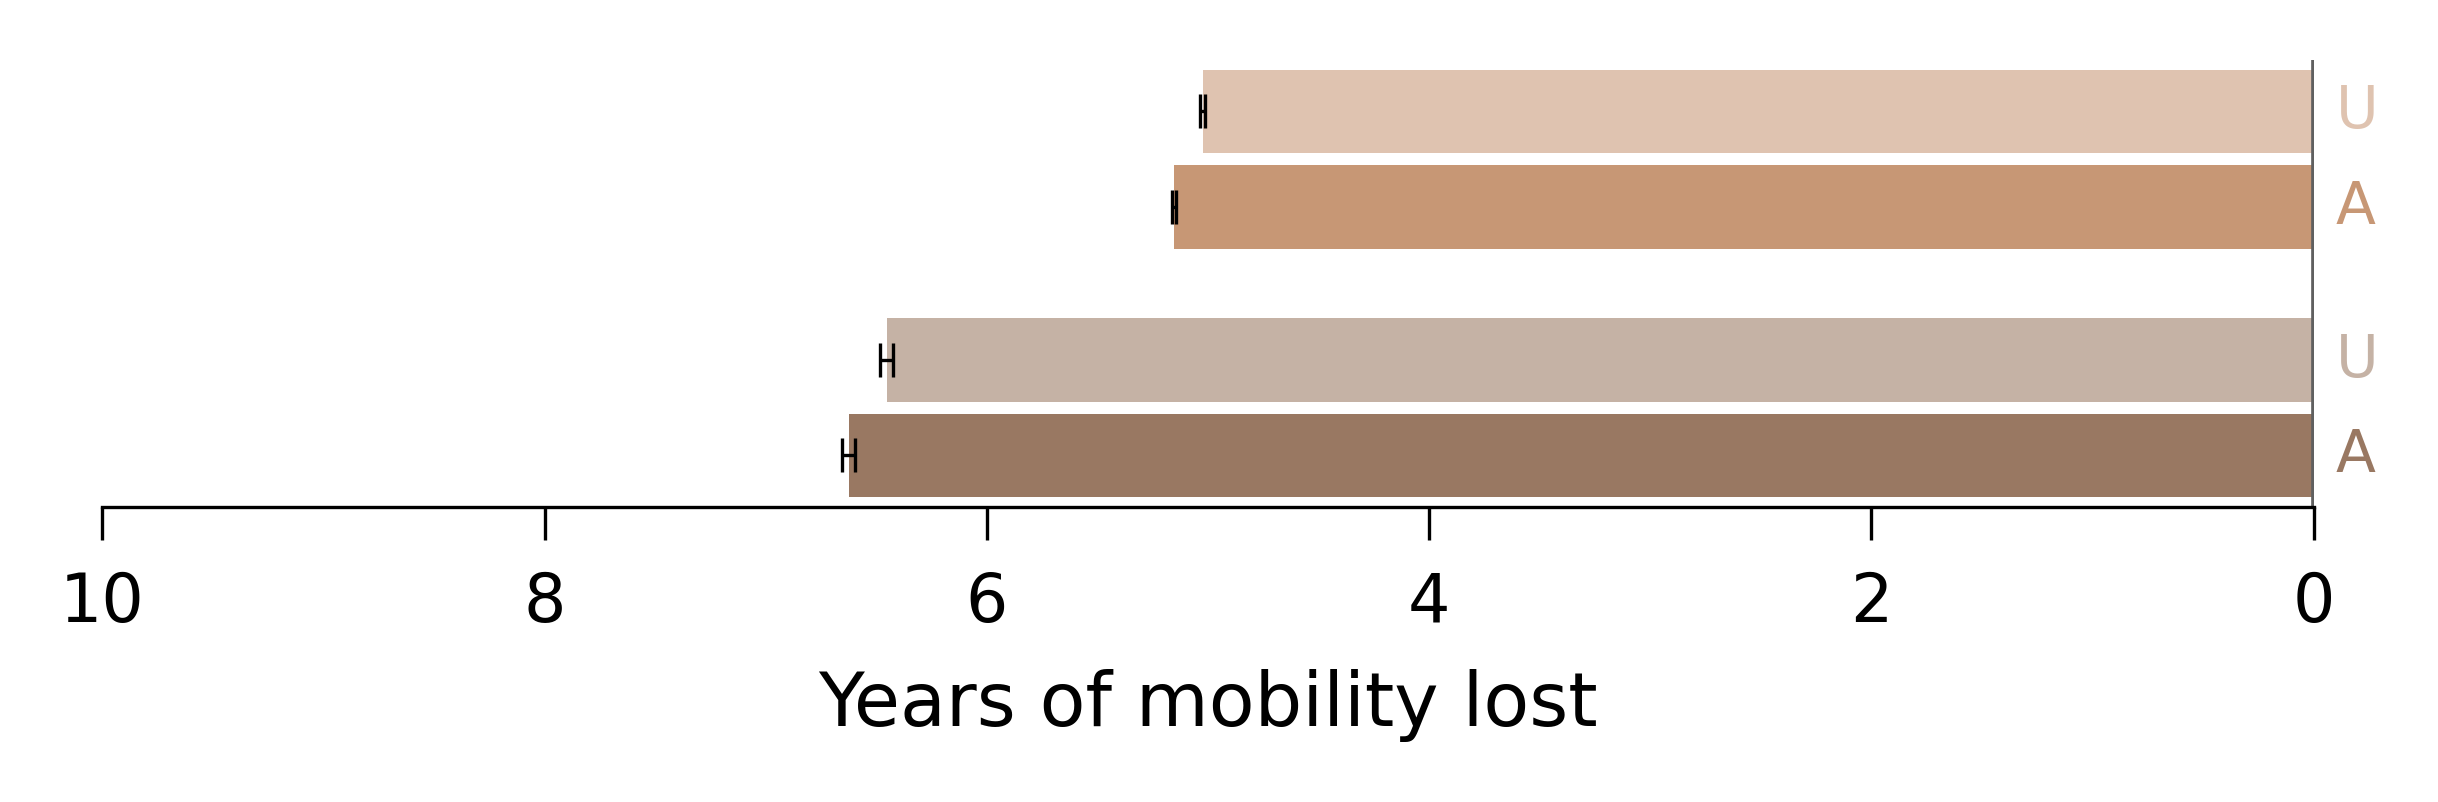

Saved: ../results/f4_disease_timevary/yoml_mm_barplot.pdf


In [77]:
# Plot YOML2 bar chart (Model 5/6)
def plot_mm_yoml_bar(yoml_df: pd.DataFrame, out_path: str):
    if yoml_df.empty:
        return
    order = ["Multimorbidity", "Single morbidity"]
    mm_colors = {"Single morbidity": "#B06B3B", "Multimorbidity": "#6E3F1F"}
    work = yoml_df.copy()
    work["group"] = pd.Categorical(work["group"], categories=order, ordered=True)
    work["model"] = pd.Categorical(work["model"], categories=["A", "U"], ordered=True)
    work = work.sort_values(["group", "model"])


    y_map = []
    idx = 0.0
    group_gap = 0.25
    for g in order:
        y_map.append({"group": g, "y": idx})
        idx += 1.0 + group_gap
    y_df = pd.DataFrame(y_map)
    y_base = {row["group"]: row["y"] for _, row in y_df.iterrows()}
    offsets = {"A": -0.24, "U": 0.24}
    fig, ax = plt.subplots(figsize=(W_INCH, H_INCH / 3.0), dpi=DPI_OUT)
    for _, r in work.iterrows():
        group = str(r["group"])
        base_color = mm_colors.get(group, "#4C72B0")
        bar_color = lighten_color(base_color, factor=0.6) if r["model"] == "U" else lighten_color(base_color, factor=0.3)
        y = y_base[group] + offsets.get(r["model"], 0.0)
        v = float(r["yoml"])
        v_l = float(r["yoml_l"]) if np.isfinite(r["yoml_l"]) else v
        v_u = float(r["yoml_u"]) if np.isfinite(r["yoml_u"]) else v
        ax.barh(y, v, height=0.42, color=bar_color, edgecolor="none", linewidth=0.4)
        if np.isfinite(v_l) and np.isfinite(v_u):
            ax.errorbar(
                v,
                y,
                xerr=[[v - v_l], [v_u - v]],
                fmt="none",
                ecolor="#000000",
                elinewidth=0.4,
                capsize=2,
                capthick=0.4,
                zorder=3,
            )
        ax.text(1.01, y, r["model"], transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=FONT_SIZE - 2, color=bar_color)


    ax.axvline(0, color="#606060", linewidth=0.8)
    ax.set_xlim(10, 0)
    ax.set_xticks(np.arange(10, -0.1, -2))
    ax.set_yticks(y_df["y"].to_numpy())
    ax.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
    ax.set_xlabel("Years of mobility lost", fontsize=FONT_SIZE)
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4, length=4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.invert_yaxis()
    ax.set_ylim(y_df["y"].min() - 0.5, y_df["y"].max() + 0.5)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.16, right=0.93)
    plt.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


if "mm_yoml_df" in globals() and isinstance(mm_yoml_df, pd.DataFrame) and not mm_yoml_df.empty:
    plot_mm_yoml_bar(mm_yoml_df, os.path.join(BASE_DIR, "yoml_mm_barplot.pdf"))
else:
    print("mm_yoml_df is empty; run the YOML2 calculation cell first.")

In [24]:
# Print YOML2 and CI (Model 5/6)
if "mm_yoml_df" in globals() and isinstance(mm_yoml_df, pd.DataFrame) and not mm_yoml_df.empty:
    cols = ["group", "model", "yoml", "yoml_l", "yoml_u", "n_onset", "n_base"]
    print("YOML2 (Model 5/6):")
    print(mm_yoml_df.loc[:, cols].to_string(index=False))
else:
    print("mm_yoml_df is empty; run the YOML2 calculation cell first.")

YOML2 (Model 5/6):
           group model     yoml   yoml_l   yoml_u  n_onset  n_base
Single morbidity     U 5.024618 5.014281 5.034140    48857  137950
  Multimorbidity     U 6.452293 6.423057 6.482774    11544  137950
Single morbidity     A 5.154348 5.143936 5.164678    48857  137950
  Multimorbidity     A 6.625093 6.594131 6.656860    11544  137950


In [ ]:
# Supplement: first-disease composition for pooled single morbidity in Model 5/6
SINGLE_FIRST_DIR = os.path.join(BASE_DIR, "single_morbidity_first_disease")
os.makedirs(SINGLE_FIRST_DIR, exist_ok=True)
ONSET_AGES_PATH = os.path.join(BASE_DIR, "onset_ages.csv")

FIRST_DISEASE_LABEL = disease_label.copy()


def compute_single_morbidity_first_disease_composition() -> pd.DataFrame:
    comp_path = os.path.join(SINGLE_FIRST_DIR, "single_morbidity_first_disease_composition.csv")
    if os.path.exists(comp_path) and not FORCE_REBUILD:
        return pd.read_csv(comp_path)

    onset_cols = [f"{dc}_onset_age" for dc in disease_cols]
    onset = pd.read_csv(ONSET_AGES_PATH, usecols=["id", "country", "mm_baseline_ok"] + onset_cols)
    onset = onset.loc[onset["mm_baseline_ok"] == True].copy()
    for c in onset_cols:
        onset[c] = pd.to_numeric(onset[c], errors="coerce")

    ages = onset[onset_cols]
    onset["first_onset_age"] = ages.min(axis=1, skipna=True)
    has_first = onset["first_onset_age"].notna()
    first_count = ages.eq(onset["first_onset_age"], axis=0).sum(axis=1)

    # Model 5/6 single morbidity is the 0 -> 1 transition, so keep only unique first disease onsets.
    onset["first_disease_code"] = pd.Series(pd.NA, index=onset.index, dtype="object")
    for dc in disease_cols:
        is_unique_first = has_first & (first_count == 1) & onset[f"{dc}_onset_age"].eq(onset["first_onset_age"])
        onset.loc[is_unique_first, "first_disease_code"] = dc

    single_first = onset.loc[onset["first_disease_code"].notna()].copy()
    total = len(single_first)
    comp = (
        single_first.groupby("first_disease_code", dropna=False)
        .size()
        .reset_index(name="n_first_onset")
    )
    comp["first_disease"] = comp["first_disease_code"].map(FIRST_DISEASE_LABEL)
    comp["proportion"] = comp["n_first_onset"] / total if total else np.nan
    comp["total_single_morbidity_first_onset"] = total
    comp = comp.loc[:, ["first_disease_code", "first_disease", "n_first_onset", "proportion", "total_single_morbidity_first_onset"]]
    comp = comp.sort_values("n_first_onset", ascending=False).reset_index(drop=True)
    comp.to_csv(comp_path, index=False)
    return comp


single_first_comp = compute_single_morbidity_first_disease_composition()
print("Saved:", os.path.join(SINGLE_FIRST_DIR, "single_morbidity_first_disease_composition.csv"))
print(single_first_comp.to_string(index=False))


In [ ]:
# Supplement plot: first-disease composition for pooled single morbidity in Model 5/6

def _first_disease_colors() -> Dict[str, str]:
    return {
        "Arthritis": "#A981BD",
        "Heart disease": "#F06054",
        "Cancer": "#7D7D7D",
        "Stroke": "#6FAA8C",
        "Lung disease": "#FCA86C",
        "Alzheimer's disease": "#427CC4",
    }


def plot_first_disease_composition(comp: pd.DataFrame, out_path: str):
    work = comp.sort_values("proportion", ascending=True).copy()
    colors = _first_disease_colors()
    fig_h = max(3.0, 0.34 * len(work) + 0.9)
    fig, ax = plt.subplots(figsize=(4.8, fig_h), dpi=DPI_OUT)
    y = np.arange(len(work))
    vals = work["proportion"] * 100
    ax.barh(y, vals, color=[colors.get(x, "#999999") for x in work["first_disease"]], edgecolor="none", alpha=0.88)
    for yi, val, n in zip(y, vals, work["n_first_onset"]):
        ax.text(val + 0.6, yi, f"{val:.1f}% (n={int(n):,})", ha="left", va="center", fontsize=FONT_SIZE - 2)
    ax.set_yticks(y)
    ax.set_yticklabels(work["first_disease"], fontsize=FONT_SIZE - 1)
    ax.set_xlabel("Composition of pooled single morbidity (%)", fontsize=FONT_SIZE)
    ax.set_xlim(0, max(vals.max() + 8, 10))
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4, length=3)
    ax.tick_params(axis="y", width=0.0, length=0)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    plt.tight_layout()
    fig.savefig(out_path, dpi=DPI_OUT, bbox_inches="tight", facecolor="white", edgecolor="none")
    plt.close(fig)
    print("Saved:", out_path)

plot_first_disease_composition(
    single_first_comp,
    os.path.join(SINGLE_FIRST_DIR, "single_morbidity_first_disease_composition.pdf"),
)


In [28]:
# Supplement: frequency-weighted average effect across six first diseases for single morbidity
SINGLE_FIRST_DIR = os.path.join(BASE_DIR, "single_morbidity_first_disease")
os.makedirs(SINGLE_FIRST_DIR, exist_ok=True)
MM_INTERVAL_PATH = os.path.join(CACHE_DIR, "intervals_mm_0_2_2_5_5_p.csv")
ONSET_AGES_PATH = os.path.join(BASE_DIR, "onset_ages.csv")
WEIGHTED_COMPONENT_PATH = os.path.join(SINGLE_FIRST_DIR, "single_morbidity_first_disease_weighted_components.csv")
WEIGHTED_AVERAGE_PATH = os.path.join(SINGLE_FIRST_DIR, "single_morbidity_first_disease_weighted_average_effect.csv")

FIRST_DISEASE_LABEL = disease_label.copy()
FIRST_DISEASE_COLS = [f"first_{dc}_onset" for dc in disease_cols]
FIRST_DISEASE_GROUPS = disease_cols


def _build_single_first_table_for_weighted() -> pd.DataFrame:
    onset_cols = [f"{dc}_onset_age" for dc in disease_cols]
    onset = pd.read_csv(ONSET_AGES_PATH, usecols=["id", "country", "mm_baseline_ok"] + onset_cols)
    onset["id"] = onset["id"].astype(str)
    onset["country"] = onset["country"].astype(str)
    onset = onset.loc[onset["mm_baseline_ok"] == True].copy()
    for c in onset_cols:
        onset[c] = pd.to_numeric(onset[c], errors="coerce")
    ages = onset[onset_cols]
    onset["first_onset_age"] = ages.min(axis=1, skipna=True)
    has_first = onset["first_onset_age"].notna()
    first_count = ages.eq(onset["first_onset_age"], axis=0).sum(axis=1)
    onset["first_disease_code"] = pd.Series(pd.NA, index=onset.index, dtype="object")
    for dc in disease_cols:
        is_unique_first = has_first & (first_count == 1) & onset[f"{dc}_onset_age"].eq(onset["first_onset_age"])
        onset.loc[is_unique_first, "first_disease_code"] = dc
    onset["first_disease"] = onset["first_disease_code"].map(FIRST_DISEASE_LABEL)
    return onset


def _build_single_first_intervals_for_weighted(first_df: pd.DataFrame) -> pd.DataFrame:
    intervals = pd.read_csv(MM_INTERVAL_PATH)
    intervals["id"] = intervals["id"].astype(str)
    intervals["country"] = intervals["country"].astype(str)
    intervals = intervals.loc[:, ["id", "country", "entry_t", "exit_t", "event_w"] + controls].copy()
    intervals = intervals.merge(
        first_df[["id", "country", "first_onset_age", "first_disease_code"]],
        on=["id", "country"],
        how="left",
    )
    entry_age = START_AGE + intervals["entry_t"].astype(float)
    exit_age = START_AGE + intervals["exit_t"].astype(float)
    is_single_first_interval = (
        intervals["first_disease_code"].notna()
        & intervals["first_onset_age"].notna()
        & (intervals["first_onset_age"] > entry_age)
        & (intervals["first_onset_age"] <= exit_age)
    )
    for dc in disease_cols:
        intervals[f"first_{dc}_onset"] = (is_single_first_interval & intervals["first_disease_code"].eq(dc)).astype(float)
    return intervals


def compute_single_morbidity_weighted_average_effect() -> Tuple[pd.DataFrame, pd.DataFrame]:
    if all(os.path.exists(x) for x in [WEIGHTED_COMPONENT_PATH, WEIGHTED_AVERAGE_PATH]) and not FORCE_REBUILD:
        return pd.read_csv(WEIGHTED_COMPONENT_PATH), pd.read_csv(WEIGHTED_AVERAGE_PATH)

    first_df = _build_single_first_table_for_weighted()
    single_first = first_df.loc[first_df["first_disease_code"].notna()].copy()
    comp = (
        single_first.groupby("first_disease_code", dropna=False)
        .size()
        .reset_index(name="n_first_onset")
    )
    comp["first_disease"] = comp["first_disease_code"].map(FIRST_DISEASE_LABEL)
    comp["weight"] = comp["n_first_onset"] / comp["n_first_onset"].sum()

    intervals = _build_single_first_intervals_for_weighted(first_df)
    fit = fit_timevary_model(intervals, FIRST_DISEASE_COLS + controls, use_country_fe=True)
    if fit is None:
        raise RuntimeError("Weighted first-disease model did not fit.")
    params_df = fit["params"].copy()
    cov = fit.get("cov")

    hr = hr_from_params_cols(params_df, FIRST_DISEASE_COLS)
    if "logHR" not in hr.columns:
        hr["logHR"] = np.log(hr["HR"].astype(float))
    if "se" not in hr.columns:
        se_map = {}
        for col in FIRST_DISEASE_COLS:
            row = params_df.loc[params_df["param"].eq(f"beta_{col}")]
            se_map[col] = float(row["se"].iloc[0]) if not row.empty else np.nan
        hr["se"] = hr["col"].map(se_map)
    hr["first_disease_code"] = hr["col"].str.replace("first_", "", regex=False).str.replace("_onset", "", regex=False)
    hr["first_disease"] = hr["first_disease_code"].map(FIRST_DISEASE_LABEL)

    rows = []
    n_base = int(intervals["id"].nunique()) if "id" in intervals.columns else np.nan
    for group, col in zip(FIRST_DISEASE_GROUPS, FIRST_DISEASE_COLS):
        cwle_ref, cwle_dis, yoml, yoml_l, yoml_u, n_onset = _yoml_from_constant_hr(
            intervals,
            params_df,
            onset_flag=col,
            cov_cols=controls,
            beta_col=col,
            n_boot=1000,
            seed=4000 + len(rows),
        )
        rows.append({
            "first_disease_code": group,
            "first_disease": FIRST_DISEASE_LABEL.get(group, group),
            "cwle_ref": cwle_ref,
            "cwle_disease": cwle_dis,
            "yoml": yoml,
            "yoml_l": yoml_l,
            "yoml_u": yoml_u,
            "n_onset_yoml": n_onset,
            "n_base": n_base,
        })
    yoml_df = pd.DataFrame(rows)

    components = (
        comp.merge(hr[["first_disease_code", "HR", "HR_l", "HR_u", "logHR", "se"]], on="first_disease_code", how="left")
        .merge(yoml_df, on=["first_disease_code", "first_disease"], how="left")
    )
    components = components.sort_values("weight", ascending=False).reset_index(drop=True)
    components["weighted_logHR_component"] = components["weight"] * components["logHR"]
    components["weighted_yoml_component"] = components["weight"] * components["yoml"]

    weighted_logHR = float(components["weighted_logHR_component"].sum())
    weighted_HR = float(np.exp(weighted_logHR))
    weighted_yoml = float(components["weighted_yoml_component"].sum())
    weighted_cwle_ref = float((components["weight"] * components["cwle_ref"]).sum())
    weighted_cwle_disease = float((components["weight"] * components["cwle_disease"]).sum())

    weighted_logHR_se = np.nan
    weighted_HR_l = np.nan
    weighted_HR_u = np.nan
    if cov is not None and np.all(np.isfinite(cov)):
        param_names = params_df["param"].tolist()
        beta_params = [f"beta_{col}" for col in FIRST_DISEASE_COLS]
        beta_idx = [param_names.index(bp) for bp in beta_params if bp in param_names]
        if len(beta_idx) == len(FIRST_DISEASE_COLS):
            cov_beta = cov[np.ix_(beta_idx, beta_idx)]
            weight_map = dict(zip(components["first_disease_code"], components["weight"]))
            w = np.array([weight_map[dc] for dc in FIRST_DISEASE_GROUPS], dtype=float)
            var = float(w @ cov_beta @ w)
            if var >= 0:
                weighted_logHR_se = float(np.sqrt(var))
                weighted_HR_l = float(np.exp(weighted_logHR - 1.96 * weighted_logHR_se))
                weighted_HR_u = float(np.exp(weighted_logHR + 1.96 * weighted_logHR_se))

    yoml_se = (components["yoml_u"] - components["yoml_l"]) / (2 * 1.96)
    weighted_yoml_se = float(np.sqrt(np.nansum((components["weight"] ** 2) * (yoml_se ** 2))))
    weighted_yoml_l = weighted_yoml - 1.96 * weighted_yoml_se
    weighted_yoml_u = weighted_yoml + 1.96 * weighted_yoml_se

    summary = pd.DataFrame([{
        "effect": "frequency_weighted_average_first_disease_effect",
        "definition": "Weights are the first-disease composition proportions among true 0-to-1 single morbidity transitions; HR averaged on log-HR scale.",
        "n_first_onset_total": int(components["n_first_onset"].sum()),
        "weighted_logHR": weighted_logHR,
        "weighted_logHR_se": weighted_logHR_se,
        "weighted_HR": weighted_HR,
        "weighted_HR_l": weighted_HR_l,
        "weighted_HR_u": weighted_HR_u,
        "weighted_cwle_ref": weighted_cwle_ref,
        "weighted_cwle_disease": weighted_cwle_disease,
        "weighted_yoml": weighted_yoml,
        "weighted_yoml_l": weighted_yoml_l,
        "weighted_yoml_u": weighted_yoml_u,
    }])

    components.to_csv(WEIGHTED_COMPONENT_PATH, index=False)
    summary.to_csv(WEIGHTED_AVERAGE_PATH, index=False)
    return components, summary


single_first_weighted_components, single_first_weighted_average = compute_single_morbidity_weighted_average_effect()
print("Saved:", WEIGHTED_COMPONENT_PATH)
print("Saved:", WEIGHTED_AVERAGE_PATH)
print(single_first_weighted_components[["first_disease", "n_first_onset", "weight", "HR", "yoml", "weighted_logHR_component", "weighted_yoml_component"]].to_string(index=False))
print(single_first_weighted_average.to_string(index=False))


Saved: ../results/f4_disease_timevary/single_morbidity_first_disease/single_morbidity_first_disease_weighted_components.csv
Saved: ../results/f4_disease_timevary/single_morbidity_first_disease/single_morbidity_first_disease_weighted_average_effect.csv
      first_disease  n_first_onset   weight       HR     yoml  weighted_logHR_component  weighted_yoml_component
          Arthritis          29583 0.714980 1.706827 3.939850                  0.382254                 2.816913
       Lung disease           4273 0.103272 2.182220 5.630322                  0.080588                 0.581457
      Heart disease           3093 0.074753 1.817130 4.434436                  0.044647                 0.331490
             Cancer           2116 0.051141 1.751201 4.231030                  0.028654                 0.216378
             Stroke           1254 0.030307 3.268332 7.910378                  0.035892                 0.239743
Alzheimer's disease           1057 0.025546 2.702554 5.314459         

In [29]:
# Replace main Model 5/6 single morbidity with frequency-weighted six-disease average; move pooled estimate to supplement
SINGLE_FIRST_DIR = os.path.join(BASE_DIR, "single_morbidity_first_disease")
POOLED_SUPP_DIR = os.path.join(BASE_DIR, "single_morbidity_pooled_supplement")
os.makedirs(SINGLE_FIRST_DIR, exist_ok=True)
os.makedirs(POOLED_SUPP_DIR, exist_ok=True)

MM_INTERVAL_PATH = os.path.join(CACHE_DIR, "intervals_mm_0_2_2_5_5_p.csv")
ONSET_AGES_PATH = os.path.join(BASE_DIR, "onset_ages.csv")
HR5_MAIN_PATH = os.path.join(BASE_DIR, "model5_mm_current_unadj", "hr_model5_mm_current.csv")
HR6_MAIN_PATH = os.path.join(BASE_DIR, "model6_mm_current_adj", "hr_model6_mm_current.csv")
YOML_MAIN_PATH = os.path.join(BASE_DIR, "yoml_mm_model5_6.csv")

HR5_POOLED_SUPP_PATH = os.path.join(POOLED_SUPP_DIR, "hr_model5_mm_current_pooled.csv")
HR6_POOLED_SUPP_PATH = os.path.join(POOLED_SUPP_DIR, "hr_model6_mm_current_pooled.csv")
YOML_POOLED_SUPP_PATH = os.path.join(POOLED_SUPP_DIR, "yoml_mm_model5_6_pooled.csv")
WEIGHTED_COMPONENT_PATH = os.path.join(SINGLE_FIRST_DIR, "single_morbidity_first_disease_weighted_components_model5_6.csv")
WEIGHTED_AVERAGE_PATH = os.path.join(SINGLE_FIRST_DIR, "single_morbidity_first_disease_weighted_average_model5_6.csv")

FIRST_DISEASE_LABEL = disease_label.copy()
FIRST_DISEASE_COLS = [f"first_{dc}_onset" for dc in disease_cols]
FIRST_DISEASE_GROUPS = disease_cols


def _backup_pooled_model56_outputs():
    if os.path.exists(HR5_MAIN_PATH) and not os.path.exists(HR5_POOLED_SUPP_PATH):
        pd.read_csv(HR5_MAIN_PATH).to_csv(HR5_POOLED_SUPP_PATH, index=False)
    if os.path.exists(HR6_MAIN_PATH) and not os.path.exists(HR6_POOLED_SUPP_PATH):
        pd.read_csv(HR6_MAIN_PATH).to_csv(HR6_POOLED_SUPP_PATH, index=False)
    if os.path.exists(YOML_MAIN_PATH) and not os.path.exists(YOML_POOLED_SUPP_PATH):
        pd.read_csv(YOML_MAIN_PATH).to_csv(YOML_POOLED_SUPP_PATH, index=False)


def _build_single_first_table_for_model56_weighted() -> pd.DataFrame:
    onset_cols = [f"{dc}_onset_age" for dc in disease_cols]
    onset = pd.read_csv(ONSET_AGES_PATH, usecols=["id", "country", "mm_baseline_ok"] + onset_cols)
    onset["id"] = onset["id"].astype(str)
    onset["country"] = onset["country"].astype(str)
    onset = onset.loc[onset["mm_baseline_ok"] == True].copy()
    for c in onset_cols:
        onset[c] = pd.to_numeric(onset[c], errors="coerce")
    ages = onset[onset_cols]
    onset["first_onset_age"] = ages.min(axis=1, skipna=True)
    has_first = onset["first_onset_age"].notna()
    first_count = ages.eq(onset["first_onset_age"], axis=0).sum(axis=1)
    onset["first_disease_code"] = pd.Series(pd.NA, index=onset.index, dtype="object")
    for dc in disease_cols:
        is_unique_first = has_first & (first_count == 1) & onset[f"{dc}_onset_age"].eq(onset["first_onset_age"])
        onset.loc[is_unique_first, "first_disease_code"] = dc
    onset["first_disease"] = onset["first_disease_code"].map(FIRST_DISEASE_LABEL)
    return onset


def _build_single_first_intervals_for_model56_weighted(first_df: pd.DataFrame) -> pd.DataFrame:
    intervals = pd.read_csv(MM_INTERVAL_PATH)
    intervals["id"] = intervals["id"].astype(str)
    intervals["country"] = intervals["country"].astype(str)
    intervals = intervals.loc[:, ["id", "country", "entry_t", "exit_t", "event_w"] + controls].copy()
    intervals = intervals.merge(
        first_df[["id", "country", "first_onset_age", "first_disease_code"]],
        on=["id", "country"],
        how="left",
    )
    entry_age = START_AGE + intervals["entry_t"].astype(float)
    exit_age = START_AGE + intervals["exit_t"].astype(float)
    is_single_first_interval = (
        intervals["first_disease_code"].notna()
        & intervals["first_onset_age"].notna()
        & (intervals["first_onset_age"] > entry_age)
        & (intervals["first_onset_age"] <= exit_age)
    )
    for dc in disease_cols:
        intervals[f"first_{dc}_onset"] = (is_single_first_interval & intervals["first_disease_code"].eq(dc)).astype(float)
    return intervals


def _weighted_first_disease_effect_for_model(first_df: pd.DataFrame, intervals: pd.DataFrame, model_label: str, use_country_fe: bool, cov_cols: List[str], seed_base: int):
    single_first = first_df.loc[first_df["first_disease_code"].notna()].copy()
    comp = single_first.groupby("first_disease_code", dropna=False).size().reset_index(name="n_first_onset")
    comp["first_disease"] = comp["first_disease_code"].map(FIRST_DISEASE_LABEL)
    comp["weight"] = comp["n_first_onset"] / comp["n_first_onset"].sum()

    fit = fit_timevary_model(intervals, FIRST_DISEASE_COLS + cov_cols, use_country_fe=use_country_fe)
    if fit is None:
        raise RuntimeError(f"Weighted first-disease model did not fit for {model_label}.")
    params_df = fit["params"].copy()
    cov = fit.get("cov")

    hr = hr_from_params_cols(params_df, FIRST_DISEASE_COLS)
    if "logHR" not in hr.columns:
        hr["logHR"] = np.log(hr["HR"].astype(float))
    if "se" not in hr.columns:
        se_map = {}
        for col in FIRST_DISEASE_COLS:
            row = params_df.loc[params_df["param"].eq(f"beta_{col}")]
            se_map[col] = float(row["se"].iloc[0]) if not row.empty else np.nan
        hr["se"] = hr["col"].map(se_map)
    hr["first_disease_code"] = hr["col"].str.replace("first_", "", regex=False).str.replace("_onset", "", regex=False)
    hr["first_disease"] = hr["first_disease_code"].map(FIRST_DISEASE_LABEL)

    rows = []
    n_base = int(intervals["id"].nunique()) if "id" in intervals.columns else np.nan
    for group, col in zip(FIRST_DISEASE_GROUPS, FIRST_DISEASE_COLS):
        cwle_ref, cwle_dis, yoml, yoml_l, yoml_u, n_onset = _yoml_from_constant_hr(
            intervals,
            params_df,
            onset_flag=col,
            cov_cols=cov_cols,
            beta_col=col,
            n_boot=1000,
            seed=seed_base + len(rows),
        )
        rows.append({
            "first_disease_code": group,
            "first_disease": FIRST_DISEASE_LABEL.get(group, group),
            "cwle_ref": cwle_ref,
            "cwle_disease": cwle_dis,
            "yoml": yoml,
            "yoml_l": yoml_l,
            "yoml_u": yoml_u,
            "n_onset_yoml": n_onset,
            "n_base": n_base,
        })
    yoml_df = pd.DataFrame(rows)
    components = (
        comp.merge(hr[["first_disease_code", "HR", "HR_l", "HR_u", "logHR", "se"]], on="first_disease_code", how="left")
        .merge(yoml_df, on=["first_disease_code", "first_disease"], how="left")
    )
    components["model"] = model_label
    components = components.sort_values("weight", ascending=False).reset_index(drop=True)
    components["weighted_logHR_component"] = components["weight"] * components["logHR"]
    components["weighted_yoml_component"] = components["weight"] * components["yoml"]

    weighted_logHR = float(components["weighted_logHR_component"].sum())
    weighted_HR = float(np.exp(weighted_logHR))
    weighted_yoml = float(components["weighted_yoml_component"].sum())
    weighted_cwle_ref = float((components["weight"] * components["cwle_ref"]).sum())
    weighted_cwle_disease = float((components["weight"] * components["cwle_disease"]).sum())

    weighted_logHR_se = np.nan
    weighted_HR_l = np.nan
    weighted_HR_u = np.nan
    if cov is not None and np.all(np.isfinite(cov)):
        param_names = params_df["param"].tolist()
        beta_params = [f"beta_{col}" for col in FIRST_DISEASE_COLS]
        beta_idx = [param_names.index(bp) for bp in beta_params if bp in param_names]
        if len(beta_idx) == len(FIRST_DISEASE_COLS):
            cov_beta = cov[np.ix_(beta_idx, beta_idx)]
            weight_map = dict(zip(components["first_disease_code"], components["weight"]))
            w = np.array([weight_map[dc] for dc in FIRST_DISEASE_GROUPS], dtype=float)
            var = float(w @ cov_beta @ w)
            if var >= 0:
                weighted_logHR_se = float(np.sqrt(var))
                weighted_HR_l = float(np.exp(weighted_logHR - 1.96 * weighted_logHR_se))
                weighted_HR_u = float(np.exp(weighted_logHR + 1.96 * weighted_logHR_se))

    yoml_se = (components["yoml_u"] - components["yoml_l"]) / (2 * 1.96)
    weighted_yoml_se = float(np.sqrt(np.nansum((components["weight"] ** 2) * (yoml_se ** 2))))
    weighted_yoml_l = weighted_yoml - 1.96 * weighted_yoml_se
    weighted_yoml_u = weighted_yoml + 1.96 * weighted_yoml_se

    summary = pd.DataFrame([{
        "group": "Single morbidity",
        "model": model_label,
        "source": "frequency_weighted_six_first_diseases",
        "n_first_onset_total": int(components["n_first_onset"].sum()),
        "weighted_logHR": weighted_logHR,
        "weighted_logHR_se": weighted_logHR_se,
        "HR": weighted_HR,
        "HR_l": weighted_HR_l,
        "HR_u": weighted_HR_u,
        "cwle_ref": weighted_cwle_ref,
        "cwle_disease": weighted_cwle_disease,
        "yoml": weighted_yoml,
        "yoml_l": weighted_yoml_l,
        "yoml_u": weighted_yoml_u,
        "n_onset": int(components["n_first_onset"].sum()),
        "n_base": n_base,
    }])
    return components, summary


def replace_model56_single_morbidity_with_weighted():
    _backup_pooled_model56_outputs()
    pooled_hr5 = pd.read_csv(HR5_POOLED_SUPP_PATH)
    pooled_hr6 = pd.read_csv(HR6_POOLED_SUPP_PATH)
    pooled_yoml = pd.read_csv(YOML_POOLED_SUPP_PATH)

    first_df = _build_single_first_table_for_model56_weighted()
    intervals = _build_single_first_intervals_for_model56_weighted(first_df)
    comp_u, summary_u = _weighted_first_disease_effect_for_model(first_df, intervals, "U", use_country_fe=False, cov_cols=[], seed_base=5000)
    comp_a, summary_a = _weighted_first_disease_effect_for_model(first_df, intervals, "A", use_country_fe=True, cov_cols=controls, seed_base=6000)
    weighted_components = pd.concat([comp_u, comp_a], ignore_index=True)
    weighted_average = pd.concat([summary_u, summary_a], ignore_index=True)
    weighted_components.to_csv(WEIGHTED_COMPONENT_PATH, index=False)
    weighted_average.to_csv(WEIGHTED_AVERAGE_PATH, index=False)

    weighted_hr5 = pd.DataFrame([{
        "col": "mm1_onset",
        "HR": float(summary_u["HR"].iloc[0]),
        "HR_l": float(summary_u["HR_l"].iloc[0]),
        "HR_u": float(summary_u["HR_u"].iloc[0]),
    }])
    weighted_hr6 = pd.DataFrame([{
        "col": "mm1_onset",
        "HR": float(summary_a["HR"].iloc[0]),
        "HR_l": float(summary_a["HR_l"].iloc[0]),
        "HR_u": float(summary_a["HR_u"].iloc[0]),
    }])
    hr5_main = pd.concat([weighted_hr5, pooled_hr5.loc[pooled_hr5["col"].eq("mm2p_onset")]], ignore_index=True)
    hr6_main = pd.concat([weighted_hr6, pooled_hr6.loc[pooled_hr6["col"].eq("mm2p_onset")]], ignore_index=True)
    hr5_main.to_csv(HR5_MAIN_PATH, index=False)
    hr6_main.to_csv(HR6_MAIN_PATH, index=False)

    weighted_yoml_rows = weighted_average.loc[:, ["group", "model", "cwle_ref", "cwle_disease", "yoml", "yoml_l", "yoml_u", "n_onset", "n_base"]]
    mm2p_rows = pooled_yoml.loc[pooled_yoml["group"].eq("Multimorbidity"), weighted_yoml_rows.columns]
    yoml_main = pd.concat([weighted_yoml_rows, mm2p_rows], ignore_index=True)
    yoml_main.to_csv(YOML_MAIN_PATH, index=False)

    if "plot_mm_current_pair" in globals():
        plot_mm_current_pair(hr5_main, hr6_main, os.path.join(BASE_DIR, "model5_6_mm_current_forest.pdf"))
    if "plot_mm_yoml_bar" in globals():
        plot_mm_yoml_bar(yoml_main, os.path.join(BASE_DIR, "yoml_mm_barplot.pdf"))
    return weighted_components, weighted_average, hr5_main, hr6_main, yoml_main


single_first_weighted_components_model56, single_first_weighted_average_model56, hr5_all, hr6_all, mm_yoml_df = replace_model56_single_morbidity_with_weighted()
print("Pooled Model 5/6 outputs moved to:", POOLED_SUPP_DIR)
print("Saved weighted components:", WEIGHTED_COMPONENT_PATH)
print("Saved weighted average:", WEIGHTED_AVERAGE_PATH)
print("Updated main HR:", HR5_MAIN_PATH)
print("Updated main HR:", HR6_MAIN_PATH)
print("Updated main YOML:", YOML_MAIN_PATH)
print(single_first_weighted_average_model56.to_string(index=False))
print("Updated main YOML table:")
print(mm_yoml_df.to_string(index=False))


Saved: ../results/f4_disease_timevary/model5_6_mm_current_forest.pdf
Saved: ../results/f4_disease_timevary/yoml_mm_barplot.pdf
Pooled Model 5/6 outputs moved to: ../results/f4_disease_timevary/single_morbidity_pooled_supplement
Saved weighted components: ../results/f4_disease_timevary/single_morbidity_first_disease/single_morbidity_first_disease_weighted_components_model5_6.csv
Saved weighted average: ../results/f4_disease_timevary/single_morbidity_first_disease/single_morbidity_first_disease_weighted_average_model5_6.csv
Updated main HR: ../results/f4_disease_timevary/model5_mm_current_unadj/hr_model5_mm_current.csv
Updated main HR: ../results/f4_disease_timevary/model6_mm_current_adj/hr_model6_mm_current.csv
Updated main YOML: ../results/f4_disease_timevary/yoml_mm_model5_6.csv
           group model                                source  n_first_onset_total  weighted_logHR  weighted_logHR_se       HR     HR_l     HR_u  cwle_ref  cwle_disease     yoml   yoml_l   yoml_u  n_onset  n_ba

In [ ]:
# Final: restore pooled Model 5-8 as main results; keep weighted single morbidity as supplement
import shutil

POOLED_MODEL9_12_DIR = os.path.join(BASE_DIR, "pooled_transition_model9_12_supplement")
SINGLE_WEIGHTED_SRC_DIR = os.path.join(BASE_DIR, "single_morbidity_first_disease")
SINGLE_WEIGHTED_SUPP_DIR = os.path.join(BASE_DIR, "single_morbidity_weighted_supplement")
os.makedirs(SINGLE_WEIGHTED_SUPP_DIR, exist_ok=True)

if "make_bin_columns" not in globals():
    def make_bin_columns(bins):
        cols = []
        for start, end in bins:
            if np.isinf(end):
                cols.append(f"post_{int(start)}p")
            else:
                cols.append(f"post_{int(start)}_{int(end)}")
        return cols


def _copy_file(src: str, dst: str):
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    if not os.path.exists(src):
        raise FileNotFoundError(src)
    shutil.copy2(src, dst)


def restore_pooled_model5_8_main():
    copies = [
        (
            os.path.join(POOLED_MODEL9_12_DIR, "model9_current_unadj", "hr_model9_mm_current_pooled.csv"),
            os.path.join(BASE_DIR, "model5_mm_current_unadj", "hr_model5_mm_current.csv"),
        ),
        (
            os.path.join(POOLED_MODEL9_12_DIR, "model9_current_unadj", "params_model9_mm_current_pooled.csv"),
            os.path.join(BASE_DIR, "model5_mm_current_unadj", "params_model5_mm_current.csv"),
        ),
        (
            os.path.join(POOLED_MODEL9_12_DIR, "model10_current_adj", "hr_model10_mm_current_pooled.csv"),
            os.path.join(BASE_DIR, "model6_mm_current_adj", "hr_model6_mm_current.csv"),
        ),
        (
            os.path.join(POOLED_MODEL9_12_DIR, "model10_current_adj", "params_model10_mm_current_pooled.csv"),
            os.path.join(BASE_DIR, "model6_mm_current_adj", "params_model6_mm_current.csv"),
        ),
        (
            os.path.join(POOLED_MODEL9_12_DIR, "model11_long_unadj", "hr_model11_mm_long_pooled.csv"),
            os.path.join(BASE_DIR, "model7_mm_long_unadj", "hr_model7_mm_long.csv"),
        ),
        (
            os.path.join(POOLED_MODEL9_12_DIR, "model11_long_unadj", "params_model11_mm_long_pooled.csv"),
            os.path.join(BASE_DIR, "model7_mm_long_unadj", "params_model7_mm_long.csv"),
        ),
        (
            os.path.join(POOLED_MODEL9_12_DIR, "model12_long_adj", "hr_model12_mm_long_pooled.csv"),
            os.path.join(BASE_DIR, "model8_mm_long_adj", "hr_model8_mm_long.csv"),
        ),
        (
            os.path.join(POOLED_MODEL9_12_DIR, "model12_long_adj", "params_model12_mm_long_pooled.csv"),
            os.path.join(BASE_DIR, "model8_mm_long_adj", "params_model8_mm_long.csv"),
        ),
        (
            os.path.join(POOLED_MODEL9_12_DIR, "yoml_model9_10_mm_current_pooled.csv"),
            os.path.join(BASE_DIR, "yoml_mm_model5_6.csv"),
        ),
    ]
    for src, dst in copies:
        _copy_file(src, dst)

    hr5 = pd.read_csv(os.path.join(BASE_DIR, "model5_mm_current_unadj", "hr_model5_mm_current.csv"))
    hr6 = pd.read_csv(os.path.join(BASE_DIR, "model6_mm_current_adj", "hr_model6_mm_current.csv"))
    hr7 = pd.read_csv(os.path.join(BASE_DIR, "model7_mm_long_unadj", "hr_model7_mm_long.csv"))
    hr8 = pd.read_csv(os.path.join(BASE_DIR, "model8_mm_long_adj", "hr_model8_mm_long.csv"))
    yoml = pd.read_csv(os.path.join(BASE_DIR, "yoml_mm_model5_6.csv"))

    plot_mm_current_pair(hr5, hr6, os.path.join(BASE_DIR, "model5_6_mm_current_forest.pdf"))
    plot_mm_long_pair(hr7, hr8, os.path.join(BASE_DIR, "model7_8_mm_long_forest.pdf"))
    plot_mm_yoml_bar(yoml, os.path.join(BASE_DIR, "yoml_mm_barplot.pdf"))
    return hr5, hr6, hr7, hr8, yoml


def save_single_morbidity_weighted_supplement():
    component_src = os.path.join(SINGLE_WEIGHTED_SRC_DIR, "single_morbidity_first_disease_weighted_components_model5_6.csv")
    average_src = os.path.join(SINGLE_WEIGHTED_SRC_DIR, "single_morbidity_first_disease_weighted_average_model5_6.csv")
    component_dst = os.path.join(SINGLE_WEIGHTED_SUPP_DIR, "single_morbidity_weighted_components_model5_6.csv")
    average_dst = os.path.join(SINGLE_WEIGHTED_SUPP_DIR, "single_morbidity_weighted_average_model5_6.csv")
    _copy_file(component_src, component_dst)
    _copy_file(average_src, average_dst)

    avg = pd.read_csv(average_dst)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.6), gridspec_kw={"width_ratios": [1, 1.05]})
    colors = {"U": "#b9c8d6", "A": "#7a3f1d"}
    labels = {"U": "Unadjusted", "A": "Adjusted"}
    y = np.arange(len(avg))

    ax = axes[0]
    ax.errorbar(
        avg["HR"], y,
        xerr=[avg["HR"] - avg["HR_l"], avg["HR_u"] - avg["HR"]],
        fmt="o", color="black", ecolor="black", capsize=3, lw=1.2, ms=0,
    )
    for i, row in avg.reset_index(drop=True).iterrows():
        ax.scatter(row["HR"], i, s=44, color=colors.get(row["model"], "#777777"), zorder=3)
        ax.text(row["HR_u"] + 0.03, i, f"{row['HR']:.2f}", va="center", fontsize=FONT_SIZE-3)
    ax.axvline(1, color="#555555", ls="--", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels([labels.get(m, m) for m in avg["model"]], fontsize=FONT_SIZE-3)
    ax.set_xlabel("Hazard Ratio", fontsize=FONT_SIZE-3)
    ax.invert_yaxis()
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)

    ax = axes[1]
    ax.barh(y, avg["yoml"], color=[colors.get(m, "#777777") for m in avg["model"]], height=0.46)
    ax.errorbar(
        avg["yoml"], y,
        xerr=[avg["yoml"] - avg["yoml_l"], avg["yoml_u"] - avg["yoml"]],
        fmt="none", ecolor="black", capsize=3, lw=1,
    )
    for i, row in avg.reset_index(drop=True).iterrows():
        ax.text(row["yoml_u"] + 0.07, i, f"{row['yoml']:.2f}", va="center", fontsize=FONT_SIZE-3)
    ax.set_yticks(y)
    ax.set_yticklabels([])
    ax.set_xlabel("Years of mobility lost", fontsize=FONT_SIZE-3)
    ax.invert_yaxis()
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.tight_layout(w_pad=1.6)
    out_pdf = os.path.join(SINGLE_WEIGHTED_SUPP_DIR, "single_morbidity_weighted_model5_6_supplement.pdf")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)
    print("Saved single morbidity weighted supplement:", SINGLE_WEIGHTED_SUPP_DIR)
    return avg


single_weighted_supp = save_single_morbidity_weighted_supplement()
pooled_hr5, pooled_hr6, pooled_hr7, pooled_hr8, pooled_yoml = restore_pooled_model5_8_main()
print("Restored pooled Model 5-8 as main outputs.")
print("Model 5 pooled HR:")
print(pooled_hr5.to_string(index=False))
print("Model 6 pooled HR:")
print(pooled_hr6.to_string(index=False))
print("Single morbidity weighted supplement:")
print(single_weighted_supp.to_string(index=False))


In [ ]:
# Supplement: two-disease multimorbidity combination models from f4_disease_sub.ipynb
# This keeps Model 5-8 as pooled main results and writes concrete two-disease combination outputs to a separate folder.
from itertools import combinations
from matplotlib import ticker as mticker
from matplotlib import colors as mcolors

COMBO_BASE_DIR = "../results/f4_mm_combination"
COMBO_CACHE_DIR = os.path.join(COMBO_BASE_DIR, "cache")
COMBO_FORCE_REBUILD = False
COMBO_MIN_N = 200
COMBO_MIN_EVENTS = 10
os.makedirs(COMBO_BASE_DIR, exist_ok=True)
os.makedirs(COMBO_CACHE_DIR, exist_ok=True)


def combo_name(pair: Tuple[str, str]) -> str:
    return " + ".join(disease_label.get(x, x) for x in pair)


def combo_key(pair: Tuple[str, str]) -> str:
    return "__".join(pair)


def combo_col(pair: Tuple[str, str]) -> str:
    return f"combo_{combo_key(pair)}"


COMBO_PAIRS = list(combinations(disease_cols, 2))
COMBO_COLS = [combo_col(p) for p in COMBO_PAIRS]
COMBO_BASE_INTERVAL_PATH = os.path.join(COMBO_CACHE_DIR, "base_combo_intervals.csv")
SOURCE_MM_INTERVAL_PATH = os.path.join(CACHE_DIR, "intervals_mm_0_2_2_5_5_p.csv")
SOURCE_ONSET_PATH = os.path.join(BASE_DIR, "onset_ages.csv")


def build_base_combo_intervals_from_precomputed() -> pd.DataFrame:
    if not os.path.exists(SOURCE_MM_INTERVAL_PATH):
        raise FileNotFoundError(f"Missing source interval cache: {SOURCE_MM_INTERVAL_PATH}")
    if not os.path.exists(SOURCE_ONSET_PATH):
        raise FileNotFoundError(f"Missing onset ages table: {SOURCE_ONSET_PATH}")
    intervals = pd.read_csv(SOURCE_MM_INTERVAL_PATH)
    intervals["id"] = intervals["id"].astype(str)
    intervals["country"] = intervals["country"].astype(str)
    keep_cols = ["id", "country", "entry_t", "exit_t", "event_w"] + controls
    intervals = intervals.loc[:, keep_cols].copy()

    onset_cols = [f"{dc}_onset_age" for dc in disease_cols]
    onset = pd.read_csv(SOURCE_ONSET_PATH, usecols=["id", "country", "mm_baseline_ok"] + onset_cols)
    onset["id"] = onset["id"].astype(str)
    onset["country"] = onset["country"].astype(str)
    onset = onset.loc[onset["mm_baseline_ok"] == True].copy()
    for c in onset_cols:
        onset[c] = pd.to_numeric(onset[c], errors="coerce")
    for pair in COMBO_PAIRS:
        d1, d2 = pair
        age_col = combo_col(pair) + "_age"
        onset[age_col] = np.nanmax(onset[[f"{d1}_onset_age", f"{d2}_onset_age"]].to_numpy(dtype=float), axis=1)
        either_missing = onset[[f"{d1}_onset_age", f"{d2}_onset_age"]].isna().any(axis=1)
        onset.loc[either_missing, age_col] = np.nan
    combo_age_cols = [c + "_age" for c in COMBO_COLS]
    intervals = intervals.merge(onset[["id", "country"] + combo_age_cols], on=["id", "country"], how="left")
    exit_age = START_AGE + intervals["exit_t"].astype(float)
    entry_age = START_AGE + intervals["entry_t"].astype(float)
    for c in COMBO_COLS:
        onset_age = pd.to_numeric(intervals[c + "_age"], errors="coerce")
        intervals[c] = ((onset_age > entry_age) & (onset_age <= exit_age)).astype(float)
    return intervals.drop(columns=combo_age_cols)


def load_or_build_combo_intervals() -> pd.DataFrame:
    if os.path.exists(COMBO_BASE_INTERVAL_PATH) and not COMBO_FORCE_REBUILD:
        out = pd.read_csv(COMBO_BASE_INTERVAL_PATH)
        print("Loaded:", COMBO_BASE_INTERVAL_PATH, out.shape)
        return out
    out = build_base_combo_intervals_from_precomputed()
    out.to_csv(COMBO_BASE_INTERVAL_PATH, index=False)
    print("Saved:", COMBO_BASE_INTERVAL_PATH, out.shape)
    return out


def run_combo_model9_10(base_intervals: pd.DataFrame):
    model9_dir = os.path.join(COMBO_BASE_DIR, "model9_combo_current_unadj")
    model10_dir = os.path.join(COMBO_BASE_DIR, "model10_combo_current_adj")
    os.makedirs(model9_dir, exist_ok=True)
    os.makedirs(model10_dir, exist_ok=True)
    params9_path = os.path.join(model9_dir, "params_model9_combo_current.csv")
    hr9_path = os.path.join(model9_dir, "hr_model9_combo_current.csv")
    params10_path = os.path.join(model10_dir, "params_model10_combo_current.csv")
    hr10_path = os.path.join(model10_dir, "hr_model10_combo_current.csv")
    if all(os.path.exists(p) for p in [params9_path, hr9_path, params10_path, hr10_path]) and not COMBO_FORCE_REBUILD:
        print("Loaded cached combination Model 9/10 outputs")
        return pd.read_csv(params9_path), pd.read_csv(hr9_path), pd.read_csv(params10_path), pd.read_csv(hr10_path)

    params9, hr9, params10, hr10 = [], [], [], []
    old_min_n, old_min_events = globals().get("MIN_N", None), globals().get("MIN_EVENTS", None)
    globals()["MIN_N"] = COMBO_MIN_N
    globals()["MIN_EVENTS"] = COMBO_MIN_EVENTS
    try:
        for pair in COMBO_PAIRS:
            label = combo_name(pair)
            key = combo_key(pair)
            col = combo_col(pair)
            intervals = base_intervals.dropna(subset=[col]).copy()
            n_base = int(intervals["id"].nunique()) if not intervals.empty and "id" in intervals.columns else 0
            n_combo_onset = int(intervals.loc[intervals[col] == 1, "id"].nunique()) if not intervals.empty else 0
            print(label, "n_base", n_base, "n_combo_onset", n_combo_onset)
            if intervals.empty or n_combo_onset < COMBO_MIN_EVENTS:
                continue
            work = intervals.rename(columns={col: "combo_current"})
            fit9 = fit_timevary_model(work, ["combo_current"], use_country_fe=False)
            if fit9 is not None:
                pdf = fit9["params"].copy()
                pdf["combo_key"] = key
                pdf["combo"] = label
                pdf["disease_1"] = pair[0]
                pdf["disease_2"] = pair[1]
                pdf["n_base"] = n_base
                pdf["n_combo_onset"] = n_combo_onset
                params9.append(pdf)
                hdf = hr_from_params_cols(pdf, ["combo_current"])
                hdf["combo_key"] = key
                hdf["combo"] = label
                hdf["disease_1"] = pair[0]
                hdf["disease_2"] = pair[1]
                hdf["model"] = "Model 9"
                hdf["n_base"] = n_base
                hdf["n_combo_onset"] = n_combo_onset
                hr9.append(hdf)
            fit10 = fit_timevary_model(work, ["combo_current"] + controls, use_country_fe=True)
            if fit10 is not None:
                pdf = fit10["params"].copy()
                pdf["combo_key"] = key
                pdf["combo"] = label
                pdf["disease_1"] = pair[0]
                pdf["disease_2"] = pair[1]
                pdf["n_base"] = n_base
                pdf["n_combo_onset"] = n_combo_onset
                params10.append(pdf)
                hdf = hr_from_params_cols(pdf, ["combo_current"])
                hdf["combo_key"] = key
                hdf["combo"] = label
                hdf["disease_1"] = pair[0]
                hdf["disease_2"] = pair[1]
                hdf["model"] = "Model 10"
                hdf["n_base"] = n_base
                hdf["n_combo_onset"] = n_combo_onset
                hr10.append(hdf)
    finally:
        if old_min_n is not None:
            globals()["MIN_N"] = old_min_n
        if old_min_events is not None:
            globals()["MIN_EVENTS"] = old_min_events

    params9_all = pd.concat(params9, ignore_index=True) if params9 else pd.DataFrame()
    hr9_all = pd.concat(hr9, ignore_index=True) if hr9 else pd.DataFrame()
    params10_all = pd.concat(params10, ignore_index=True) if params10 else pd.DataFrame()
    hr10_all = pd.concat(hr10, ignore_index=True) if hr10 else pd.DataFrame()
    params9_all.to_csv(params9_path, index=False)
    hr9_all.to_csv(hr9_path, index=False)
    params10_all.to_csv(params10_path, index=False)
    hr10_all.to_csv(hr10_path, index=False)
    print("Saved:", hr9_path)
    print("Saved:", hr10_path)
    return params9_all, hr9_all, params10_all, hr10_all


def _combo_get_param(params_df: pd.DataFrame, name: str) -> float:
    row = params_df.loc[params_df["param"] == name]
    return float(row["estimate"].iloc[0]) if not row.empty else np.nan


def _combo_get_beta(params_df: pd.DataFrame, col: str) -> float:
    return _combo_get_param(params_df, f"beta_{col}")


def _combo_xbeta_from_row(row: pd.Series, params_df: pd.DataFrame, cov_cols: List[str]) -> float:
    xbeta = 0.0
    for c in cov_cols:
        beta_c = _combo_get_beta(params_df, c)
        val = row.get(c, 0.0)
        if pd.isna(val) or np.isnan(beta_c):
            continue
        xbeta += beta_c * float(val)
    country = str(row.get("country", ""))
    if country:
        beta_cty = _combo_get_beta(params_df, f"cty_{country}")
        if not np.isnan(beta_cty):
            xbeta += beta_cty
    return xbeta


def _combo_bootstrap_mean_ci(values: np.ndarray, n_boot: int = 1000, seed: int = 123) -> Tuple[float, float]:
    vals = values[np.isfinite(values)]
    if vals.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, vals.size, size=(n_boot, vals.size))
    boot_means = vals[idx].mean(axis=1)
    return float(np.nanpercentile(boot_means, 2.5)), float(np.nanpercentile(boot_means, 97.5))


def _cale_yoml_from_combo_model(intervals: pd.DataFrame, params_df: pd.DataFrame, onset_col: str, cov_cols: List[str], seed: int = 123):
    onset_rows = intervals.loc[intervals[onset_col] == 1].copy()
    if onset_rows.empty:
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    log_lambda = _combo_get_param(params_df, "log_lambda")
    gamma = _combo_get_param(params_df, "gamma")
    beta_combo = _combo_get_beta(params_df, "combo_current")
    if np.isnan(log_lambda) or np.isnan(gamma):
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    if np.isnan(beta_combo):
        beta_combo = 0.0
    cale_ref, cale_combo, yoml_vals = [], [], []
    for _, row in onset_rows.iterrows():
        onset_age = START_AGE + float(row["exit_t"])
        if onset_age >= AGE_MAX:
            continue
        ages = np.arange(onset_age, AGE_MAX + 1e-9, AGE_STEP)
        t_abs = ages - START_AGE
        xbeta_ref = _combo_xbeta_from_row(row, params_df, cov_cols)
        h0 = gompertz_hazard(t_abs, log_lambda, gamma)
        h_ref = np.exp(xbeta_ref) * h0
        h_combo = np.exp(xbeta_ref + beta_combo) * h0
        H_ref = np.cumsum(h_ref * AGE_STEP)
        H_combo = np.cumsum(h_combo * AGE_STEP)
        S_ref = np.exp(-H_ref)
        S_combo = np.exp(-H_combo)
        ref = onset_age + trapz(ages, S_ref)
        combo_val = onset_age + trapz(ages, S_combo)
        cale_ref.append(ref)
        cale_combo.append(combo_val)
        yoml_vals.append(ref - combo_val)
    arr = np.asarray(yoml_vals, dtype=float)
    if arr.size == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    yoml_l, yoml_u = _combo_bootstrap_mean_ci(arr, seed=seed)
    return float(np.nanmean(cale_ref)), float(np.nanmean(cale_combo)), float(np.nanmean(arr)), yoml_l, yoml_u, int(arr.size)


def compute_combo_cale_yoml(base_intervals: pd.DataFrame, params10_all: pd.DataFrame) -> pd.DataFrame:
    cale_path = os.path.join(COMBO_BASE_DIR, "cale_yoml_model10_combo.csv")
    if os.path.exists(cale_path) and not COMBO_FORCE_REBUILD:
        print("Loaded:", cale_path)
        return pd.read_csv(cale_path)
    rows = []
    for idx, pair in enumerate(COMBO_PAIRS):
        key = combo_key(pair)
        col = combo_col(pair)
        params_df = params10_all.loc[params10_all["combo_key"] == key].copy()
        if params_df.empty or col not in base_intervals.columns:
            continue
        cale_ref, cale_combo, yoml, yoml_l, yoml_u, n_onset = _cale_yoml_from_combo_model(
            base_intervals, params_df, onset_col=col, cov_cols=controls, seed=1000 + idx
        )
        rows.append({
            "combo_key": key,
            "combo": combo_name(pair),
            "disease_1": pair[0],
            "disease_2": pair[1],
            "model": "Model 10",
            "cale_ref": cale_ref,
            "cale_combo": cale_combo,
            "yoml": yoml,
            "yoml_l": yoml_l,
            "yoml_u": yoml_u,
            "n_onset": n_onset,
            "n_base": int(base_intervals["id"].nunique()) if "id" in base_intervals.columns else np.nan,
        })
    out = pd.DataFrame(rows)
    out.to_csv(cale_path, index=False)
    print("Saved:", cale_path)
    return out


def _combo_short(label: str) -> str:
    repl = {"Alzheimer's disease": "Alzheimer's", "Heart disease": "Heart", "Lung disease": "Lung"}
    out = label
    for k, v in repl.items():
        out = out.replace(k, v)
    return out.replace(" + ", "\n+ ")


def plot_combo_hr(hr9: pd.DataFrame, hr10: pd.DataFrame, out_path: str):
    if hr9.empty or hr10.empty:
        print("Missing HR results for plot")
        return
    work = pd.concat([hr9.assign(model="U"), hr10.assign(model="A")], ignore_index=True)
    order_df = hr10.sort_values("HR", ascending=True)[["combo_key", "combo"]].drop_duplicates()
    order = order_df["combo_key"].tolist()
    y_base = {k: i for i, k in enumerate(order)}
    offsets = {"U": -0.18, "A": 0.18}
    colors = {"U": "#B7C6D0", "A": "#6E3F1F"}
    fig, ax = plt.subplots(figsize=(6.2, max(5.0, 0.33 * len(order) + 1.0)), dpi=DPI_OUT)
    for _, r in work.iterrows():
        k = r["combo_key"]
        if k not in y_base:
            continue
        y = y_base[k] + offsets.get(r["model"], 0.0)
        color = colors.get(r["model"], "#444444")
        ax.errorbar(float(r["HR"]), y, xerr=[[float(r["HR"]) - float(r["HR_l"])], [float(r["HR_u"]) - float(r["HR"])]], fmt="o", color=color, ecolor=color, markersize=4, elinewidth=0.7, capsize=2, zorder=3)
        ax.text(1.01, y, r["model"], transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=FONT_SIZE - 2, color=color)
    ax.axvline(1.0, color="#606060", linewidth=0.8, linestyle="--")
    ax.set_yticks([y_base[k] for k in order])
    ax.set_yticklabels([_combo_short(order_df.loc[order_df["combo_key"] == k, "combo"].iloc[0]) for k in order], fontsize=FONT_SIZE - 2)
    ax.set_xlabel("Hazard ratio", fontsize=FONT_SIZE)
    ax.set_xscale("log")
    ax.set_xlim(max(0.8, np.floor(work["HR_l"].min() * 10) / 10), np.ceil(work["HR_u"].max() * 10) / 10)
    ax.set_xticks([1, 1.5, 2, 2.5, 3, 3.5, 4])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4, length=3)
    ax.tick_params(axis="y", width=0.0, length=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(out_path, dpi=DPI_OUT, bbox_inches="tight", facecolor="white", edgecolor="none")
    plt.close(fig)
    print("Saved:", out_path)


def _combo_gradient_colors(n: int, start: str = "#6E3F1F", end: str = "#D8B89F") -> List[str]:
    cmap = mcolors.LinearSegmentedColormap.from_list("yoml_combo_grad", [start, end])
    return [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]


def plot_combo_yoml(yoml_df: pd.DataFrame, out_path: str):
    if yoml_df.empty:
        print("Missing YOML results for plot")
        return
    work = yoml_df.sort_values("yoml", ascending=False).reset_index(drop=True)
    y = np.arange(len(work))
    fig, ax = plt.subplots(figsize=(6.8, max(5.0, 0.33 * len(work) + 1.0)), dpi=DPI_OUT)
    ax.barh(y, work["yoml"], height=0.56, color=_combo_gradient_colors(len(work)), alpha=0.88, edgecolor="none")
    ax.errorbar(work["yoml"], y, xerr=[work["yoml"] - work["yoml_l"], work["yoml_u"] - work["yoml"]], fmt="none", ecolor="#222222", elinewidth=0.6, capsize=2, capthick=0.6, zorder=3)
    for yi, val, upper in zip(y, work["yoml"], work["yoml_u"]):
        ax.text(max(float(val), float(upper)) + 0.24, yi, f"{val:.2f}", ha="left", va="center", fontsize=FONT_SIZE - 2, color="#222222")
    ax.axvline(0, color="#606060", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([_combo_short(x) for x in work["combo"]], fontsize=FONT_SIZE - 2)
    ax.set_xlabel("Years of mobility lost", fontsize=FONT_SIZE)
    ax.set_xlim(0, max(work["yoml_u"].max() + 0.8, work["yoml"].max() + 0.8))
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4, length=3)
    ax.tick_params(axis="y", width=0.0, length=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(out_path, dpi=DPI_OUT, bbox_inches="tight", facecolor="white", edgecolor="none")
    plt.close(fig)
    print("Saved:", out_path)


combo_base_intervals = load_or_build_combo_intervals()
combo_params9_all, combo_hr9_all, combo_params10_all, combo_hr10_all = run_combo_model9_10(combo_base_intervals)
combo_cale_yoml = compute_combo_cale_yoml(combo_base_intervals, combo_params10_all)
plot_combo_hr(combo_hr9_all, combo_hr10_all, os.path.join(COMBO_BASE_DIR, "hr_model9_10_combo_forest.pdf"))
plot_combo_yoml(combo_cale_yoml, os.path.join(COMBO_BASE_DIR, "yoml_model10_combo_barplot.pdf"))
combo_summary = combo_cale_yoml.merge(
    combo_hr10_all[["combo_key", "HR", "HR_l", "HR_u", "n_combo_onset"]],
    on="combo_key",
    how="left",
    suffixes=("", "_hr"),
)
combo_summary_path = os.path.join(COMBO_BASE_DIR, "mm_combination_summary_model10.csv")
combo_summary.to_csv(combo_summary_path, index=False)
print("Saved:", combo_summary_path)
print(combo_summary.sort_values("yoml", ascending=False).to_string(index=False))


In [ ]:
# Supplement: compare single morbidity pooled, frequency-weighted, and equal-weighted estimates
SINGLE_METHOD_DIR = os.path.join(BASE_DIR, "single_morbidity_weighted_supplement")
os.makedirs(SINGLE_METHOD_DIR, exist_ok=True)


def _single_method_se_from_ci(est: pd.Series, lo: pd.Series, hi: pd.Series) -> pd.Series:
    return (pd.to_numeric(hi, errors="coerce") - pd.to_numeric(lo, errors="coerce")) / (2 * 1.96)


def build_single_morbidity_three_method_tables() -> Tuple[pd.DataFrame, pd.DataFrame]:
    hr5 = pd.read_csv(os.path.join(BASE_DIR, "model5_mm_current_unadj", "hr_model5_mm_current.csv"))
    hr6 = pd.read_csv(os.path.join(BASE_DIR, "model6_mm_current_adj", "hr_model6_mm_current.csv"))
    yoml_main = pd.read_csv(os.path.join(BASE_DIR, "yoml_mm_model5_6.csv"))
    weighted_avg = pd.read_csv(os.path.join(SINGLE_METHOD_DIR, "single_morbidity_weighted_average_model5_6.csv"))
    components = pd.read_csv(os.path.join(SINGLE_METHOD_DIR, "single_morbidity_weighted_components_model5_6.csv"))

    rows_hr = []
    for model, src in [("U", hr5), ("A", hr6)]:
        r = src.loc[src["col"].eq("mm1_onset")].iloc[0]
        rows_hr.append({"method": "Pooled", "model": model, "HR": r["HR"], "HR_l": r["HR_l"], "HR_u": r["HR_u"]})
    for _, r in weighted_avg.iterrows():
        rows_hr.append({"method": "Weighted", "model": r["model"], "HR": r["HR"], "HR_l": r["HR_l"], "HR_u": r["HR_u"]})

    eq_rows = []
    for model, sub in components.groupby("model"):
        sub = sub.dropna(subset=["logHR", "se", "yoml", "yoml_l", "yoml_u"]).copy()
        if sub.empty:
            continue
        w = np.repeat(1.0 / len(sub), len(sub))
        loghr = float(np.sum(w * sub["logHR"].to_numpy(float)))
        loghr_se = float(np.sqrt(np.nansum((w ** 2) * (sub["se"].to_numpy(float) ** 2))))
        eq_rows.append({
            "method": "Equal-weighted",
            "model": model,
            "HR": float(np.exp(loghr)),
            "HR_l": float(np.exp(loghr - 1.96 * loghr_se)),
            "HR_u": float(np.exp(loghr + 1.96 * loghr_se)),
            "weighted_logHR": loghr,
            "weighted_logHR_se": loghr_se,
            "cwle_ref": float(np.sum(w * sub["cwle_ref"].to_numpy(float))),
            "cwle_disease": float(np.sum(w * sub["cwle_disease"].to_numpy(float))),
            "yoml": float(np.sum(w * sub["yoml"].to_numpy(float))),
            "n_onset": int(sub["n_first_onset"].sum()),
            "n_base": int(sub["n_base"].max()),
        })
        yoml_se = _single_method_se_from_ci(sub["yoml"], sub["yoml_l"], sub["yoml_u"]).to_numpy(float)
        eq_rows[-1]["yoml_l"] = eq_rows[-1]["yoml"] - 1.96 * float(np.sqrt(np.nansum((w ** 2) * (yoml_se ** 2))))
        eq_rows[-1]["yoml_u"] = eq_rows[-1]["yoml"] + 1.96 * float(np.sqrt(np.nansum((w ** 2) * (yoml_se ** 2))))
    eq = pd.DataFrame(eq_rows)
    rows_hr.extend(eq[["method", "model", "HR", "HR_l", "HR_u"]].to_dict("records"))
    hr_out = pd.DataFrame(rows_hr)

    yoml_rows = []
    for _, r in yoml_main.loc[yoml_main["group"].eq("Single morbidity")].iterrows():
        yoml_rows.append({"method": "Pooled", "model": r["model"], "cwle_ref": r["cwle_ref"], "cwle_disease": r["cwle_disease"], "yoml": r["yoml"], "yoml_l": r["yoml_l"], "yoml_u": r["yoml_u"], "n_onset": r["n_onset"], "n_base": r["n_base"]})
    for _, r in weighted_avg.iterrows():
        yoml_rows.append({"method": "Weighted", "model": r["model"], "cwle_ref": r["cwle_ref"], "cwle_disease": r["cwle_disease"], "yoml": r["yoml"], "yoml_l": r["yoml_l"], "yoml_u": r["yoml_u"], "n_onset": r["n_onset"], "n_base": r["n_base"]})
    yoml_rows.extend(eq[["method", "model", "cwle_ref", "cwle_disease", "yoml", "yoml_l", "yoml_u", "n_onset", "n_base"]].to_dict("records"))
    yoml_out = pd.DataFrame(yoml_rows)

    method_order = ["Pooled", "Weighted", "Equal-weighted"]
    model_order = ["U", "A"]
    hr_out["method"] = pd.Categorical(hr_out["method"], categories=method_order, ordered=True)
    hr_out["model"] = pd.Categorical(hr_out["model"], categories=model_order, ordered=True)
    yoml_out["method"] = pd.Categorical(yoml_out["method"], categories=method_order, ordered=True)
    yoml_out["model"] = pd.Categorical(yoml_out["model"], categories=model_order, ordered=True)
    hr_out = hr_out.sort_values(["method", "model"]).reset_index(drop=True)
    yoml_out = yoml_out.sort_values(["method", "model"]).reset_index(drop=True)

    hr_out.to_csv(os.path.join(SINGLE_METHOD_DIR, "single_morbidity_three_methods_hr_model5_6.csv"), index=False)
    yoml_out.to_csv(os.path.join(SINGLE_METHOD_DIR, "single_morbidity_three_methods_yoml_model5_6.csv"), index=False)
    return hr_out, yoml_out


def plot_single_three_methods_hr(hr_df: pd.DataFrame, out_path: str):
    if hr_df.empty:
        return
    method_order = ["Pooled", "Weighted", "Equal-weighted"]
    y_base = {m: i * 1.25 for i, m in enumerate(method_order)}
    offsets = {"U": -0.18, "A": 0.18}
    base_color = "#B06B3B"
    colors = {"U": lighten_color(base_color, factor=0.55), "A": lighten_color(base_color, factor=0.2)}
    fig, ax = plt.subplots(figsize=(W_INCH * 1.25, H_INCH * 0.55), dpi=DPI_OUT)
    for m in method_order:
        ax.axhspan(y_base[m] - 0.5, y_base[m] + 0.5, color=_band_rgba(base_color, alpha=0.08), zorder=0)
    for _, r in hr_df.iterrows():
        y = y_base[str(r["method"])] + offsets[str(r["model"])]
        color = colors[str(r["model"])]
        ax.errorbar(
            float(r["HR"]),
            y,
            xerr=[[float(r["HR"]) - float(r["HR_l"])], [float(r["HR_u"]) - float(r["HR"])]],
            fmt="o",
            color=color,
            ecolor=color,
            markersize=4,
            elinewidth=0.6,
            capsize=2,
            zorder=3,
        )
        ax.text(1.01, y, str(r["model"]), transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=FONT_SIZE - 2, color=color)
    ax.axvline(1.0, color="#606060", linewidth=0.8, linestyle="--")
    ax.set_yticks([y_base[m] for m in method_order])
    ax.set_yticklabels(["Pooled", "Weighted", "Equal-\nweighted"], fontsize=FONT_SIZE - 2)
    ax.set_xlabel("Hazard Ratio", fontsize=FONT_SIZE - 2)
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4)
    from matplotlib.ticker import FormatStrFormatter
    xmin = max(0.9, np.floor(hr_df["HR_l"].min() * 10) / 10)
    xmax = min(3.2, np.ceil(hr_df["HR_u"].max() * 10) / 10)
    ax.set_xlim(xmin, xmax)
    ax.set_xticks(np.arange(1.0, xmax + 1e-9, 0.5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
    ax.set_ylim(min(y_base.values()) - 0.5, max(y_base.values()) + 0.5)
    ax.invert_yaxis()
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.16, right=0.93)
    fig.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_path)


def plot_single_three_methods_yoml(yoml_df: pd.DataFrame, out_path: str):
    if yoml_df.empty:
        return
    method_order = ["Pooled", "Weighted", "Equal-weighted"]
    y_base = {m: i * 1.25 for i, m in enumerate(method_order)}
    offsets = {"A": -0.24, "U": 0.24}
    base_color = "#B06B3B"
    colors = {"U": lighten_color(base_color, factor=0.6), "A": lighten_color(base_color, factor=0.3)}
    fig, ax = plt.subplots(figsize=(W_INCH * 1.25, H_INCH * 0.55), dpi=DPI_OUT)
    for _, r in yoml_df.iterrows():
        y = y_base[str(r["method"])] + offsets[str(r["model"])]
        color = colors[str(r["model"])]
        v = float(r["yoml"])
        v_l = float(r["yoml_l"])
        v_u = float(r["yoml_u"])
        ax.barh(y, v, height=0.42, color=color, edgecolor="none", linewidth=0.4)
        ax.errorbar(v, y, xerr=[[v - v_l], [v_u - v]], fmt="none", ecolor="#000000", elinewidth=0.4, capsize=2, capthick=0.4, zorder=3)
        ax.text(1.01, y, str(r["model"]), transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=FONT_SIZE - 2, color=color)
    ax.axvline(0, color="#606060", linewidth=0.8)
    ax.set_xlim(8, 0)
    ax.set_xticks(np.arange(8, -0.1, -2))
    ax.set_yticks([y_base[m] for m in method_order])
    ax.set_yticklabels(["Pooled", "Weighted", "Equal-\nweighted"], fontsize=FONT_SIZE - 2)
    ax.set_xlabel("Years of mobility lost", fontsize=FONT_SIZE)
    ax.tick_params(axis="x", labelsize=FONT_SIZE - 1, width=0.4, length=4)
    ax.tick_params(axis="y", left=False, right=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.invert_yaxis()
    ax.set_ylim(min(y_base.values()) - 0.5, max(y_base.values()) + 0.5)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.16, right=0.93)
    fig.savefig(out_path, dpi=DPI_OUT, transparent=True, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_path)


single_three_hr, single_three_yoml = build_single_morbidity_three_method_tables()
plot_single_three_methods_hr(single_three_hr, os.path.join(SINGLE_METHOD_DIR, "single_morbidity_three_methods_current_forest.pdf"))
plot_single_three_methods_yoml(single_three_yoml, os.path.join(SINGLE_METHOD_DIR, "single_morbidity_three_methods_yoml_barplot.pdf"))
# Keep the previous supplement filename as the updated two-panel-free HR/YOML comparison is now split into two matched figures.
print("Single morbidity three-method HR:")
print(single_three_hr.to_string(index=False))
print("Single morbidity three-method YOML:")
print(single_three_yoml.to_string(index=False))
